# 03 — Single Well Analytics

Este notebook é a fase investigativa do projeto.

Ele lê a camada **enriched**, criada pelo notebook `02_single_well_feature_engineering.ipynb`, e começa a transformar curvas e atributos derivados em **insights físicos, geológicos e mecânicos**.

## Entrada

```text
data/enriched/parquet/single_well_features/
```

## Saída

```text
data/analytics/parquet/single_well_analytics/
```

## Objetivo

Criar um laboratório visual e interpretativo para entender:

- distribuição das propriedades;
- tendências com profundidade;
- zonas limpas e argilosas;
- regiões mais compactadas;
- regiões menos compactadas;
- transições;
- comportamento elástico;
- possíveis anomalias;
- intervalos homogêneos;
- clusters físicos simples;
- zonas candidatas para análise futura com FEniCS.

## Filosofia do notebook

Cada gráfico deve ajudar você a treinar o olhar.

Por isso, depois dos gráficos haverá sempre uma interpretação textual com:

1. o que o gráfico mostra;
2. como interpretar mentalmente;
3. o que procurar;
4. possíveis explicações físicas/geológicas;
5. conclusão prática.

In [12]:
# ============================================================
# STEP 0 — ENVIRONMENT SETUP
# ============================================================
#
# Este notebook é a camada ANALYTICS.
#
# Ele lê dados enriquecidos e cria visualizações, estatísticas,
# interpretações e classificações analíticas simples.
#
# O objetivo não é ainda criar modelo de ML nem simular no FEniCS.
# O objetivo é entender o comportamento do poço.

from __future__ import annotations

from pathlib import Path
from typing import List, Optional, Dict, Tuple
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

warnings.filterwarnings("ignore", category=UserWarning)


DATA_ENRICHED_DIR = Path("../data/enriched/parquet/single_well_features")
DATA_ANALYTICS_DIR = Path("../data/analytics/parquet/single_well_analytics")
REPORT_DIR = Path("../reports/single_well_analytics")

DATA_ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# Se None, pega o parquet enriched mais recente.
# Para forçar um arquivo:
# ENRICHED_PARQUET_FILE = "AAM-4_single_well_features_enriched.parquet"
ENRICHED_PARQUET_FILE: Optional[str] = None


print("Ambiente preparado.")
print(f"DATA_ENRICHED_DIR = {DATA_ENRICHED_DIR.resolve()}")
print(f"DATA_ANALYTICS_DIR = {DATA_ANALYTICS_DIR.resolve()}")
print(f"REPORT_DIR = {REPORT_DIR.resolve()}")

Ambiente preparado.
DATA_ENRICHED_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/enriched/parquet/single_well_features
DATA_ANALYTICS_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/analytics/parquet/single_well_analytics
REPORT_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/reports/single_well_analytics


# STEP 1 — Load Enriched Parquet

Primeiro carregamos o arquivo Parquet enriquecido.

Este arquivo já deve conter:
- curvas padronizadas;
- flags de QC;
- VP;
- VS;
- impedâncias;
- módulos elásticos;
- Vsh;
- atributos físicos derivados.

A partir daqui, começamos a estudar o comportamento do poço.

In [13]:
# ============================================================
# STEP 1 — LOAD ENRICHED PARQUET
# ============================================================

def list_enriched_parquet_files(data_dir: Path) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not files:
        raise FileNotFoundError(f"Nenhum parquet enriched encontrado em: {data_dir.resolve()}")

    return files


enriched_files = list_enriched_parquet_files(DATA_ENRICHED_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in enriched_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in enriched_files],
}))

if ENRICHED_PARQUET_FILE is None:
    selected_enriched_path = enriched_files[0]
else:
    selected_enriched_path = DATA_ENRICHED_DIR / ENRICHED_PARQUET_FILE
    if not selected_enriched_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {selected_enriched_path}")

df = pd.read_parquet(selected_enriched_path)

if "WELL" in df.columns and df["WELL"].notna().any():
    WELL_NAME = str(df["WELL"].dropna().iloc[0])
else:
    WELL_NAME = selected_enriched_path.stem.replace("_single_well_features_enriched", "")

print(f"Arquivo enriched selecionado: {selected_enriched_path.name}")
print(f"Poço: {WELL_NAME}")
print(f"Shape: {df.shape}")

display(df.head())
display(df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_single_well_features_enriched.parquet,2026-05-08 12:52:51.832861185


Arquivo enriched selecionado: TFT-4_single_well_features_enriched.parquet
Poço: TFT-4
Shape: (18731, 111)


,WELL,DEPTH,GR,RHOB,DTC,DTS,NPOR,RDEP,RMED,CALI,BS,DCALC,VP_MPS,VS_MPS,RHOB_KG_M3,AI,SI,VP_VS_RATIO,POISSON_RATIO,SHEAR_MODULUS_PA,BULK_MODULUS_PA,YOUNG_MODULUS_PA,VSH_GR_LINEAR,QC_FLAG_COUNT,QC_HAS_ANY_FLAG,FEATURE_QC_FLAG_COUNT,FEATURE_QC_HAS_ANY_FLAG,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,ROPA,ROP,PEF,DRHO,X_LOC,Y_LOC,Z_LOC,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,ROBUST_Z_GR,FLAG_GR_ROBUST_Z_OUTLIER,ROBUST_Z_RHOB,FLAG_RHOB_ROBUST_Z_OUTLIER,ROBUST_Z_DTC,FLAG_DTC_ROBUST_Z_OUTLIER,ROBUST_Z_DTS,FLAG_DTS_ROBUST_Z_OUTLIER,ROBUST_Z_NPOR,FLAG_NPOR_ROBUST_Z_OUTLIER,ROBUST_Z_RDEP,FLAG_RDEP_ROBUST_Z_OUTLIER,ROBUST_Z_RMED,FLAG_RMED_ROBUST_Z_OUTLIER,ROBUST_Z_CALI,FLAG_CALI_ROBUST_Z_OUTLIER,ROBUST_Z_BS,FLAG_BS_ROBUST_Z_OUTLIER,FLAG_WASHOUT_DCALC_GT_1IN,FLAG_CLEAN_ROCK_GR_LOW,FLAG_SHALEY_GR_HIGH,FLAG_CLEAN_RESISTIVE_ZONE,FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,FLAG_HIGH_DTC_HIGH_DTS,FLAG_VP_MPS_SUSPICIOUS,FLAG_VS_MPS_SUSPICIOUS,FLAG_RHOB_KG_M3_SUSPICIOUS,FLAG_POISSON_SUSPICIOUS,FLAG_VP_VS_SUSPICIOUS,FLAG_ELASTIC_MODULUS_NEGATIVE
0,TFT-4,372.008400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
1,TFT-4,372.160400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
2,TFT-4,372.312400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
3,TFT-4,372.464400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,Fa

,WELL,DEPTH,GR,RHOB,DTC,DTS,NPOR,RDEP,RMED,CALI,BS,DCALC,VP_MPS,VS_MPS,RHOB_KG_M3,AI,SI,VP_VS_RATIO,POISSON_RATIO,SHEAR_MODULUS_PA,BULK_MODULUS_PA,YOUNG_MODULUS_PA,VSH_GR_LINEAR,QC_FLAG_COUNT,QC_HAS_ANY_FLAG,FEATURE_QC_FLAG_COUNT,FEATURE_QC_HAS_ANY_FLAG,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,ROPA,ROP,PEF,DRHO,X_LOC,Y_LOC,Z_LOC,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,ROBUST_Z_GR,FLAG_GR_ROBUST_Z_OUTLIER,ROBUST_Z_RHOB,FLAG_RHOB_ROBUST_Z_OUTLIER,ROBUST_Z_DTC,FLAG_DTC_ROBUST_Z_OUTLIER,ROBUST_Z_DTS,FLAG_DTS_ROBUST_Z_OUTLIER,ROBUST_Z_NPOR,FLAG_NPOR_ROBUST_Z_OUTLIER,ROBUST_Z_RDEP,FLAG_RDEP_ROBUST_Z_OUTLIER,ROBUST_Z_RMED,FLAG_RMED_ROBUST_Z_OUTLIER,ROBUST_Z_CALI,FLAG_CALI_ROBUST_Z_OUTLIER,ROBUST_Z_BS,FLAG_BS_ROBUST_Z_OUTLIER,FLAG_WASHOUT_DCALC_GT_1IN,FLAG_CLEAN_ROCK_GR_LOW,FLAG_SHALEY_GR_HIGH,FLAG_CLEAN_RESISTIVE_ZONE,FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,FLAG_HIGH_DTC_HIGH_DTS,FLAG_VP_MPS_SUSPICIOUS,FLAG_VS_MPS_SUSPICIOUS,FLAG_RHOB_KG_M3_SUSPICIOUS,FLAG_POISSON_SUSPICIOUS,FLAG_VP_VS_SUSPICIOUS,FLAG_ELASTIC_MODULUS_NEGATIVE
18726,TFT-4,"3,218.360400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
18727,TFT-4,"3,218.512400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
18728,TFT-4,"3,218.664400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
18729,TFT-4,"3,218.816400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0,False,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,

# STEP 2 — Data Availability and Analytics Readiness

Antes de analisar, precisamos saber quais propriedades estão disponíveis.

Isto evita uma armadilha comum: tentar interpretar uma propriedade que tem pouquíssimos dados válidos.

Nesta etapa verificamos:
- quais curvas existem;
- taxa de preenchimento;
- quais atributos físicos estão realmente prontos para análise;
- se temos VP, VS, RHOB, AI, SI, Vp/Vs e módulos elásticos suficientes.

,COLUMN,EXISTS,NON_NULL_COUNT,FILL_RATE
0,DEPTH,True,18731,1.000000
1,GR,True,18666,0.996530
2,VSH_GR_LINEAR,True,18666,0.996530
3,RHOB,True,7800,0.416422
4,RHOB_KG_M3,True,7800,0.416422
5,DTC,True,18199,0.971598
6,DTS,True,15252,0.814265
7,VP_MPS,True,18199,0.971598
8,VS_MPS,True,15252,0.814265
9,AI,True,7642,0.407987


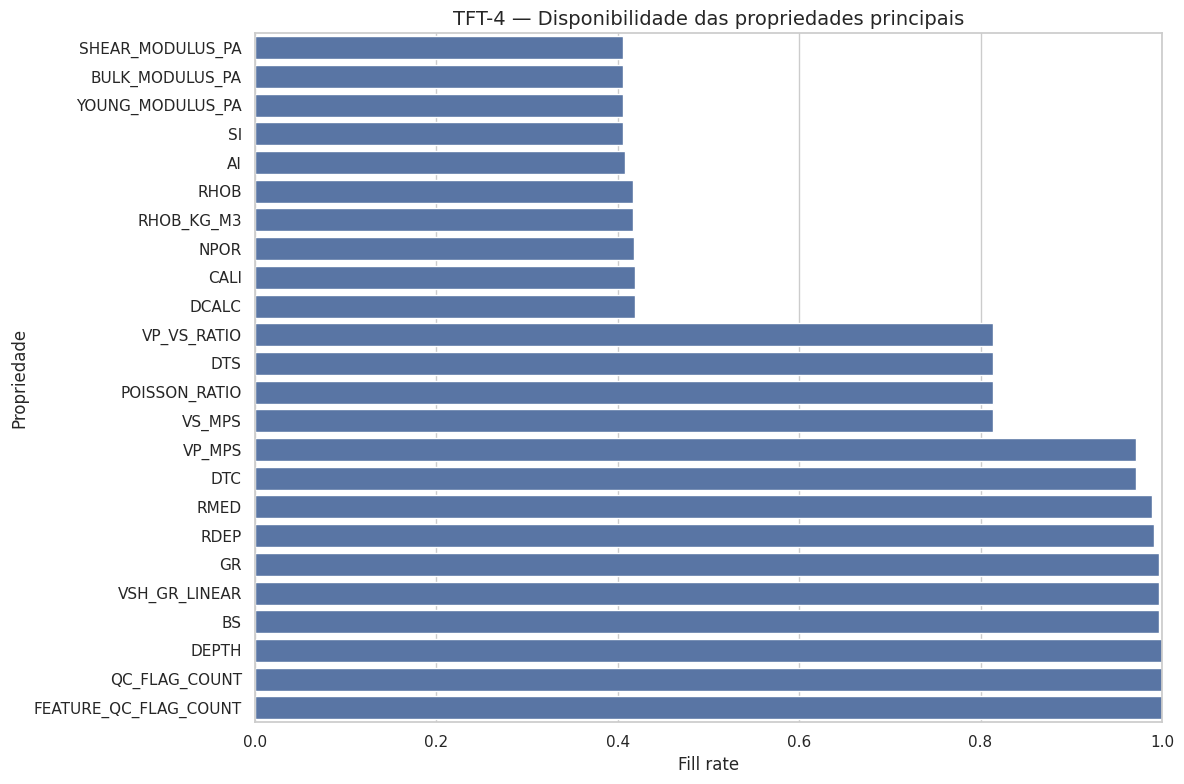

In [14]:
# ============================================================
# STEP 2 — DATA AVAILABILITY AND ANALYTICS READINESS
# ============================================================

important_cols = [
    "DEPTH", "GR", "VSH_GR_LINEAR", "RHOB", "RHOB_KG_M3",
    "DTC", "DTS", "VP_MPS", "VS_MPS",
    "AI", "SI", "VP_VS_RATIO", "POISSON_RATIO",
    "SHEAR_MODULUS_PA", "BULK_MODULUS_PA", "YOUNG_MODULUS_PA",
    "RDEP", "RMED", "RSHA", "NPOR", "CALI", "BS", "DCALC",
    "QC_FLAG_COUNT", "FEATURE_QC_FLAG_COUNT"
]

availability_rows = []

for col in important_cols:
    exists = col in df.columns
    non_null = int(df[col].notna().sum()) if exists else 0
    fill_rate = float(df[col].notna().mean()) if exists else 0.0

    availability_rows.append({
        "COLUMN": col,
        "EXISTS": exists,
        "NON_NULL_COUNT": non_null,
        "FILL_RATE": fill_rate,
    })

availability_df = pd.DataFrame(availability_rows)
display(availability_df)

availability_df.to_csv(REPORT_DIR / f"{WELL_NAME}_analytics_availability.csv", index=False)


plt.figure(figsize=(12, 8))
plot_df = availability_df[availability_df["EXISTS"]].sort_values("FILL_RATE", ascending=True)
sns.barplot(data=plot_df, y="COLUMN", x="FILL_RATE", orient="h")
plt.title(f"{WELL_NAME} — Disponibilidade das propriedades principais")
plt.xlabel("Fill rate")
plt.ylabel("Propriedade")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Interpretação mental — disponibilidade dos dados

Este gráfico responde uma pergunta simples, mas muito importante:

> **Quais propriedades realmente existem em quantidade suficiente para análise?**

Como interpretar:

- barras próximas de 1.0 indicam propriedades muito completas;
- barras intermediárias indicam propriedades úteis, mas com cuidado;
- barras muito baixas indicam que a propriedade talvez não sustente conclusões fortes;
- se `DTS`, `VS_MPS`, `SI` e módulos elásticos estiverem com baixo preenchimento, a análise elástica fica mais limitada;
- se `GR`, `RHOB` e `DTC` estiverem fortes, ainda há bastante coisa petrofísica para investigar.

Conclusão prática:

Antes de qualquer insight, precisamos saber se o dado suporta a pergunta.  
Este gráfico define o grau de confiança inicial para cada propriedade.

# STEP 3 — Global Descriptive Statistics

Agora entramos em estatística descritiva.

Vamos calcular:
- média;
- mediana;
- desvio padrão;
- mínimo;
- máximo;
- percentis;
- amplitude;
- coeficiente de variação;
- assimetria;
- curtose.

O objetivo é construir uma primeira visão quantitativa das propriedades.

In [15]:
# ============================================================
# STEP 3 — GLOBAL DESCRIPTIVE STATISTICS
# ============================================================

analysis_cols = [
    "GR", "VSH_GR_LINEAR", "RHOB", "DTC", "DTS",
    "VP_MPS", "VS_MPS", "AI", "SI", "VP_VS_RATIO",
    "POISSON_RATIO", "SHEAR_MODULUS_PA", "BULK_MODULUS_PA",
    "YOUNG_MODULUS_PA", "RDEP", "NPOR", "DCALC"
]

analysis_cols = [c for c in analysis_cols if c in df.columns and df[c].notna().any()]

desc = df[analysis_cols].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

desc["range"] = desc["max"] - desc["min"]
desc["iqr"] = desc["75%"] - desc["25%"]
desc["cv"] = desc["std"] / desc["mean"].replace(0, np.nan)
desc["skew"] = df[analysis_cols].skew(numeric_only=True)
desc["kurtosis"] = df[analysis_cols].kurtosis(numeric_only=True)

display(desc)

desc.to_csv(REPORT_DIR / f"{WELL_NAME}_global_descriptive_statistics.csv")

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,range,iqr,cv,skew,kurtosis
GR,"18,666.000000",88.059741,28.029797,9.397405,21.340940,45.700624,55.094030,72.368660,89.986179,100.472012,112.043545,125.441013,189.591998,243.851028,234.453624,28.103352,0.318304,0.895220,3.661915
VSH_GR_LINEAR,"18,666.000000",0.514177,0.261052,0.000000,0.000000,0.000001,0.117800,0.334436,0.555372,0.686871,0.831986,0.999974,1.000000,1.000000,1.000000,0.352436,0.507709,-0.238357,-0.562151
RHOB,"7,800.000000",2.423469,0.140661,1.259571,2.131731,2.211361,2.260234,2.356557,2.432674,2.518349,2.567522,2.594697,2.659134,3.209886,1.950315,0.161791,0.058041,-2.277243,14.566817
DTC,"18,199.000000",113.930604,33.930530,51.216694,58.560824,68.977313,75.339792,83.164452,103.830116,148.459099,157.337512,160.121806,173.772296,183.871933,132.655239,65.294647,0.297818,0.128880,-1.547058
DTS,"15,252.000000",265.417520,112.633809,86.628220,116.473900,133.747711,140.743065,154.378006,245.879082,378.433235,407.472522,417.216252,428.729909,448.593384,361.965164,224.055229,0.424365,0.087724,-1.779693
VP_MPS,"18,199.000000","2,937.276746",903.956624,"1,657.675508","1,754.019530","1,903.550847","1,937.236682","2,053.090733","2,935.564468","3,665.027475","4,045.670856","4,418.844194","5,204.844835","5,951.184603","4,293.509094","1,611.936742",0.307753,0.422403,-0.872390
VS_MPS,"15,252.000000","1,401.489514",611.703560,679.457190,710.937104,730.556392,748.025900,805.426088,"1,239.633865","1,974.374513","2,165.648448","2,278.917507","2,616.895392","3,518.483947","2,839.026757","1,168.948425",0.436467,0.271799,-1.433565
AI,"7,642.000000","8,733,801.324905","1,556,381.531669","2,926,859.008373","5,275,753.842900","5,663,957.122957","6,701,059.404386","7,975,190.295510","8,784,306.556835","9,635,205.994697","10,483,598.445535","11,051,305.640737","13,015,204.970037","15,928,885.248677","13,002,026.240304","1,660,015.699187",0.178202,-0.041253,1.373235
SI,"7,602.000000","4,820,689.041726","845,084.750142","1,742,690.391854","2,900,267.824772","3,399,278.691631","3,878,868.886037","4,326,002.453885","4,788,368.852272","5,322,273.591022","5,799,944.079117","6,058,803.215207","7,395,843.496892","9,447,535.209436","7,704,844.817582","996,271.137137",0.175304,0.449592,2.169708
VP_VS_RATIO,"15,252.000000",2.166400,0.386320,1.225783,1.561446,1.708494,1.747120,1.809557,2.102940,2.535416,2.653968,2.705129,2.810770,5.084796,3.859013,0.725859,0.178324,0.499558,0.890334


## Interpretação mental — estatística descritiva global

Esta tabela é como o exame de sangue geral do poço.

Como interpretar:

- **média** mostra tendência central, mas pode ser enganada por outliers;
- **mediana** é mais robusta e geralmente mais confiável em dados petrofísicos;
- **std** mostra dispersão absoluta;
- **IQR** mostra a dispersão do miolo dos dados;
- **CV** ajuda a comparar variabilidade entre propriedades de escalas diferentes;
- **skew** indica cauda assimétrica;
- **kurtosis** indica caudas pesadas/extremos.

Pontos importantes:

- resistividade costuma ser assimétrica e precisa muitas vezes ser analisada em escala log;
- módulos elásticos podem ter caudas se VP, VS ou RHOB tiverem ruídos;
- diferença grande entre média e mediana indica mistura de populações ou outliers;
- IQR grande pode indicar heterogeneidade geológica real.

Conclusão prática:

Esta tabela não entrega a interpretação final, mas mostra quais propriedades merecem gráficos mais cuidadosos.

# STEP 4 — Distribution Analysis

Agora estudamos as distribuições.

Vamos usar vários tipos de gráficos:

- histograma;
- KDE;
- boxplot;
- violin plot;
- ECDF.

A ideia é treinar o olhar estatístico.

Perguntas:

- a propriedade tem uma população única ou várias?
- existe cauda longa?
- existem extremos?
- os valores estão concentrados ou espalhados?
- há evidência de mistura de litologias ou zonas?

In [16]:
# ============================================================
# STEP 4 — DISTRIBUTION ANALYSIS FUNCTIONS
# ============================================================

def plot_distribution_suite(df: pd.DataFrame, col: str, bins: int = 80) -> None:
    if col not in df.columns or df[col].dropna().empty:
        print(f"Coluna indisponível: {col}")
        return

    x = df[col].dropna()

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(x, bins=bins, kde=True, ax=ax1)
    ax1.set_title(f"{col} — Histograma + KDE")
    ax1.set_xlabel(col)

    ax2 = fig.add_subplot(gs[0, 1])
    sns.boxplot(x=x, ax=ax2)
    ax2.set_title(f"{col} — Boxplot")
    ax2.set_xlabel(col)

    ax3 = fig.add_subplot(gs[1, 0])
    sns.violinplot(x=x, ax=ax3, inner="quartile")
    ax3.set_title(f"{col} — Violin plot")
    ax3.set_xlabel(col)

    ax4 = fig.add_subplot(gs[1, 1])
    sns.ecdfplot(x=x, ax=ax4)
    ax4.set_title(f"{col} — ECDF")
    ax4.set_xlabel(col)
    ax4.set_ylabel("Proporção acumulada")

    ax5 = fig.add_subplot(gs[2, :])
    q_low = x.quantile(0.01)
    q_high = x.quantile(0.99)
    x_zoom = x[(x >= q_low) & (x <= q_high)]
    sns.histplot(x_zoom, bins=bins, kde=True, ax=ax5)
    ax5.set_title(f"{col} — Zoom P01 a P99")
    ax5.set_xlabel(col)

    plt.tight_layout()
    plt.show()


distribution_cols = [
    "GR", "VSH_GR_LINEAR", "RHOB", "DTC", "DTS",
    "VP_MPS", "VS_MPS", "AI", "SI", "VP_VS_RATIO",
    "POISSON_RATIO", "SHEAR_MODULUS_PA", "BULK_MODULUS_PA",
    "YOUNG_MODULUS_PA", "RDEP", "NPOR"
]

distribution_cols = [c for c in distribution_cols if c in df.columns and df[c].notna().any()]
print("Colunas disponíveis para análise de distribuição:")
print(distribution_cols)

Colunas disponíveis para análise de distribuição:
['GR', 'VSH_GR_LINEAR', 'RHOB', 'DTC', 'DTS', 'VP_MPS', 'VS_MPS', 'AI', 'SI', 'VP_VS_RATIO', 'POISSON_RATIO', 'SHEAR_MODULUS_PA', 'BULK_MODULUS_PA', 'YOUNG_MODULUS_PA', 'RDEP', 'NPOR']


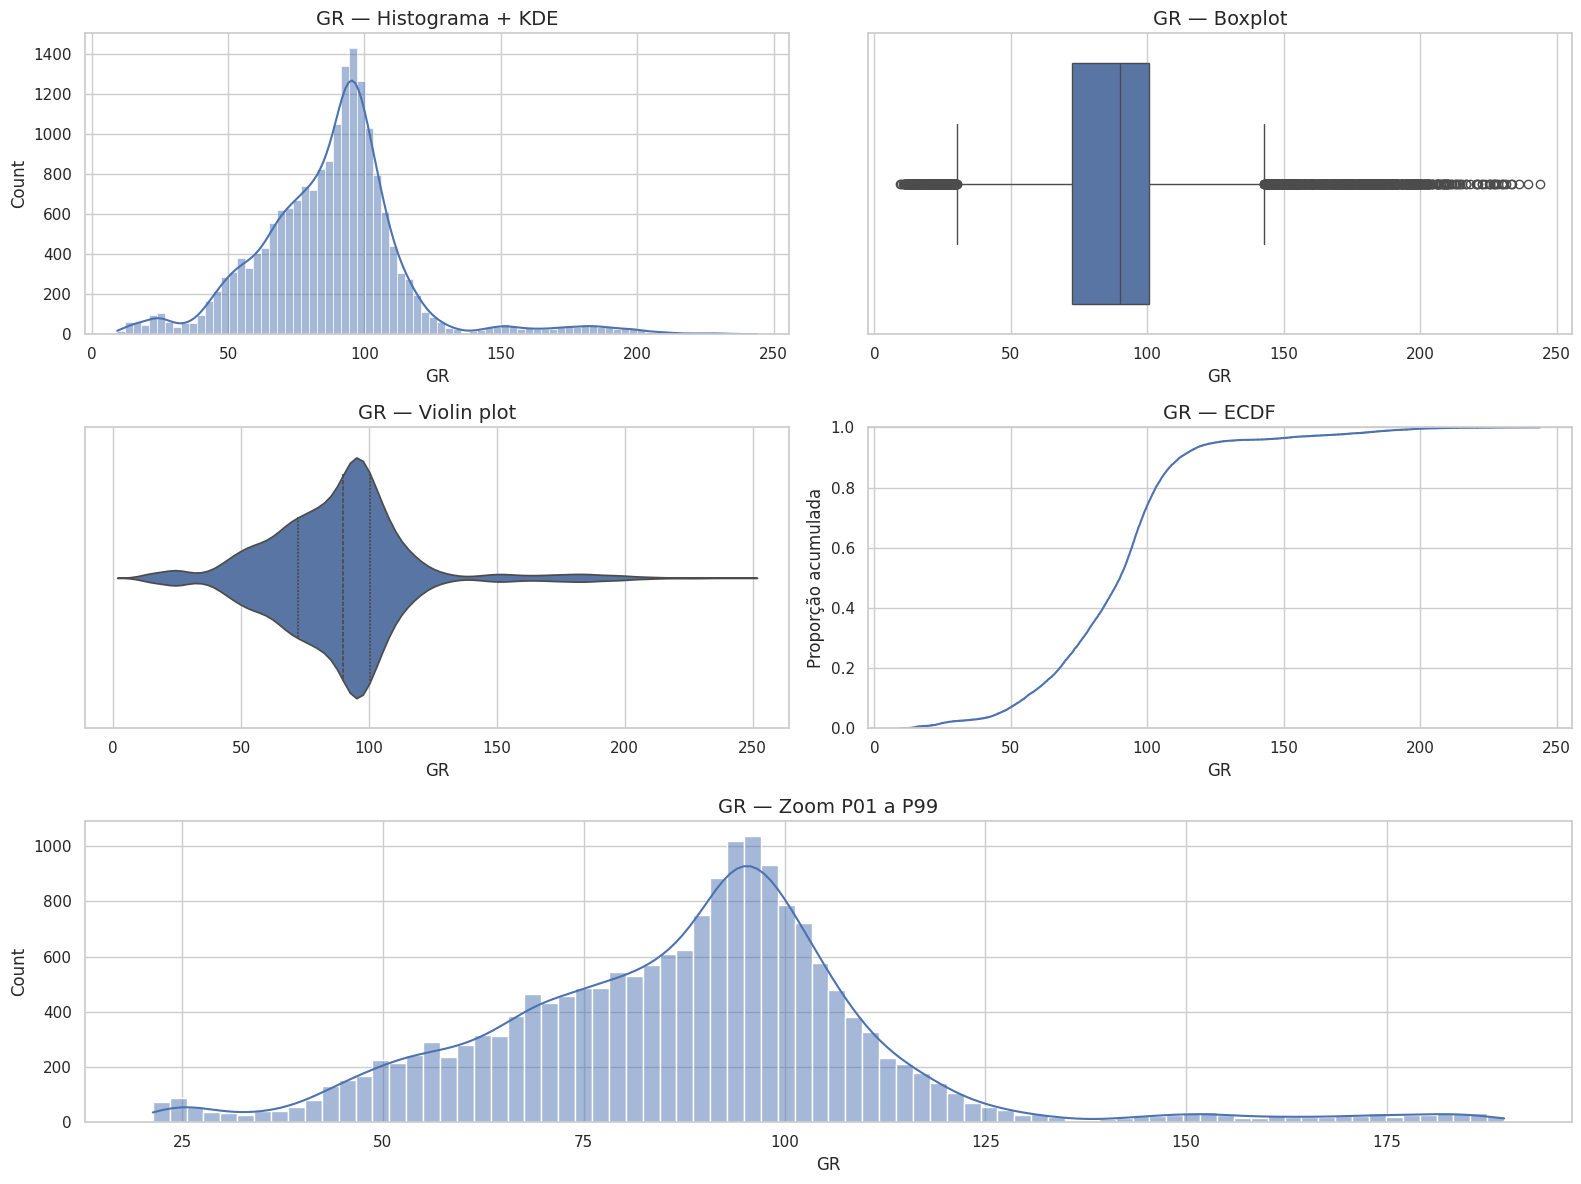

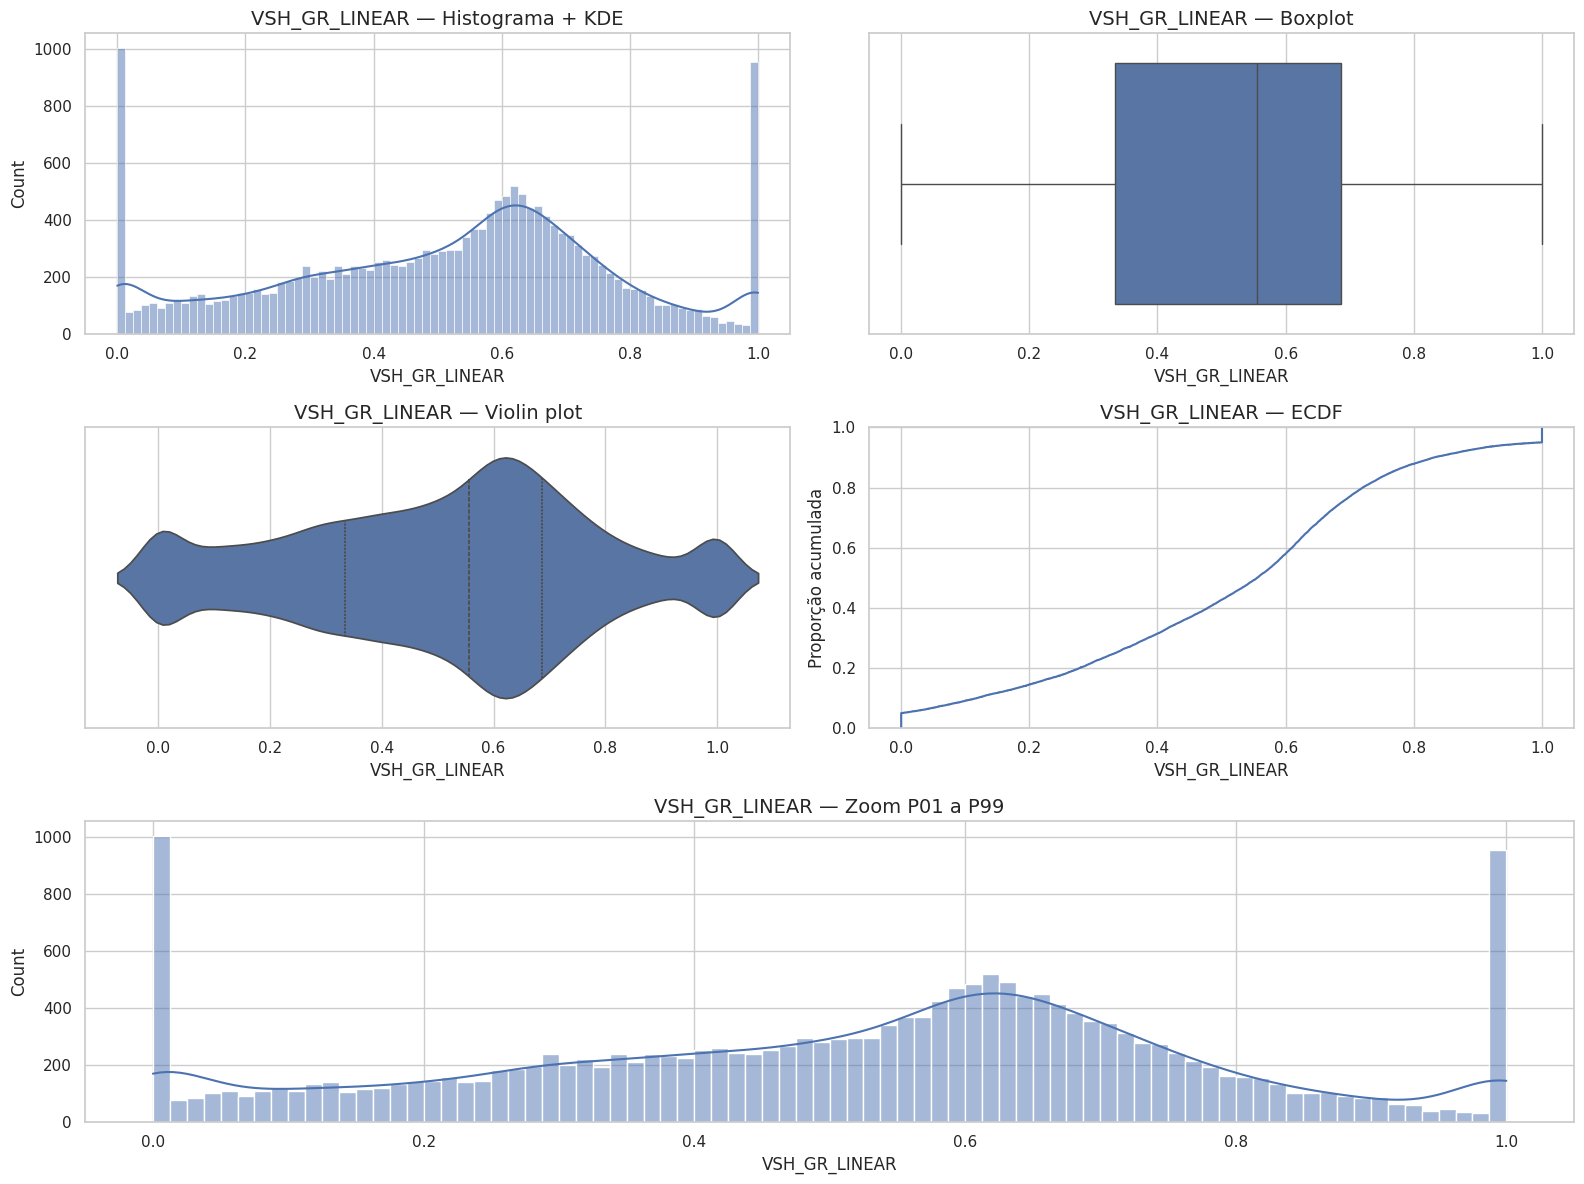

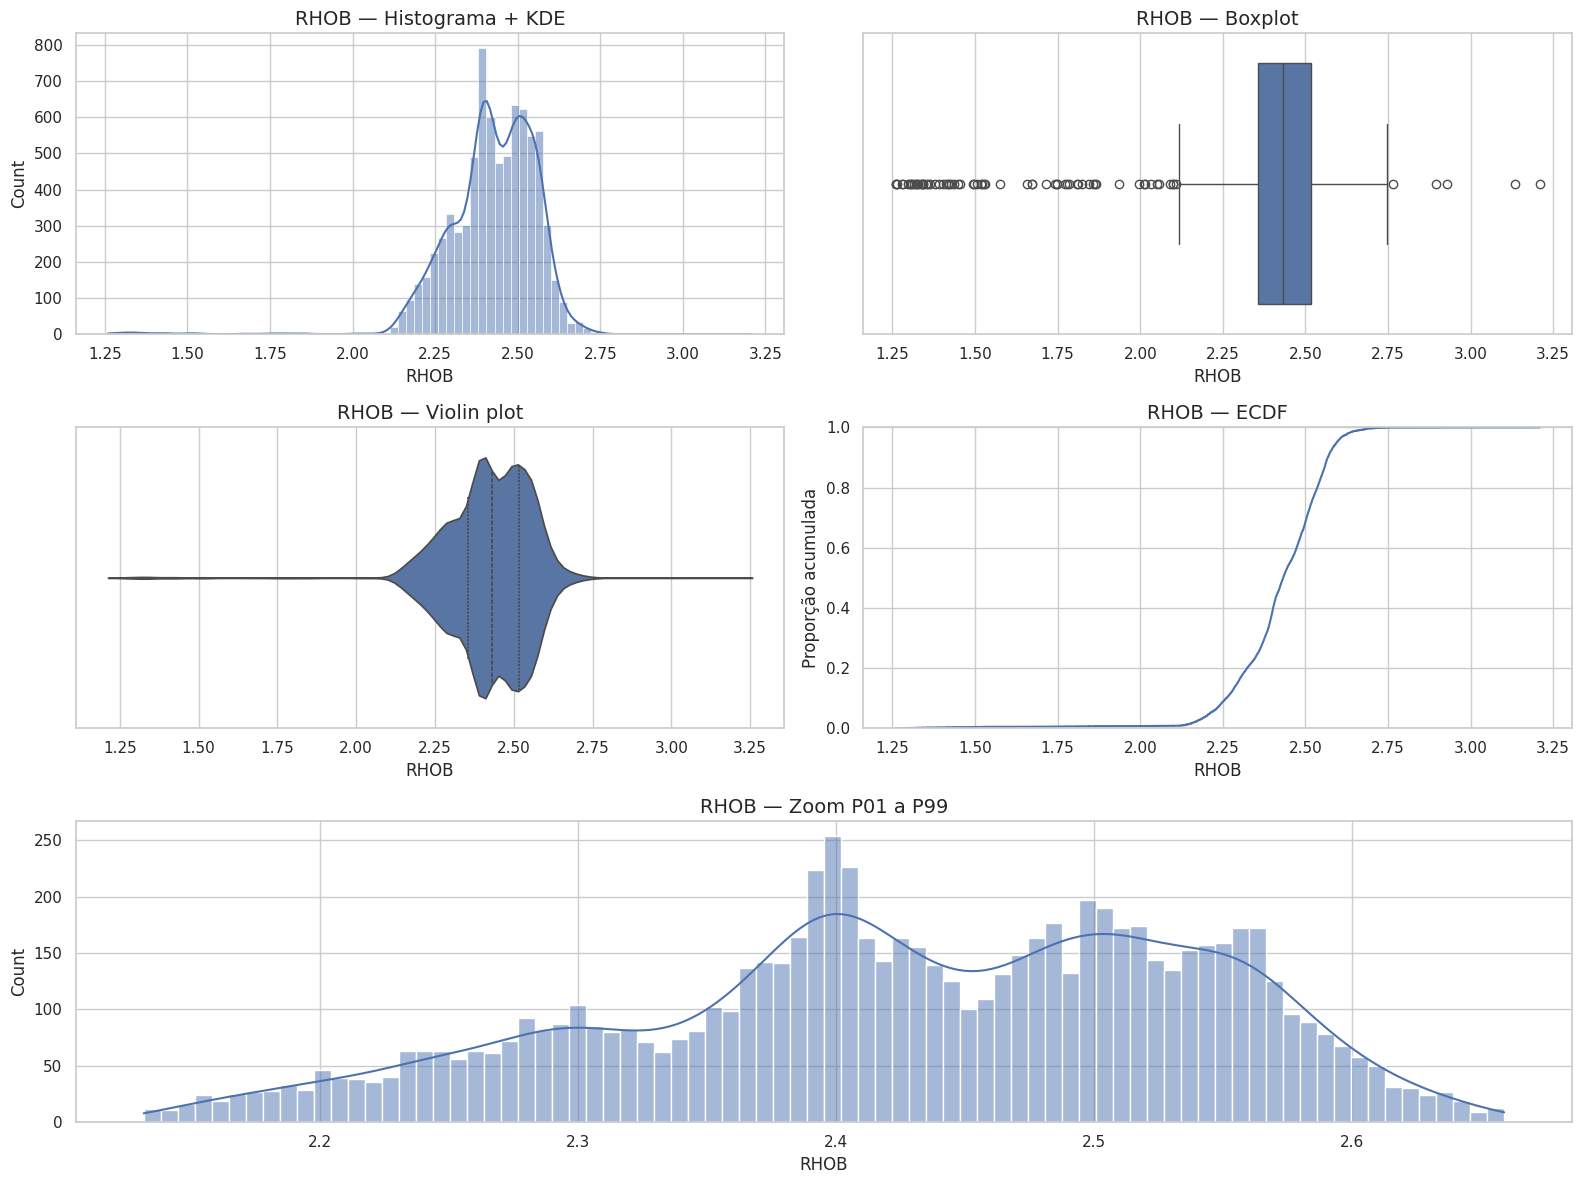

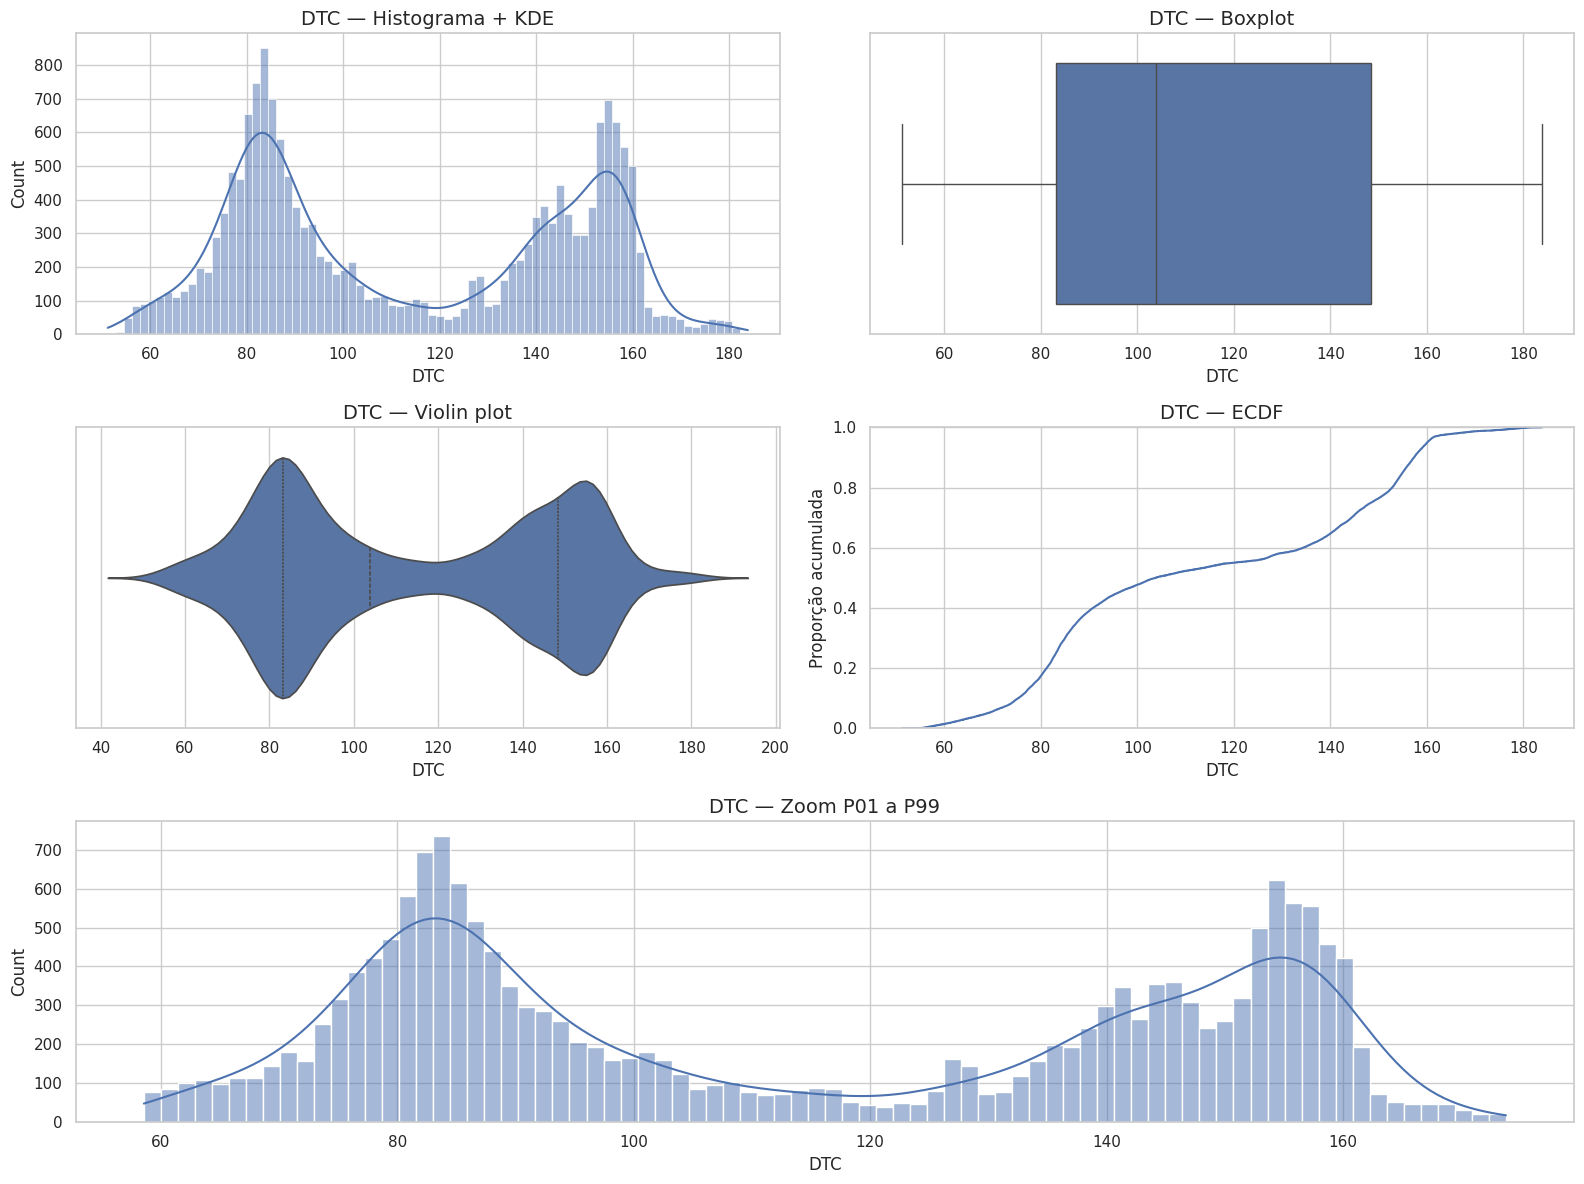

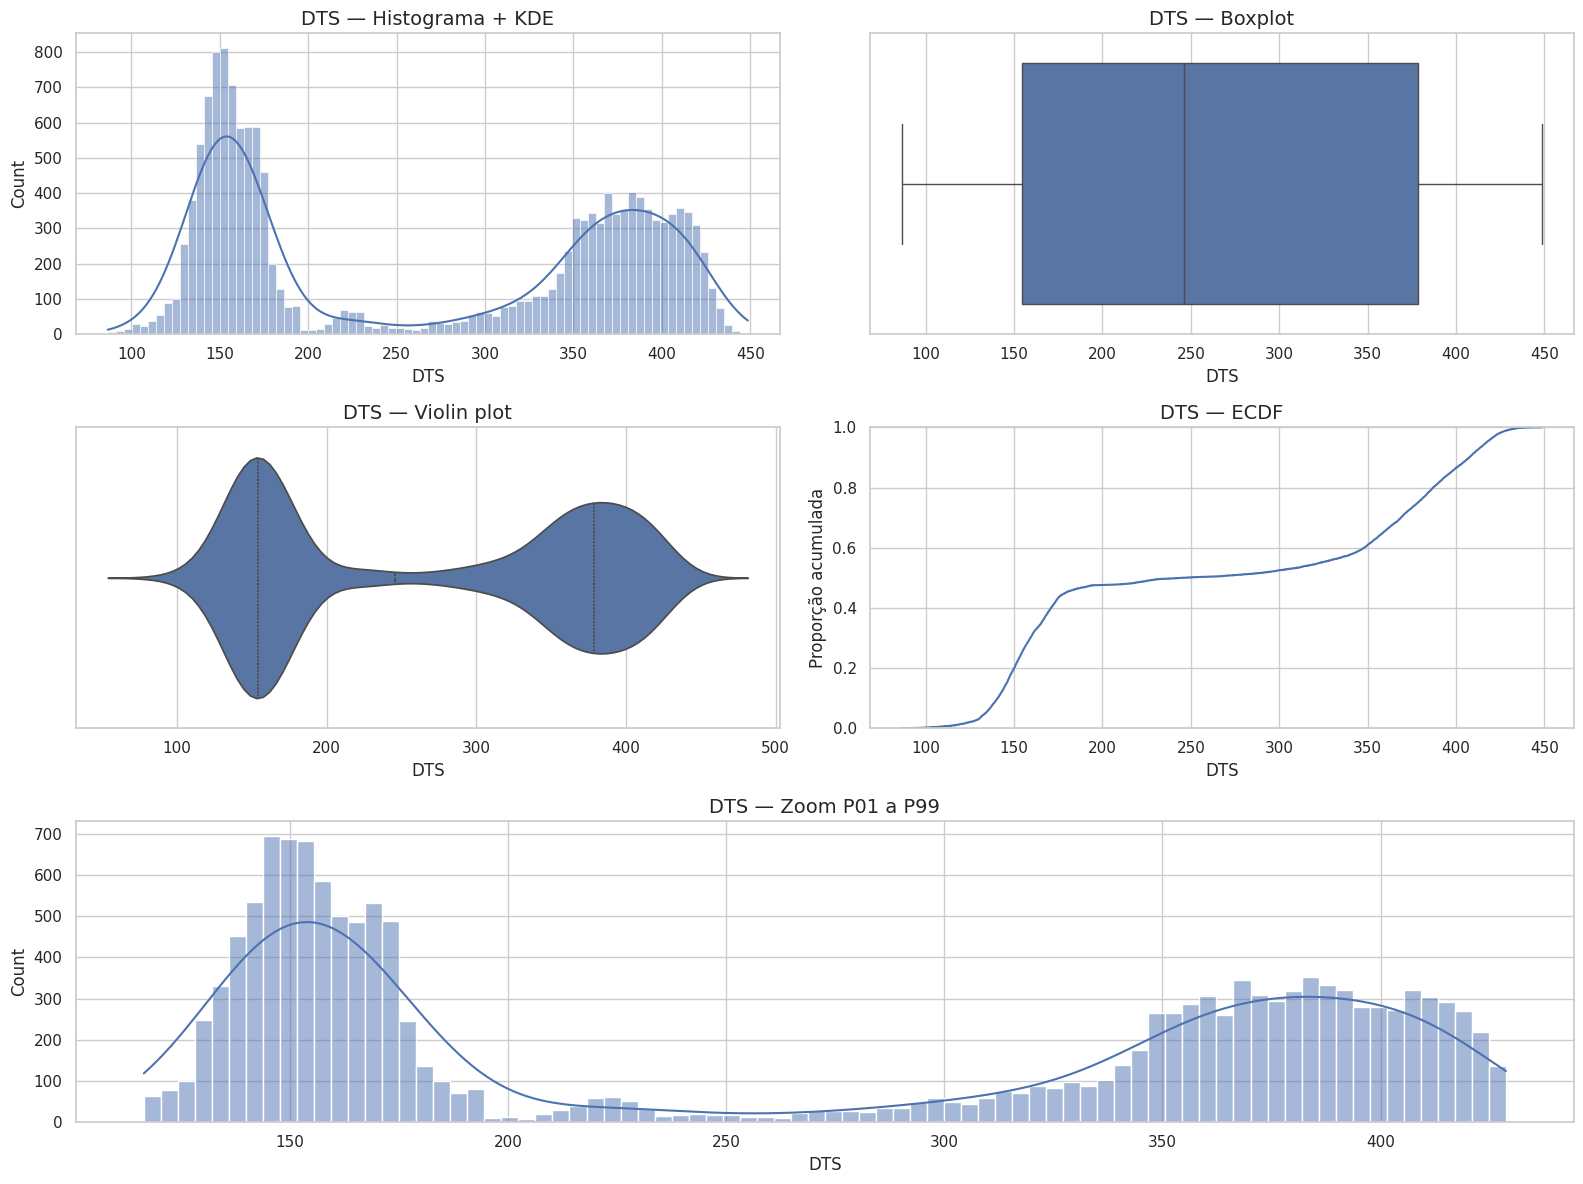

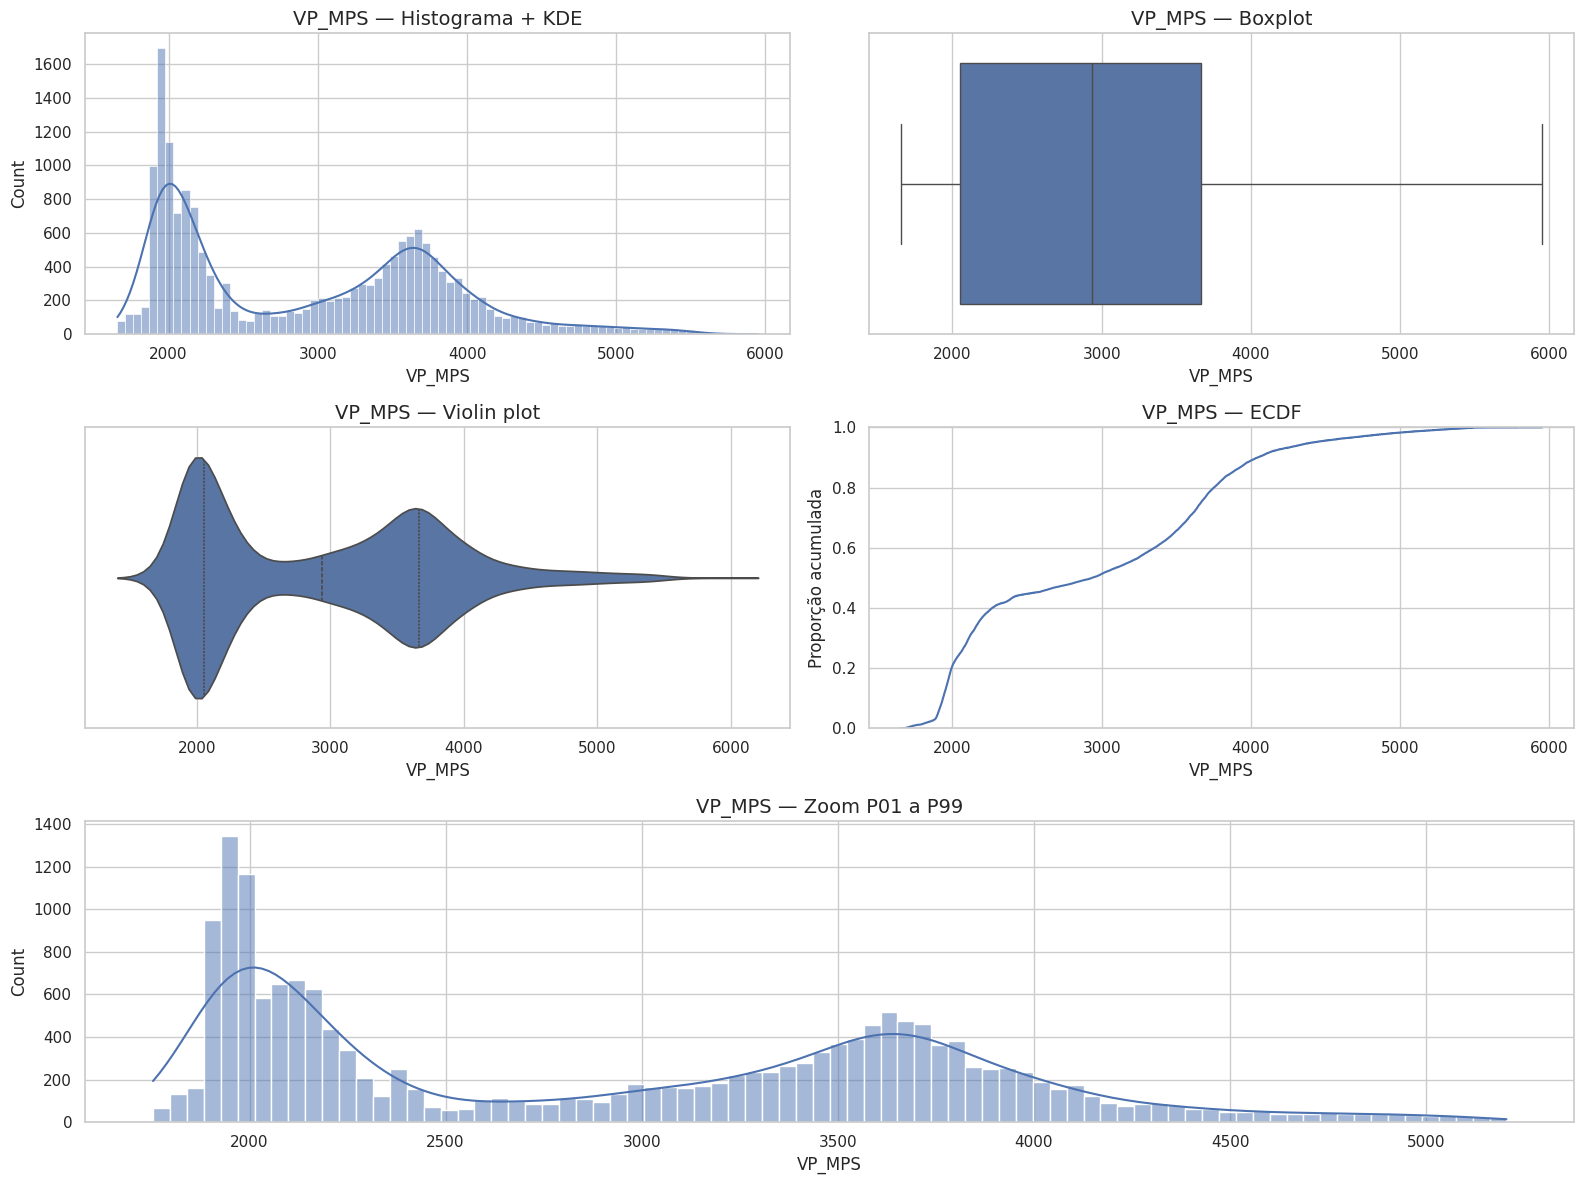

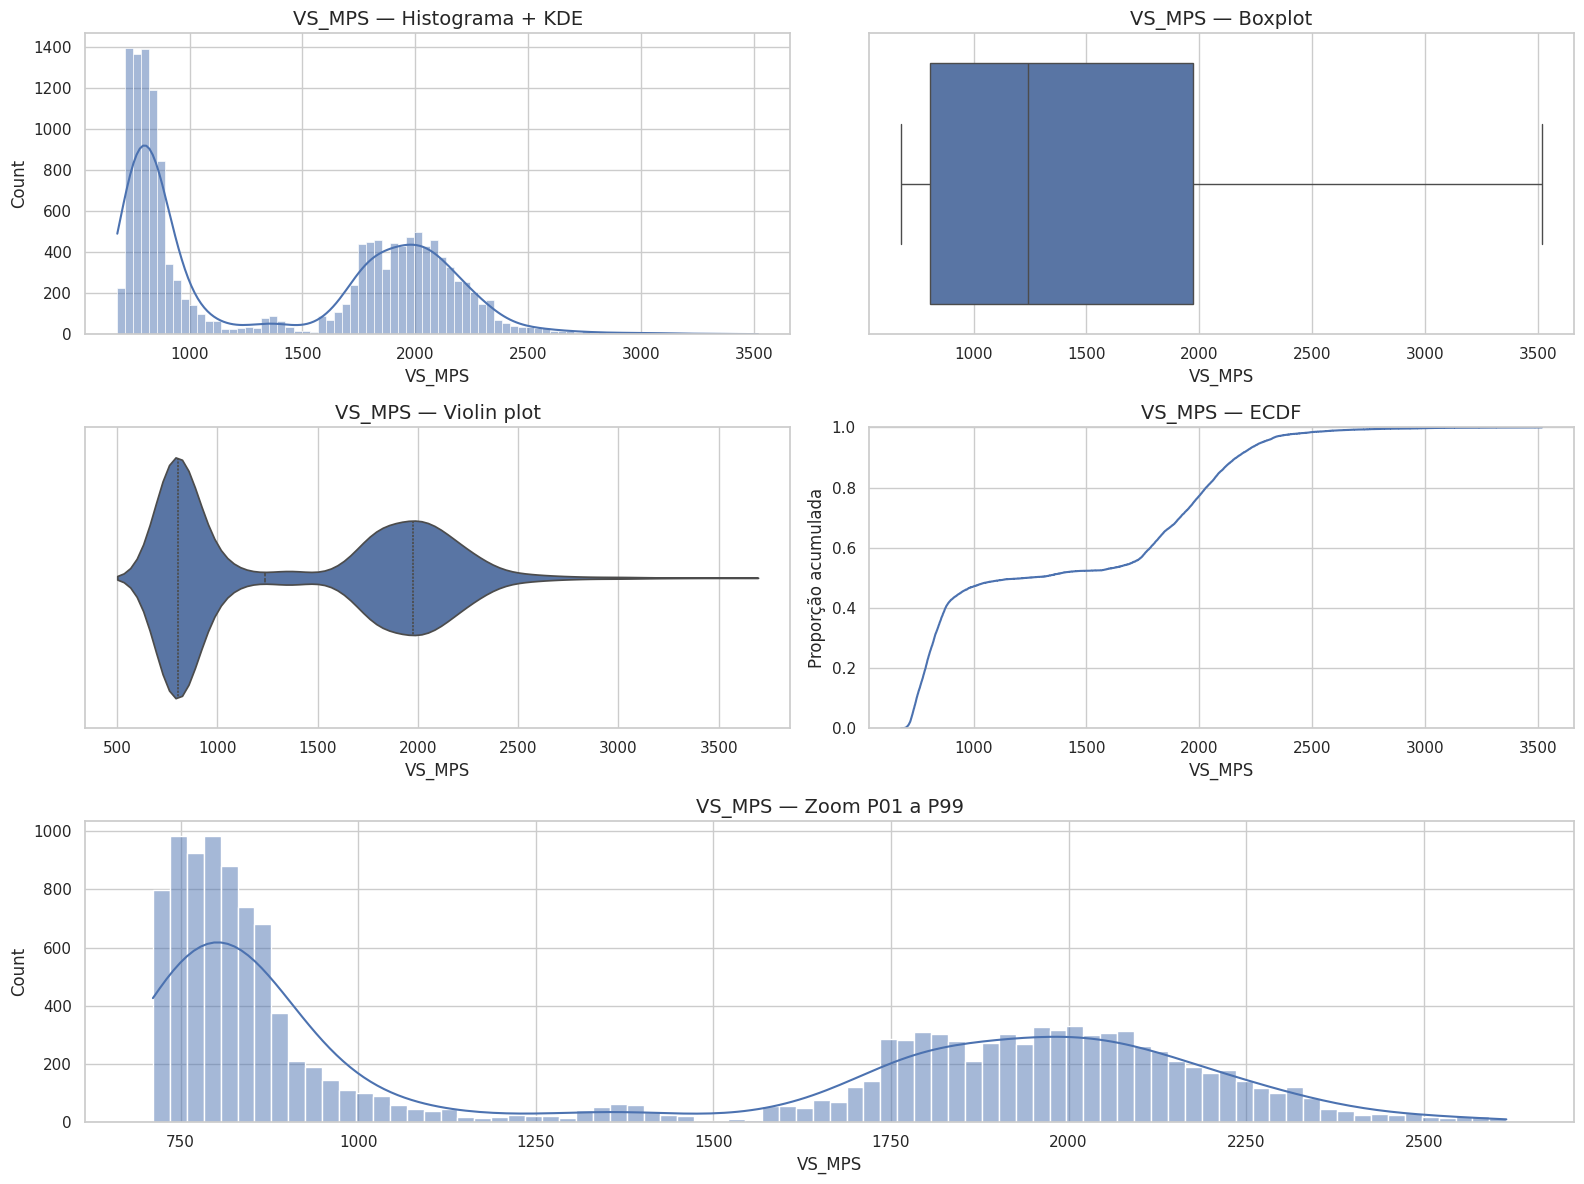

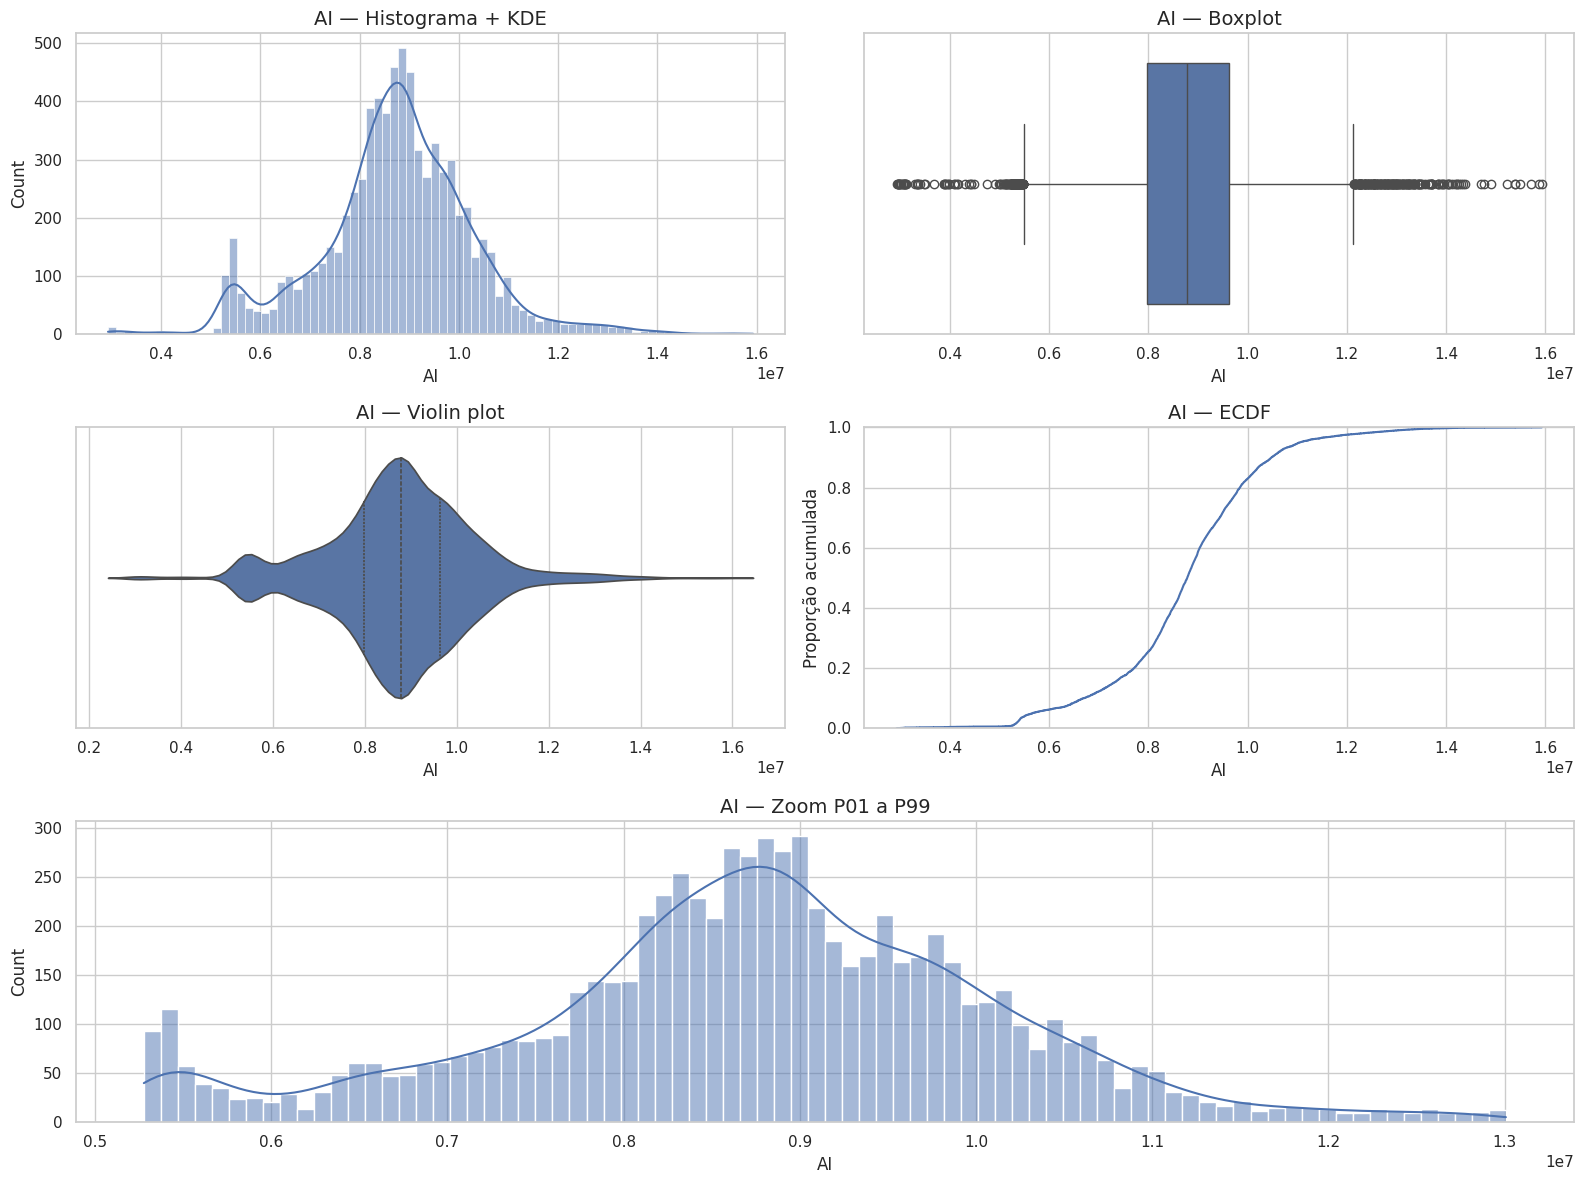

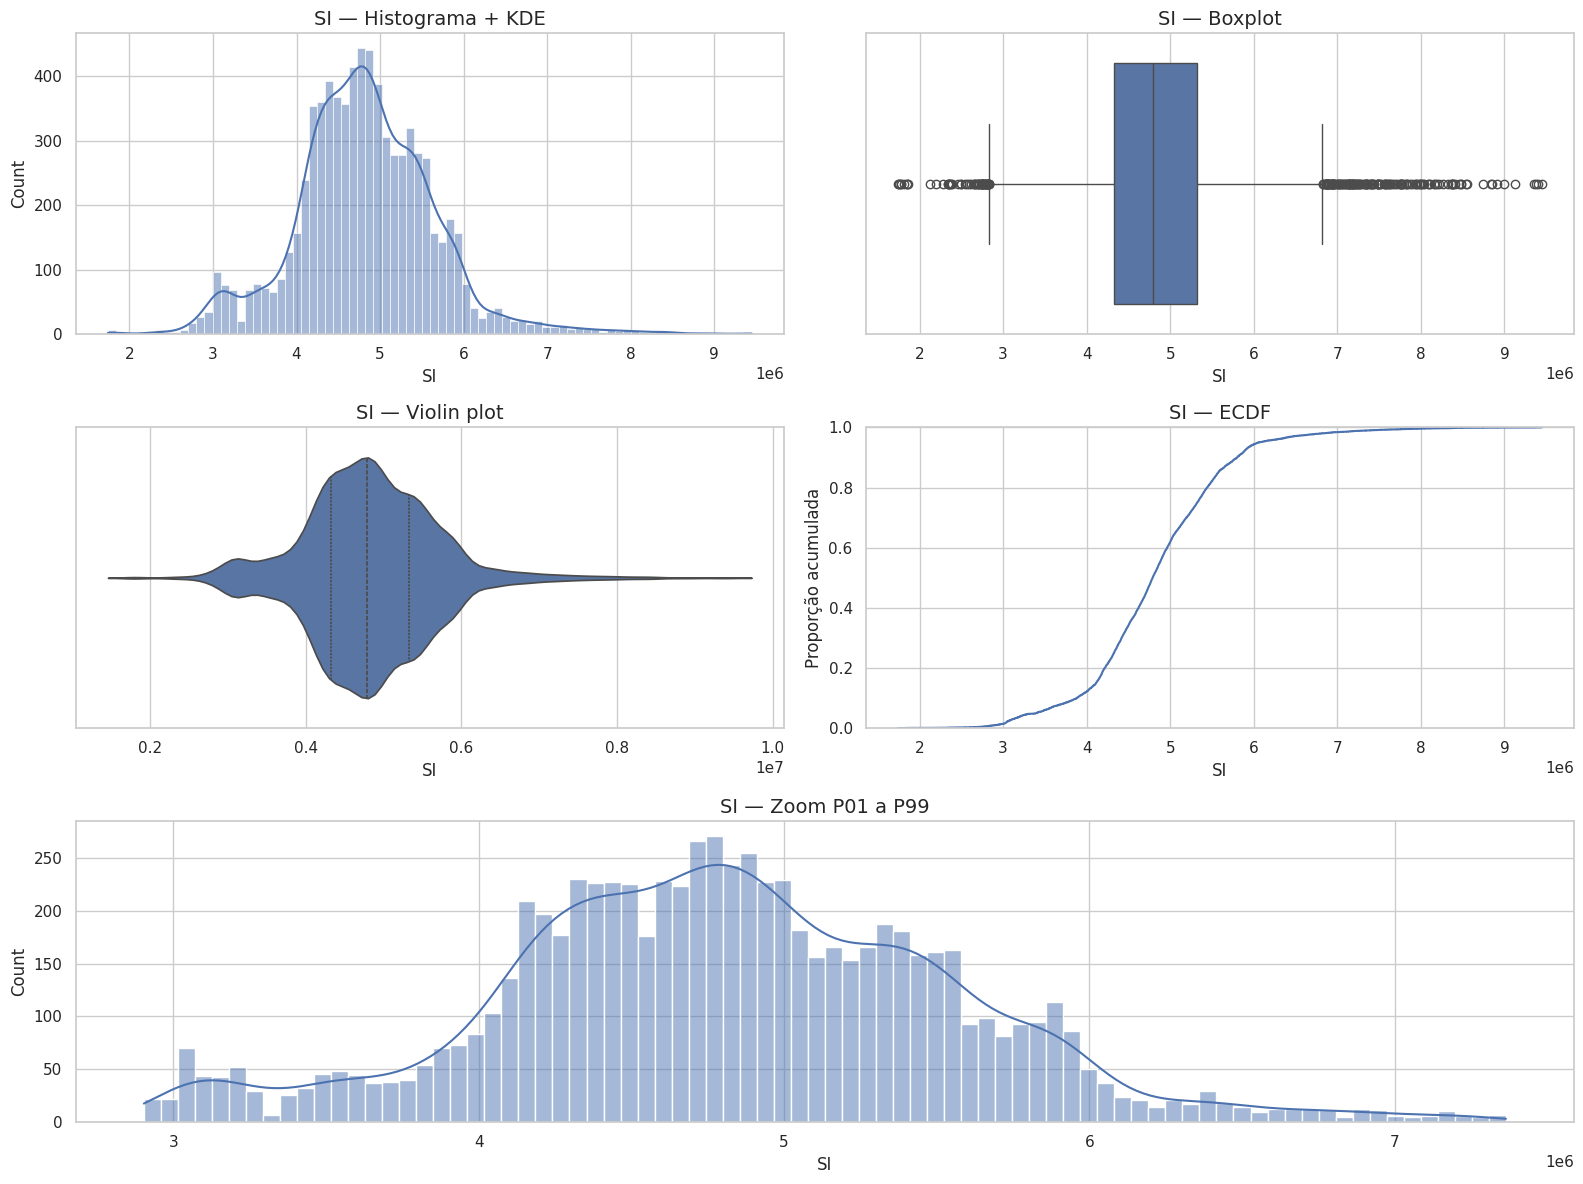

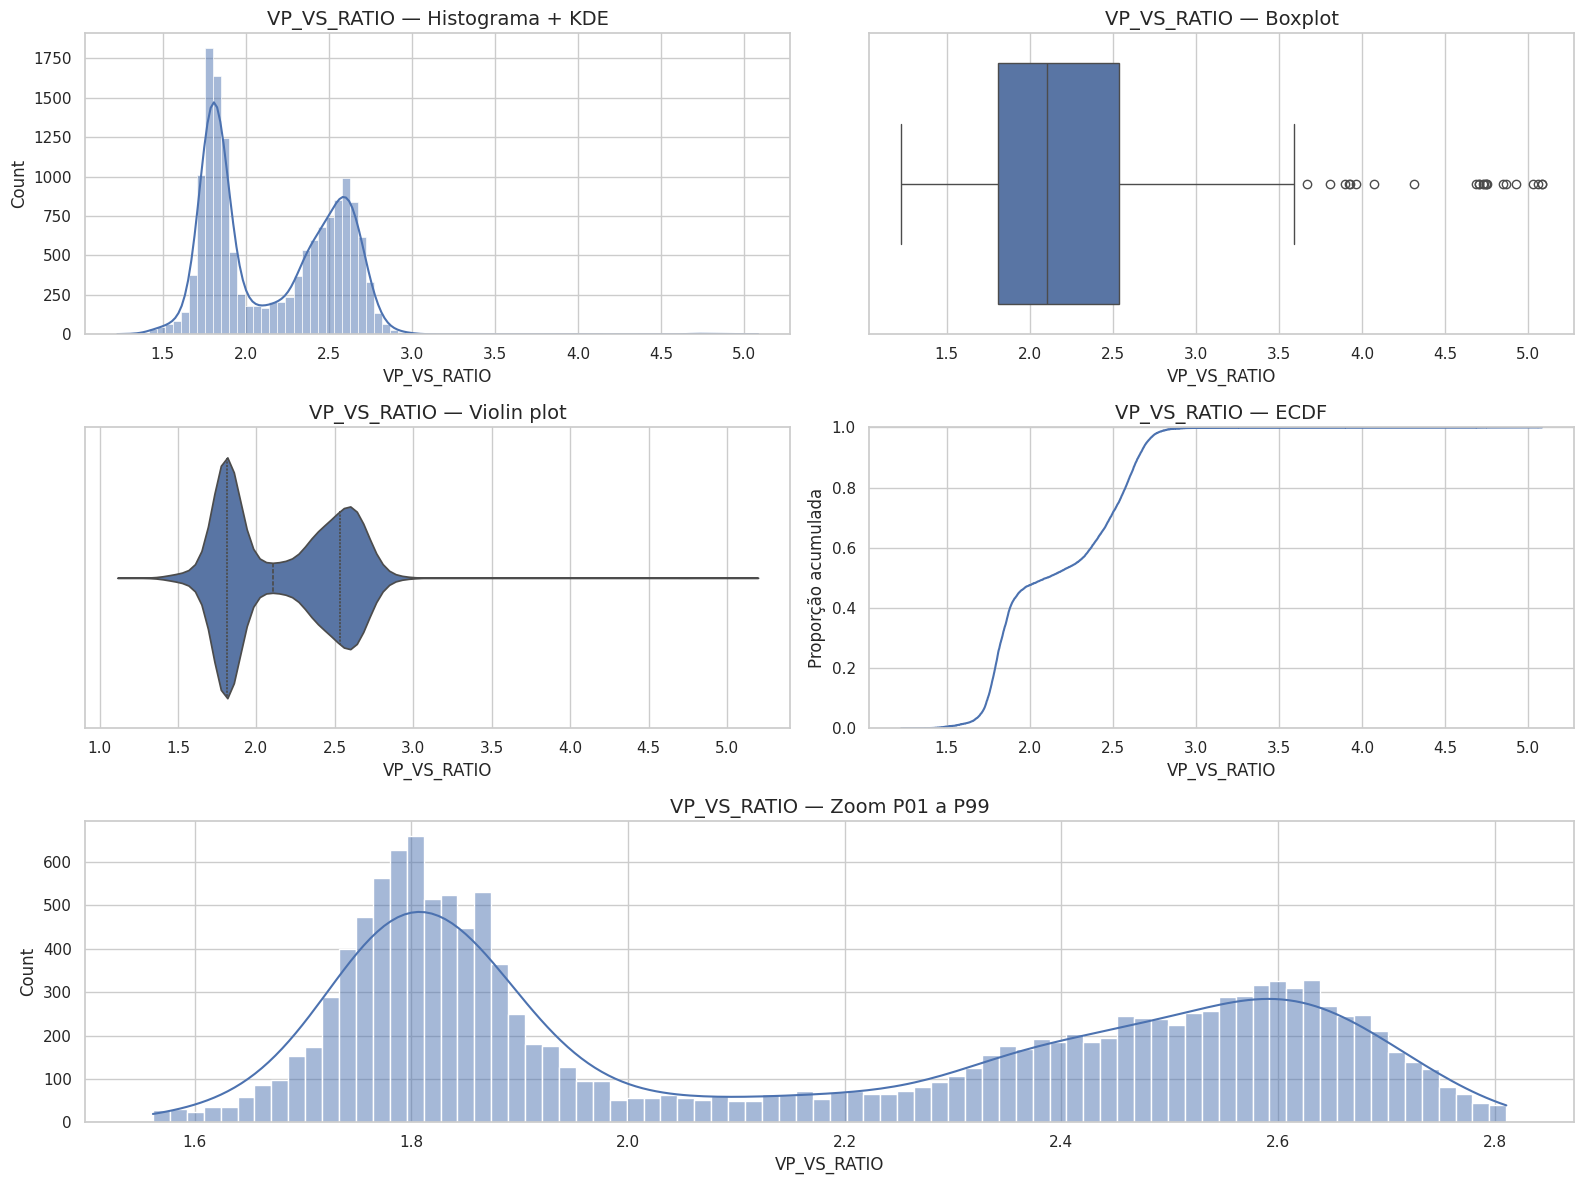

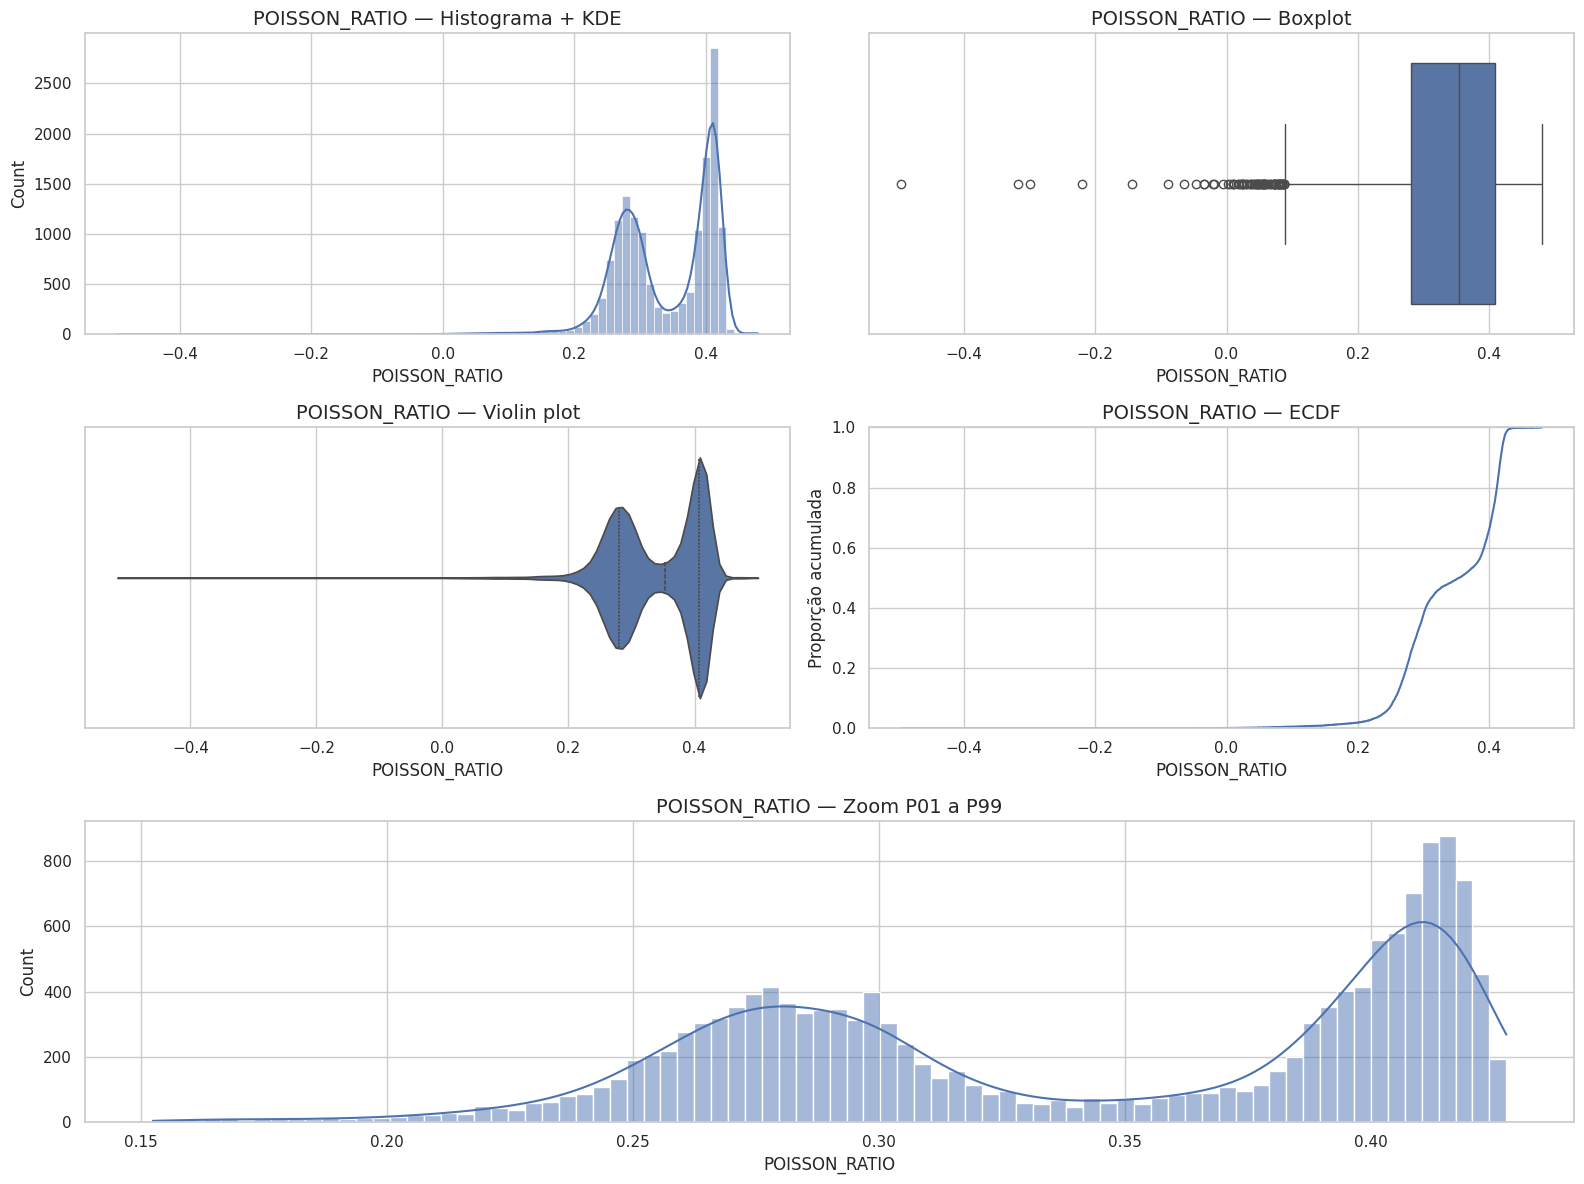

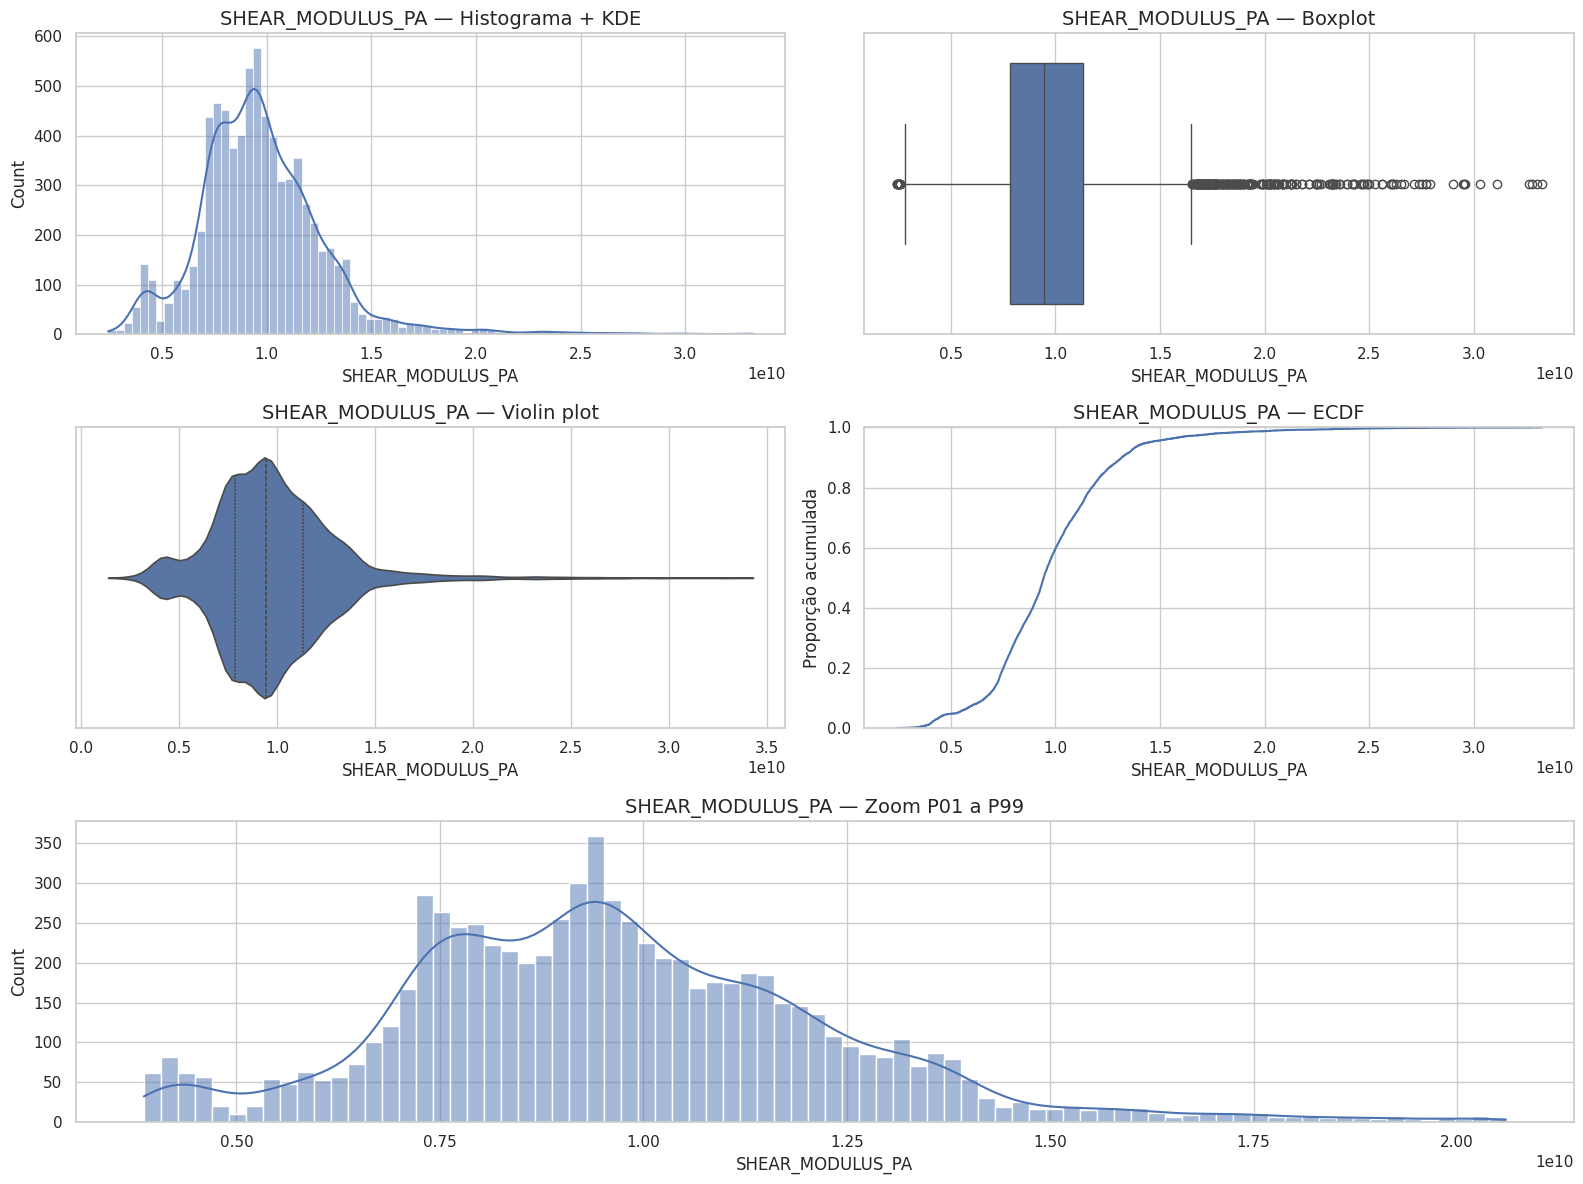

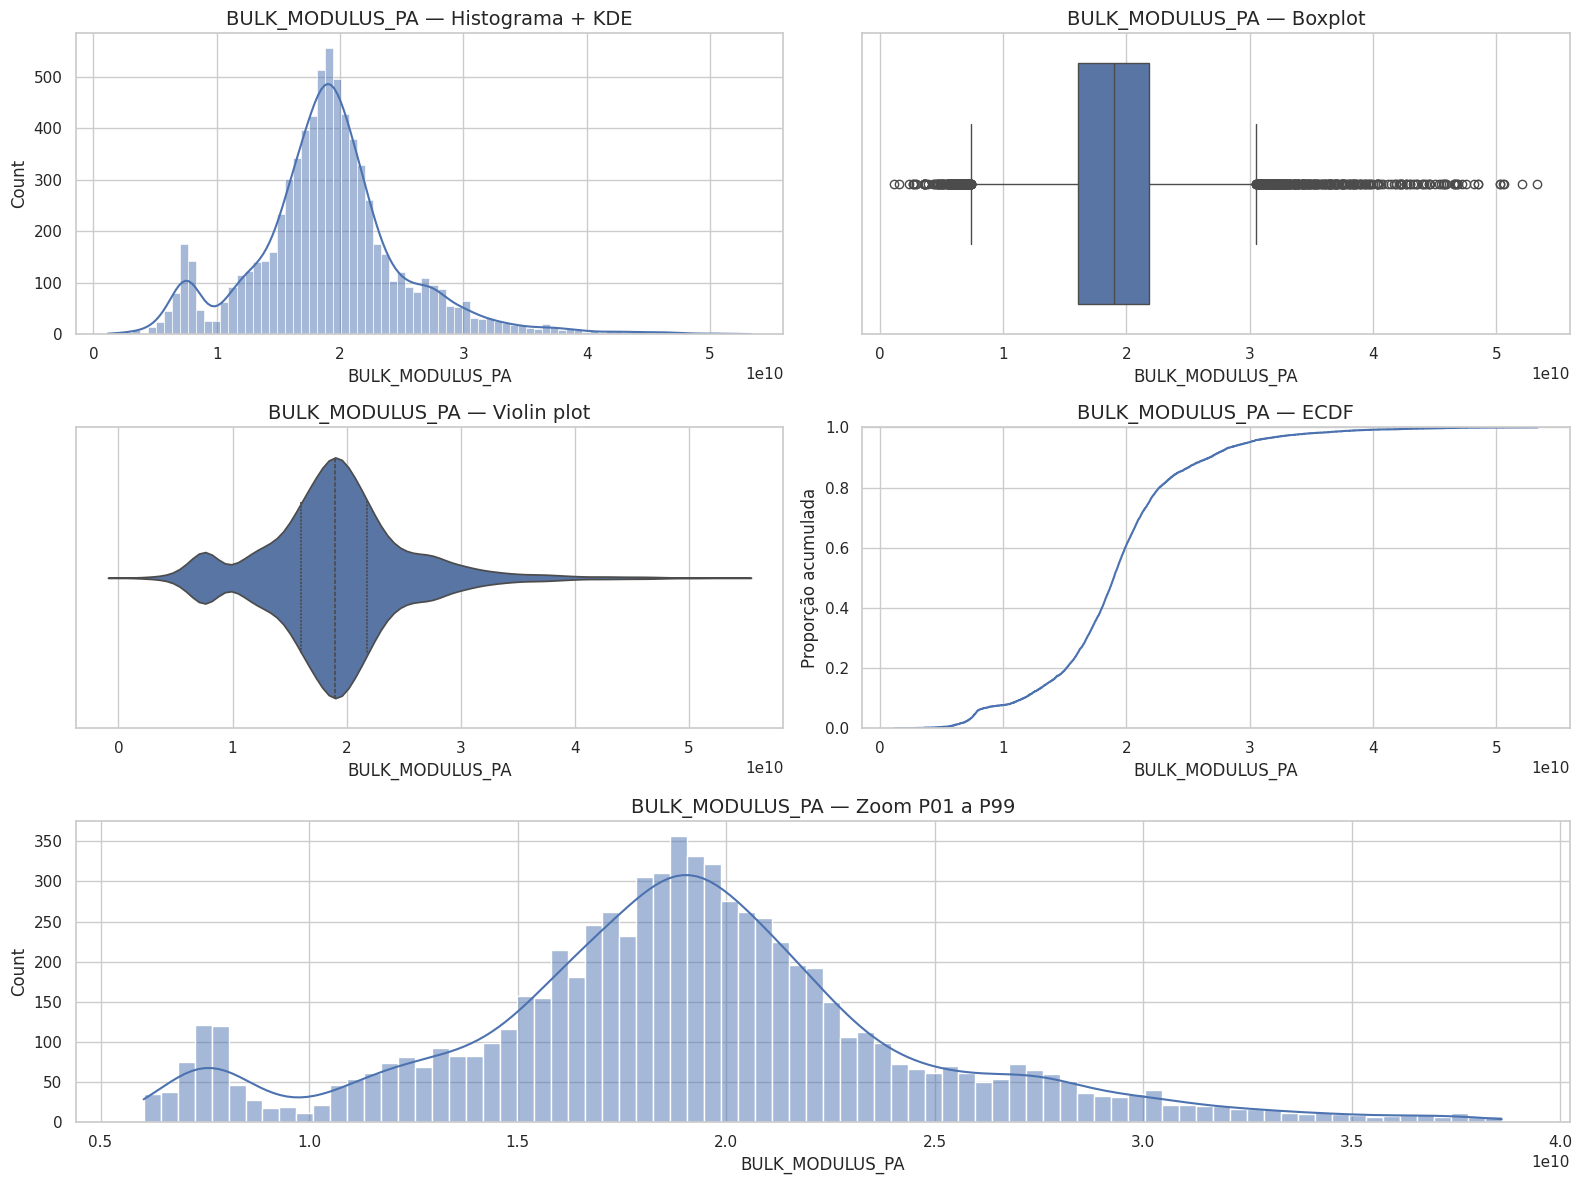

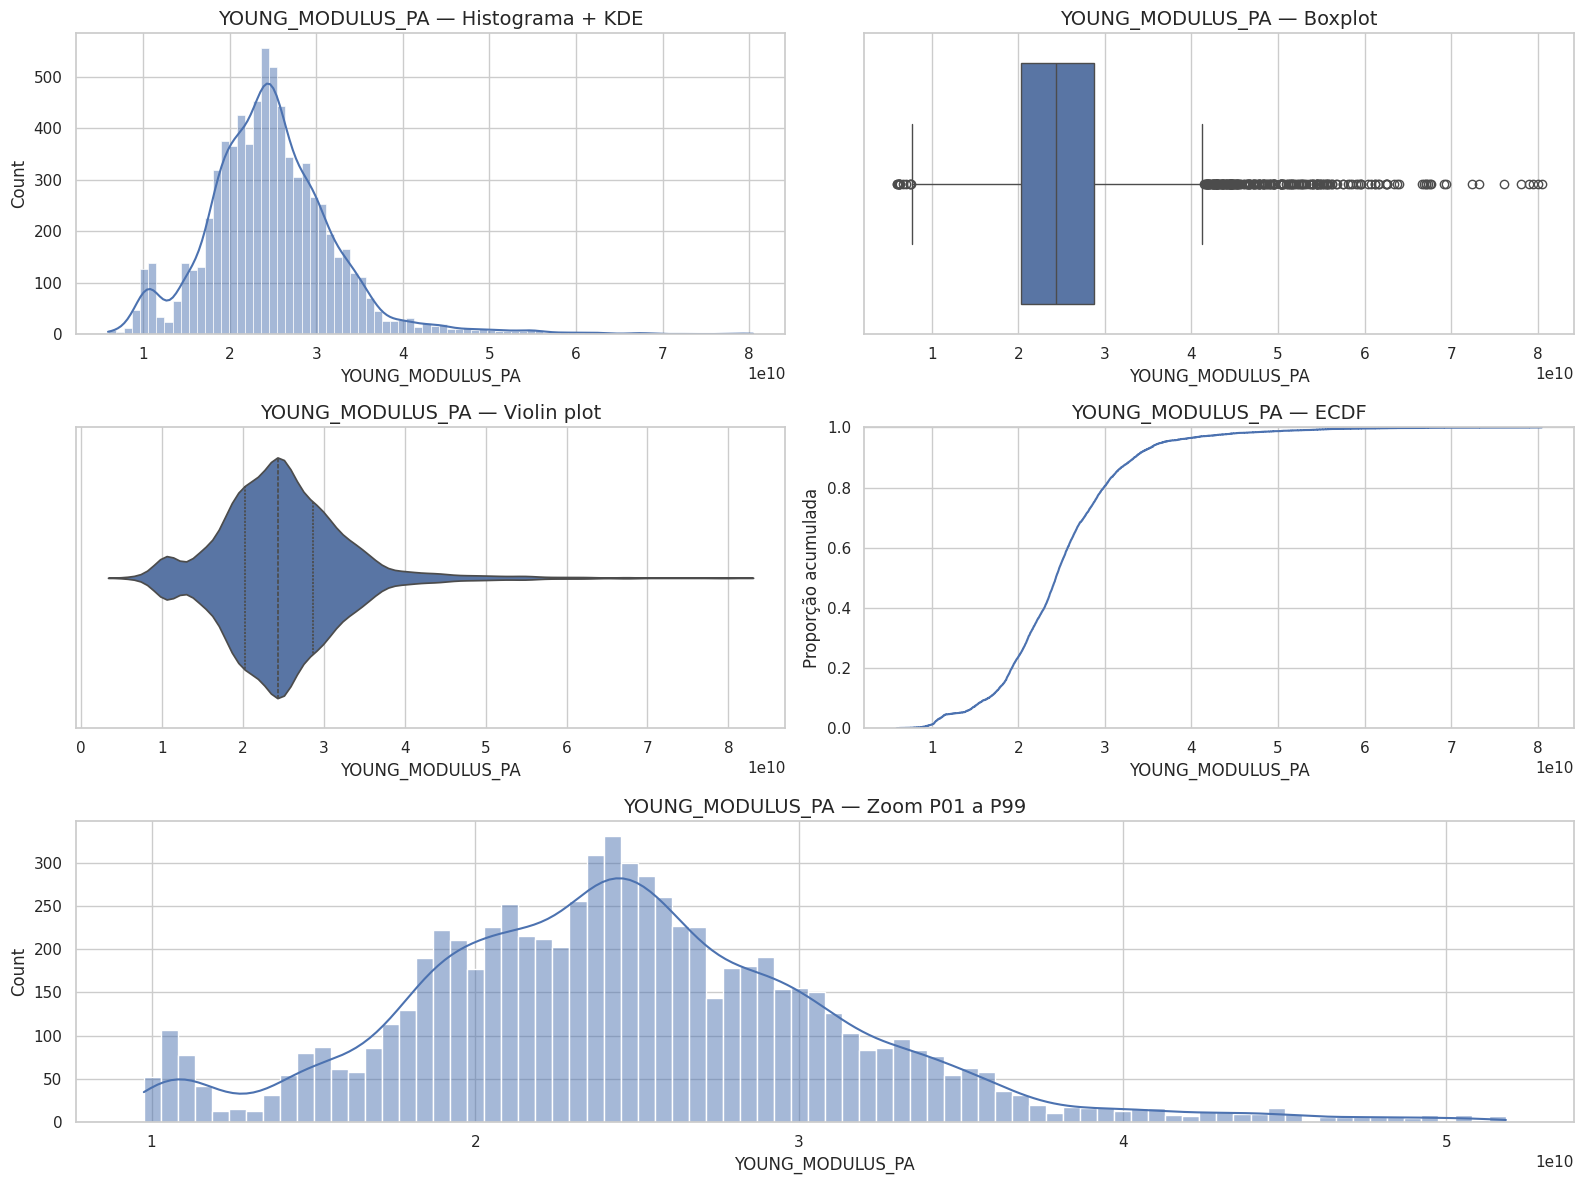

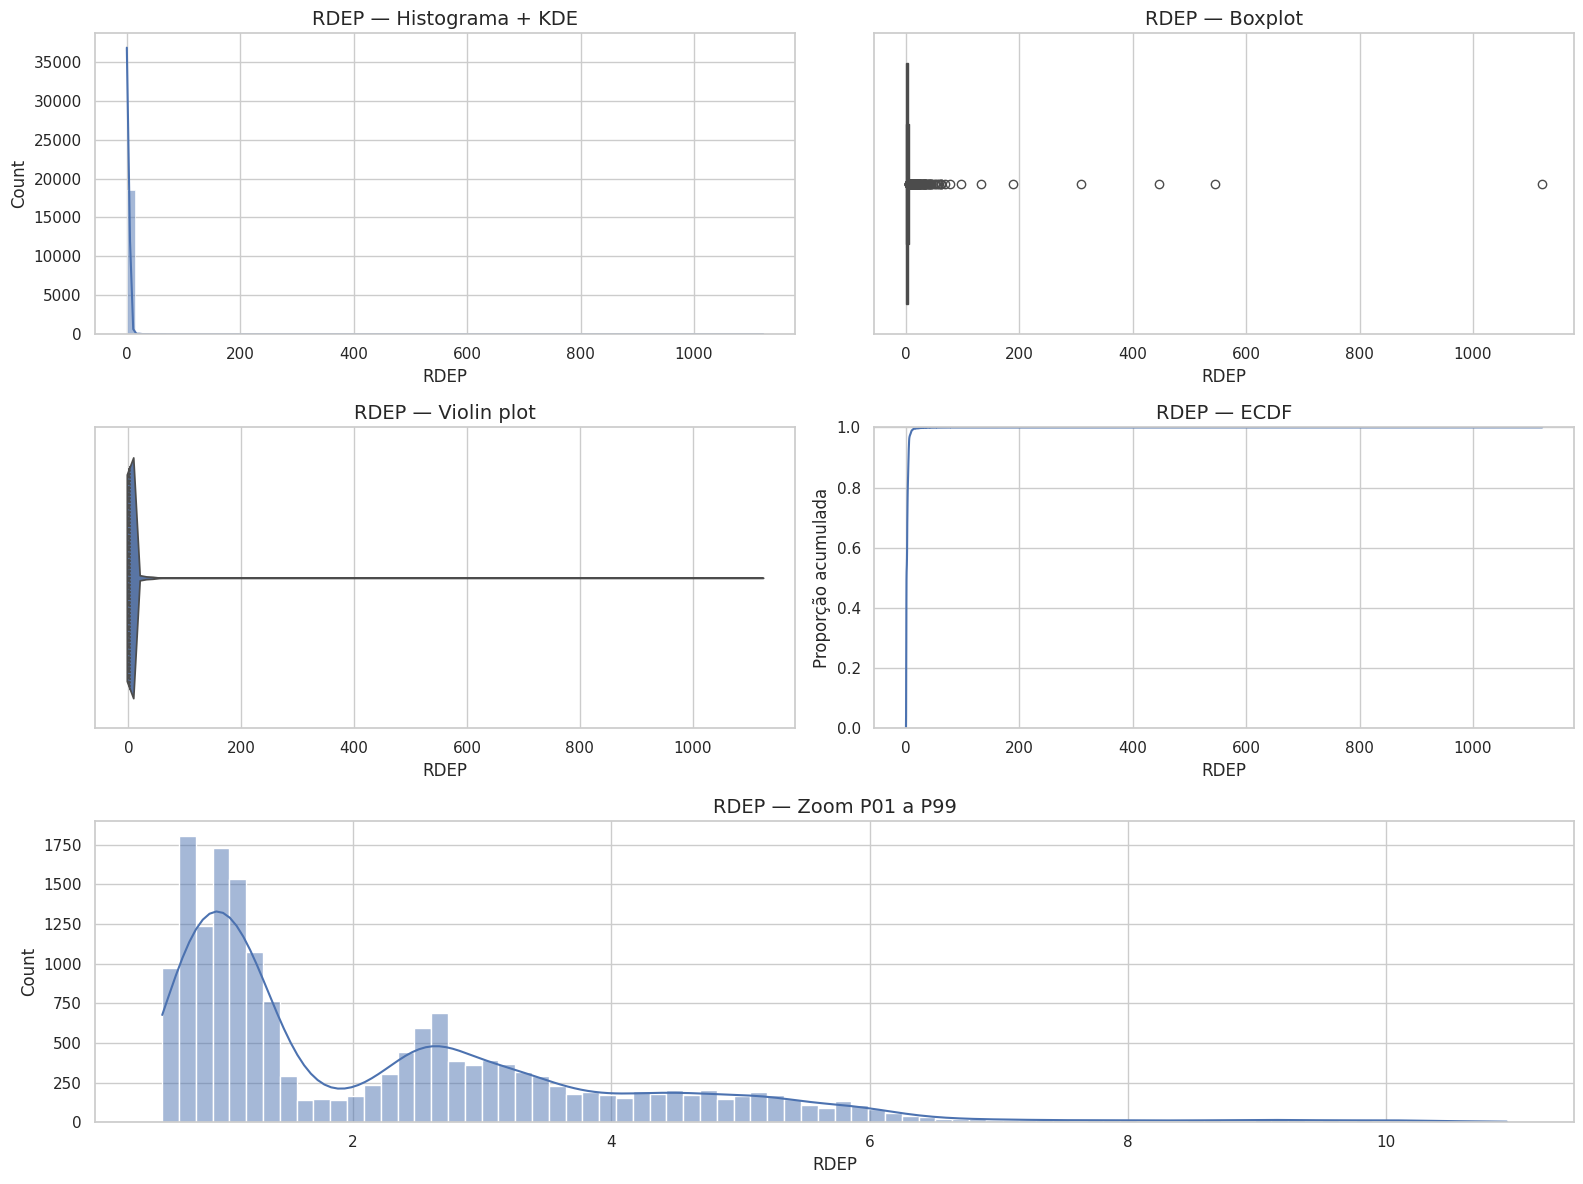

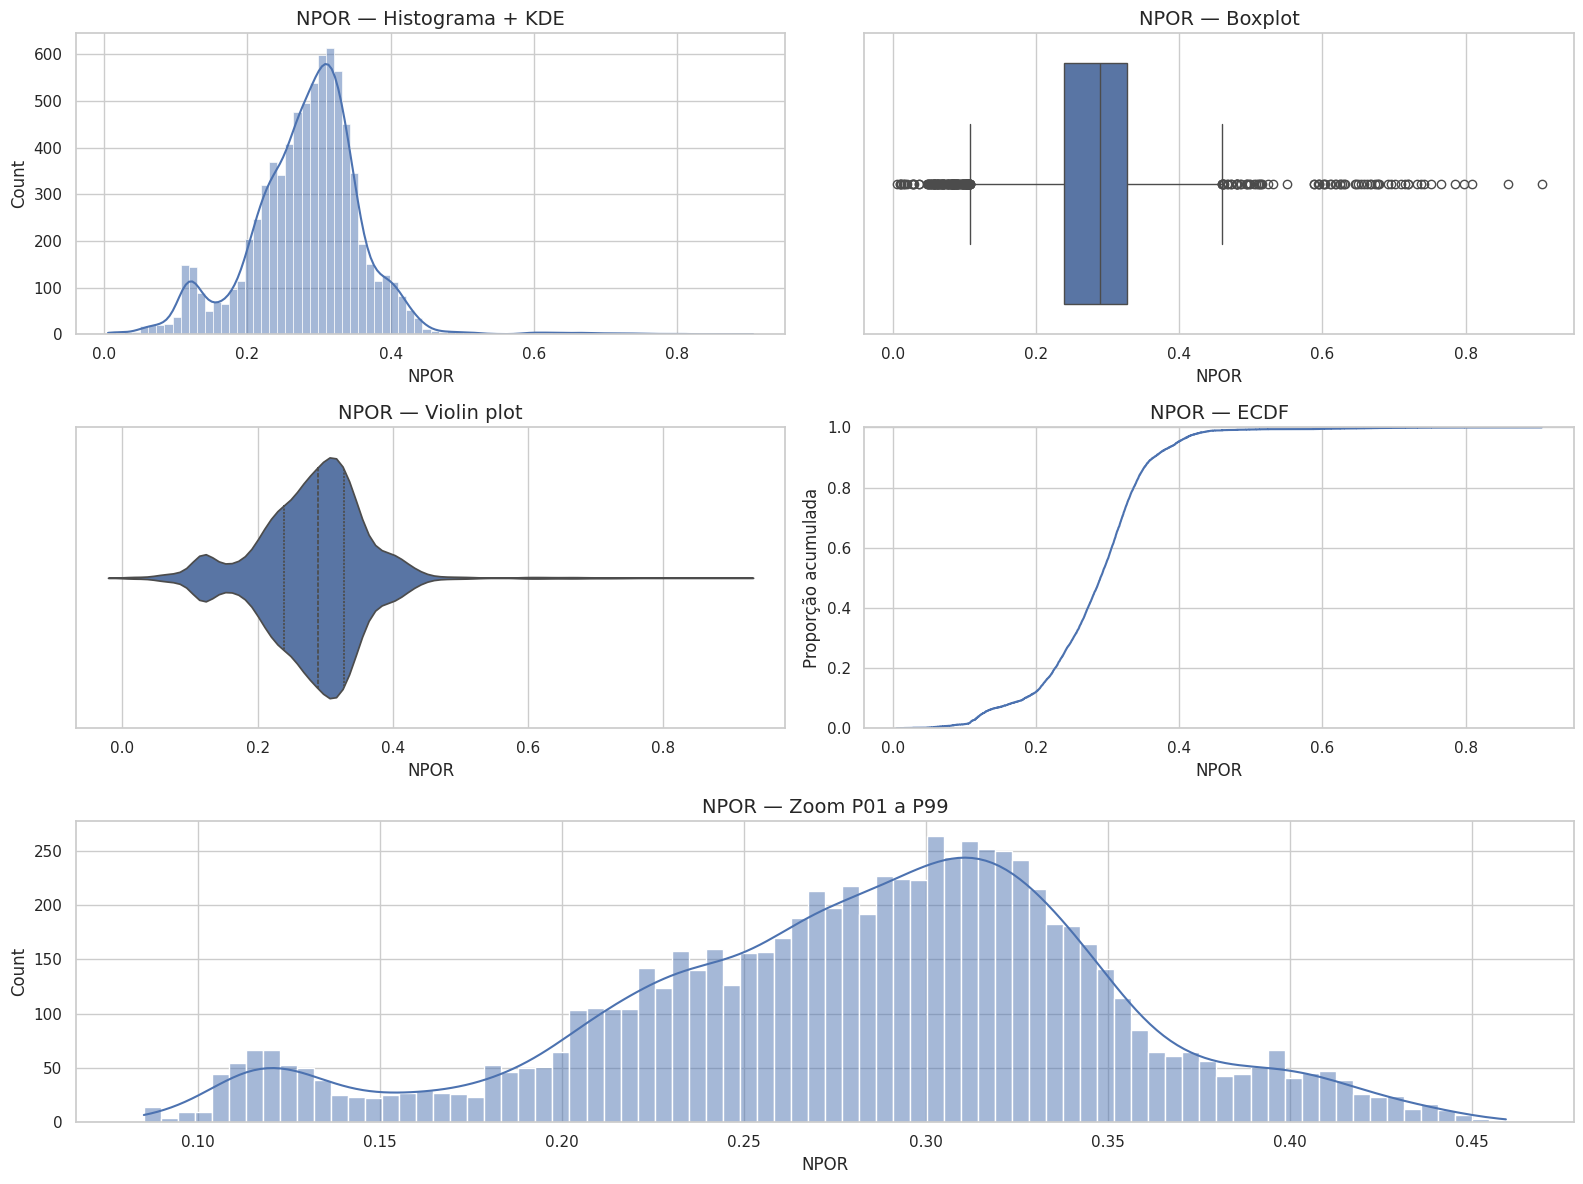

In [17]:
# ============================================================
# STEP 4.1 — DISTRIBUIÇÕES DAS PROPRIEDADES PRINCIPAIS
# ============================================================

for col in distribution_cols:
    plot_distribution_suite(df, col)

## Interpretação mental — distribuições

Cada conjunto de gráficos deve ser lido assim:

### Histograma + KDE

Mostra onde os valores se concentram.  
Se houver dois ou mais picos, pode existir mistura de litologias, zonas ou populações físicas diferentes.

### Boxplot

Mostra mediana, quartis e extremos.  
Muito útil para ver caudas e pontos distantes, mas não deve ser usado sozinho para remover dados.

### Violin plot

Mostra a forma da distribuição.  
Ajuda a perceber se a propriedade tem corpo largo, cauda, assimetria ou múltiplos grupos.

### ECDF

Mostra a proporção acumulada.  
Ajuda a responder perguntas como: “80% dos valores estão abaixo de quanto?”

### Zoom P01–P99

Remove visualmente os extremos para enxergar melhor o corpo principal da distribuição.

Conclusão prática:

Se uma propriedade apresenta múltiplos picos, ela pode estar mostrando heterogeneidade real.  
Se apresenta cauda extrema, pode ser outlier, mudança física ou problema de dado.  
Se é muito concentrada, pode indicar intervalo homogêneo ou curva pouco informativa.

# STEP 5 — Resistivity in Log Scale

Resistividade quase nunca se comporta bem em escala linear.

Ela costuma ter:
- cauda longa;
- variações de ordens de grandeza;
- distribuição muito assimétrica.

Por isso, vamos criar `LOG10_RDEP`, `LOG10_RMED` e `LOG10_RSHA` quando possível.

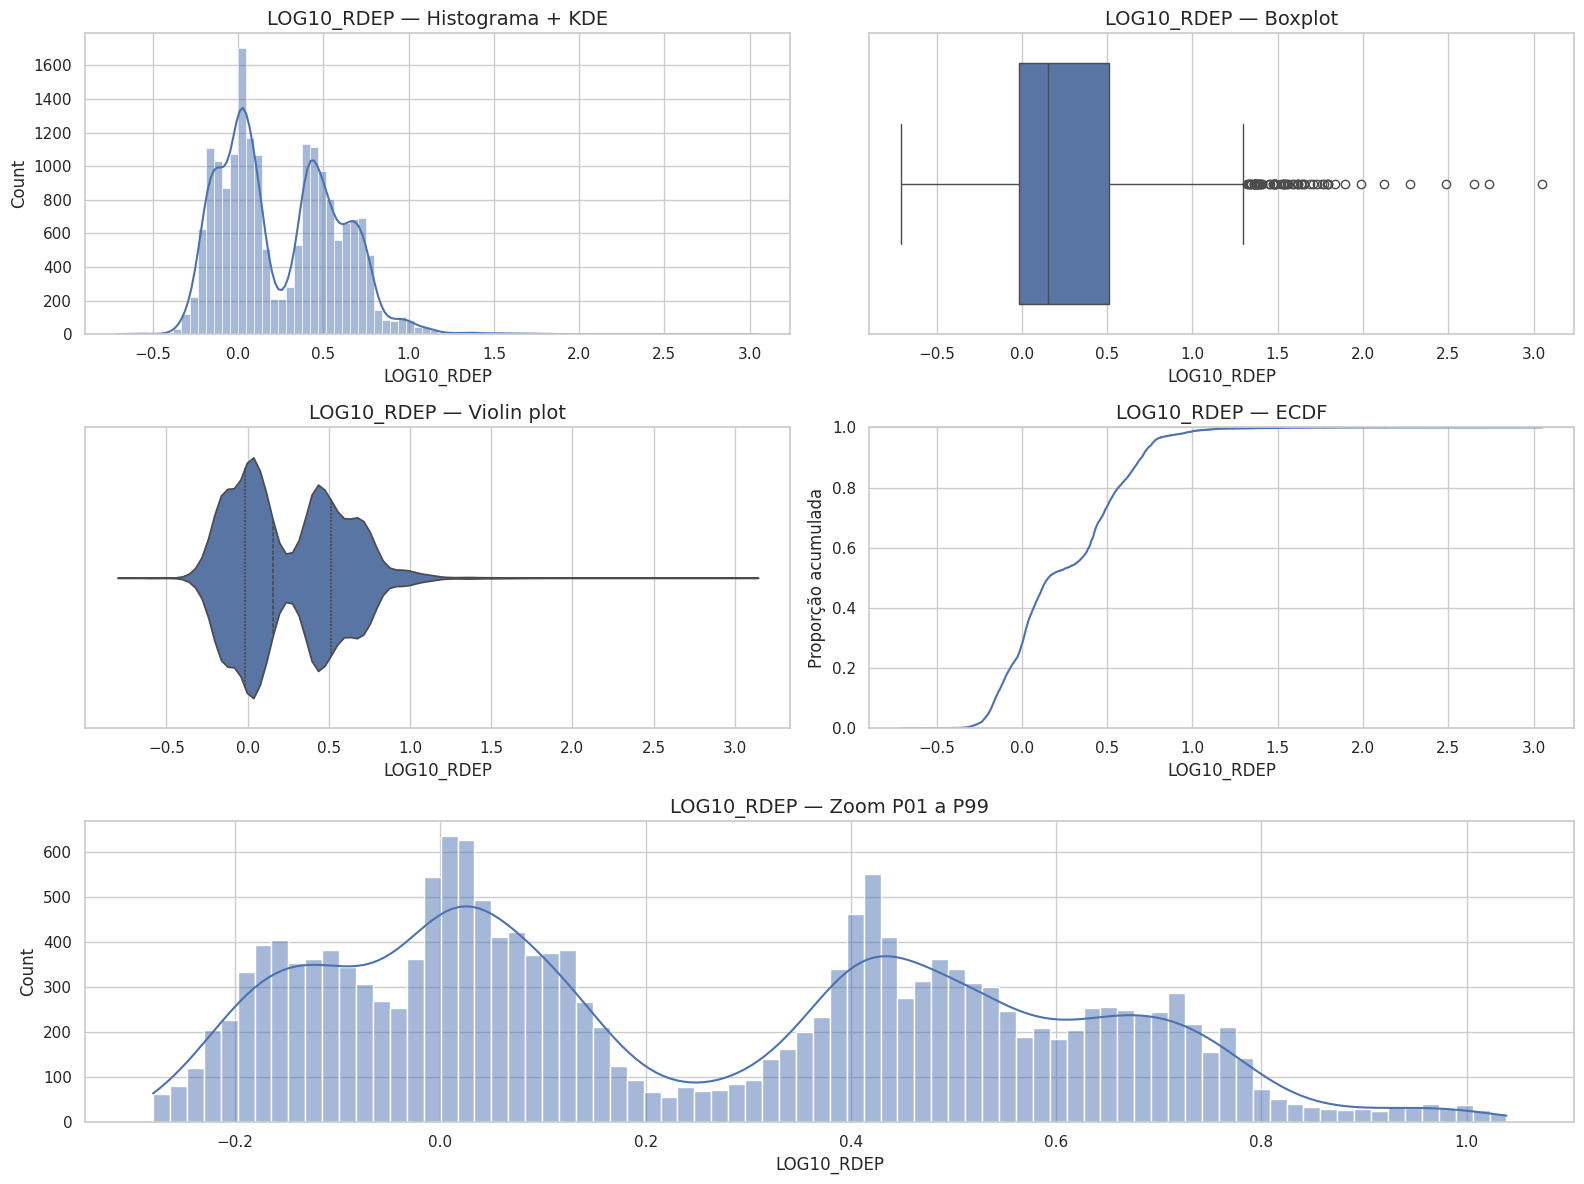

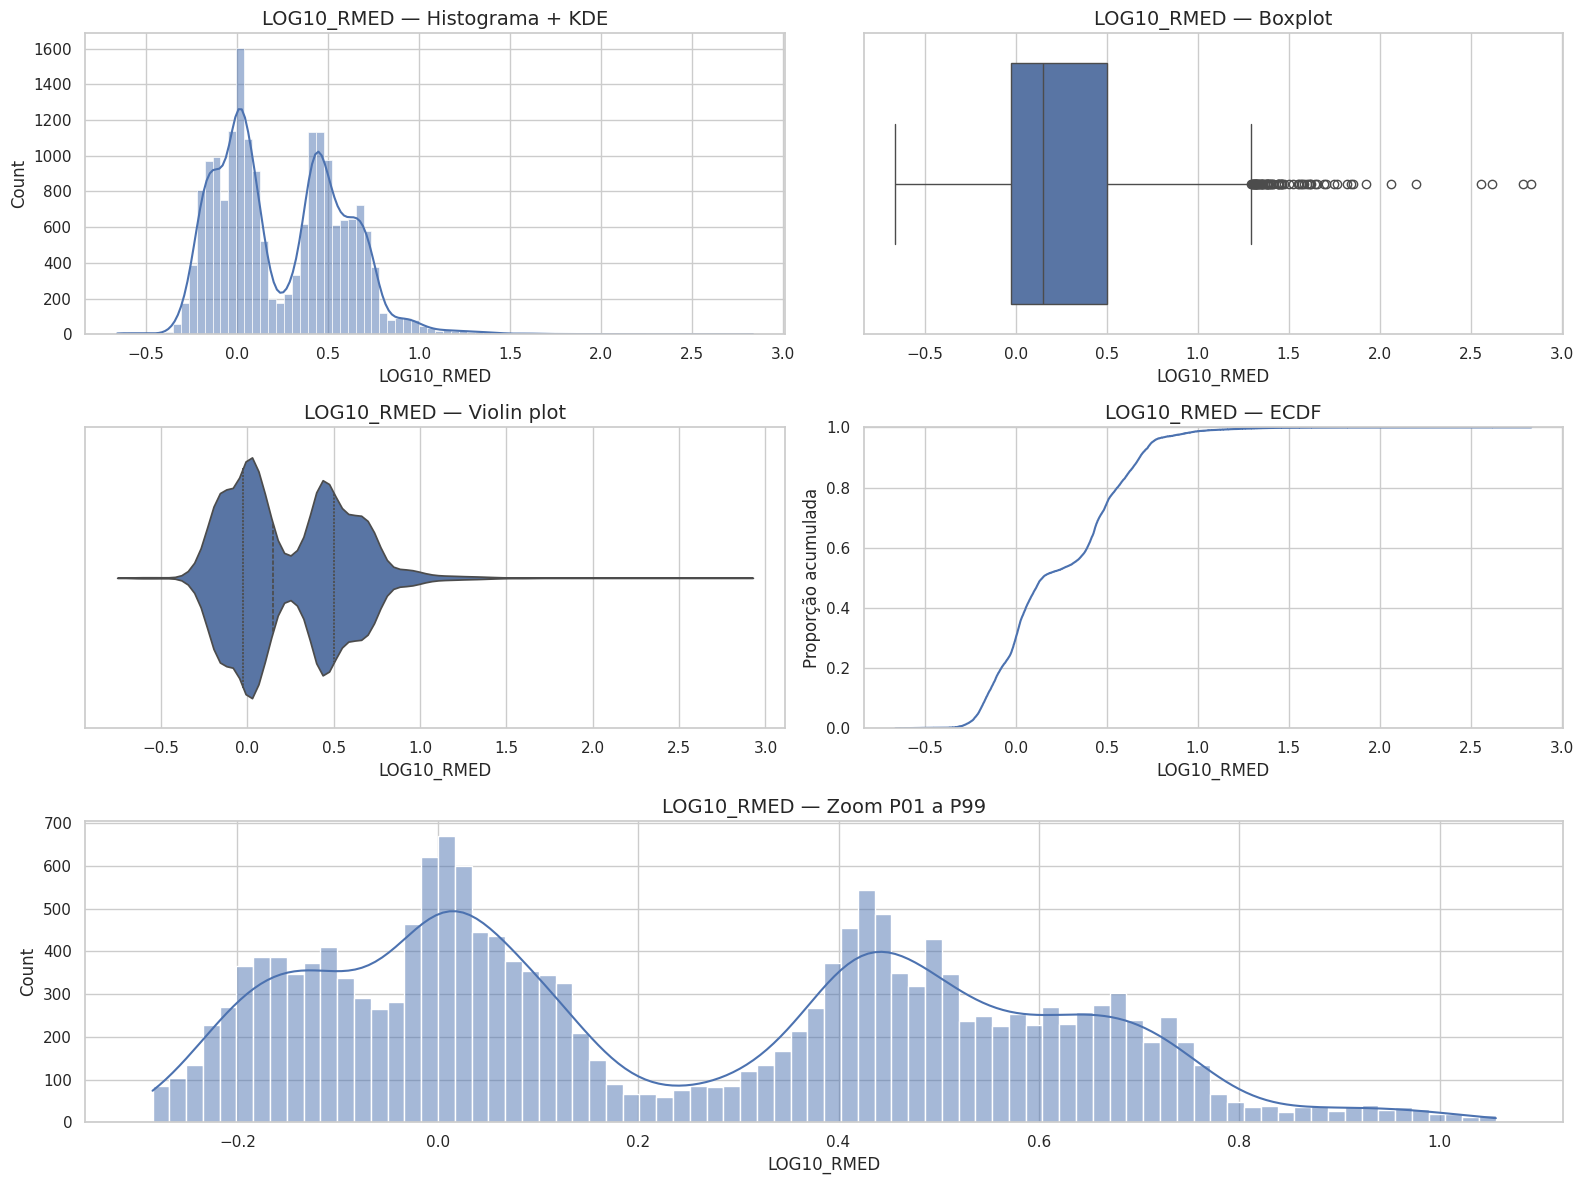

In [18]:
# ============================================================
# STEP 5 — RESISTIVITY IN LOG SCALE
# ============================================================

res_cols = [c for c in ["RDEP", "RMED", "RSHA"] if c in df.columns]

analytics_df = df.copy()

for col in res_cols:
    analytics_df[f"LOG10_{col}"] = np.log10(analytics_df[col].where(analytics_df[col] > 0))

for col in [f"LOG10_{c}" for c in res_cols]:
    if col in analytics_df.columns and analytics_df[col].notna().any():
        plot_distribution_suite(analytics_df, col, bins=80)

## Interpretação mental — resistividade em escala log

A resistividade em escala linear pode esconder quase tudo, porque poucos valores muito altos dominam o gráfico.

Quando usamos `log10`:

- valores baixos e altos ficam mais comparáveis;
- padrões internos aparecem melhor;
- possíveis populações diferentes ficam mais visíveis;
- a análise estatística fica mais estável.

Conclusão prática:

Para resistividade, prefira sempre analisar também em escala log.  
Média de resistividade linear pode ser muito enganosa.

# STEP 6 — Depth Log Plots

Agora voltamos ao eixo mais importante: profundidade.

Um log plot mostra como cada propriedade varia verticalmente.

Perguntas:

- existem zonas bem definidas?
- há tendências com profundidade?
- há mudanças abruptas?
- existem intervalos estáveis?
- existem intervalos ruidosos?

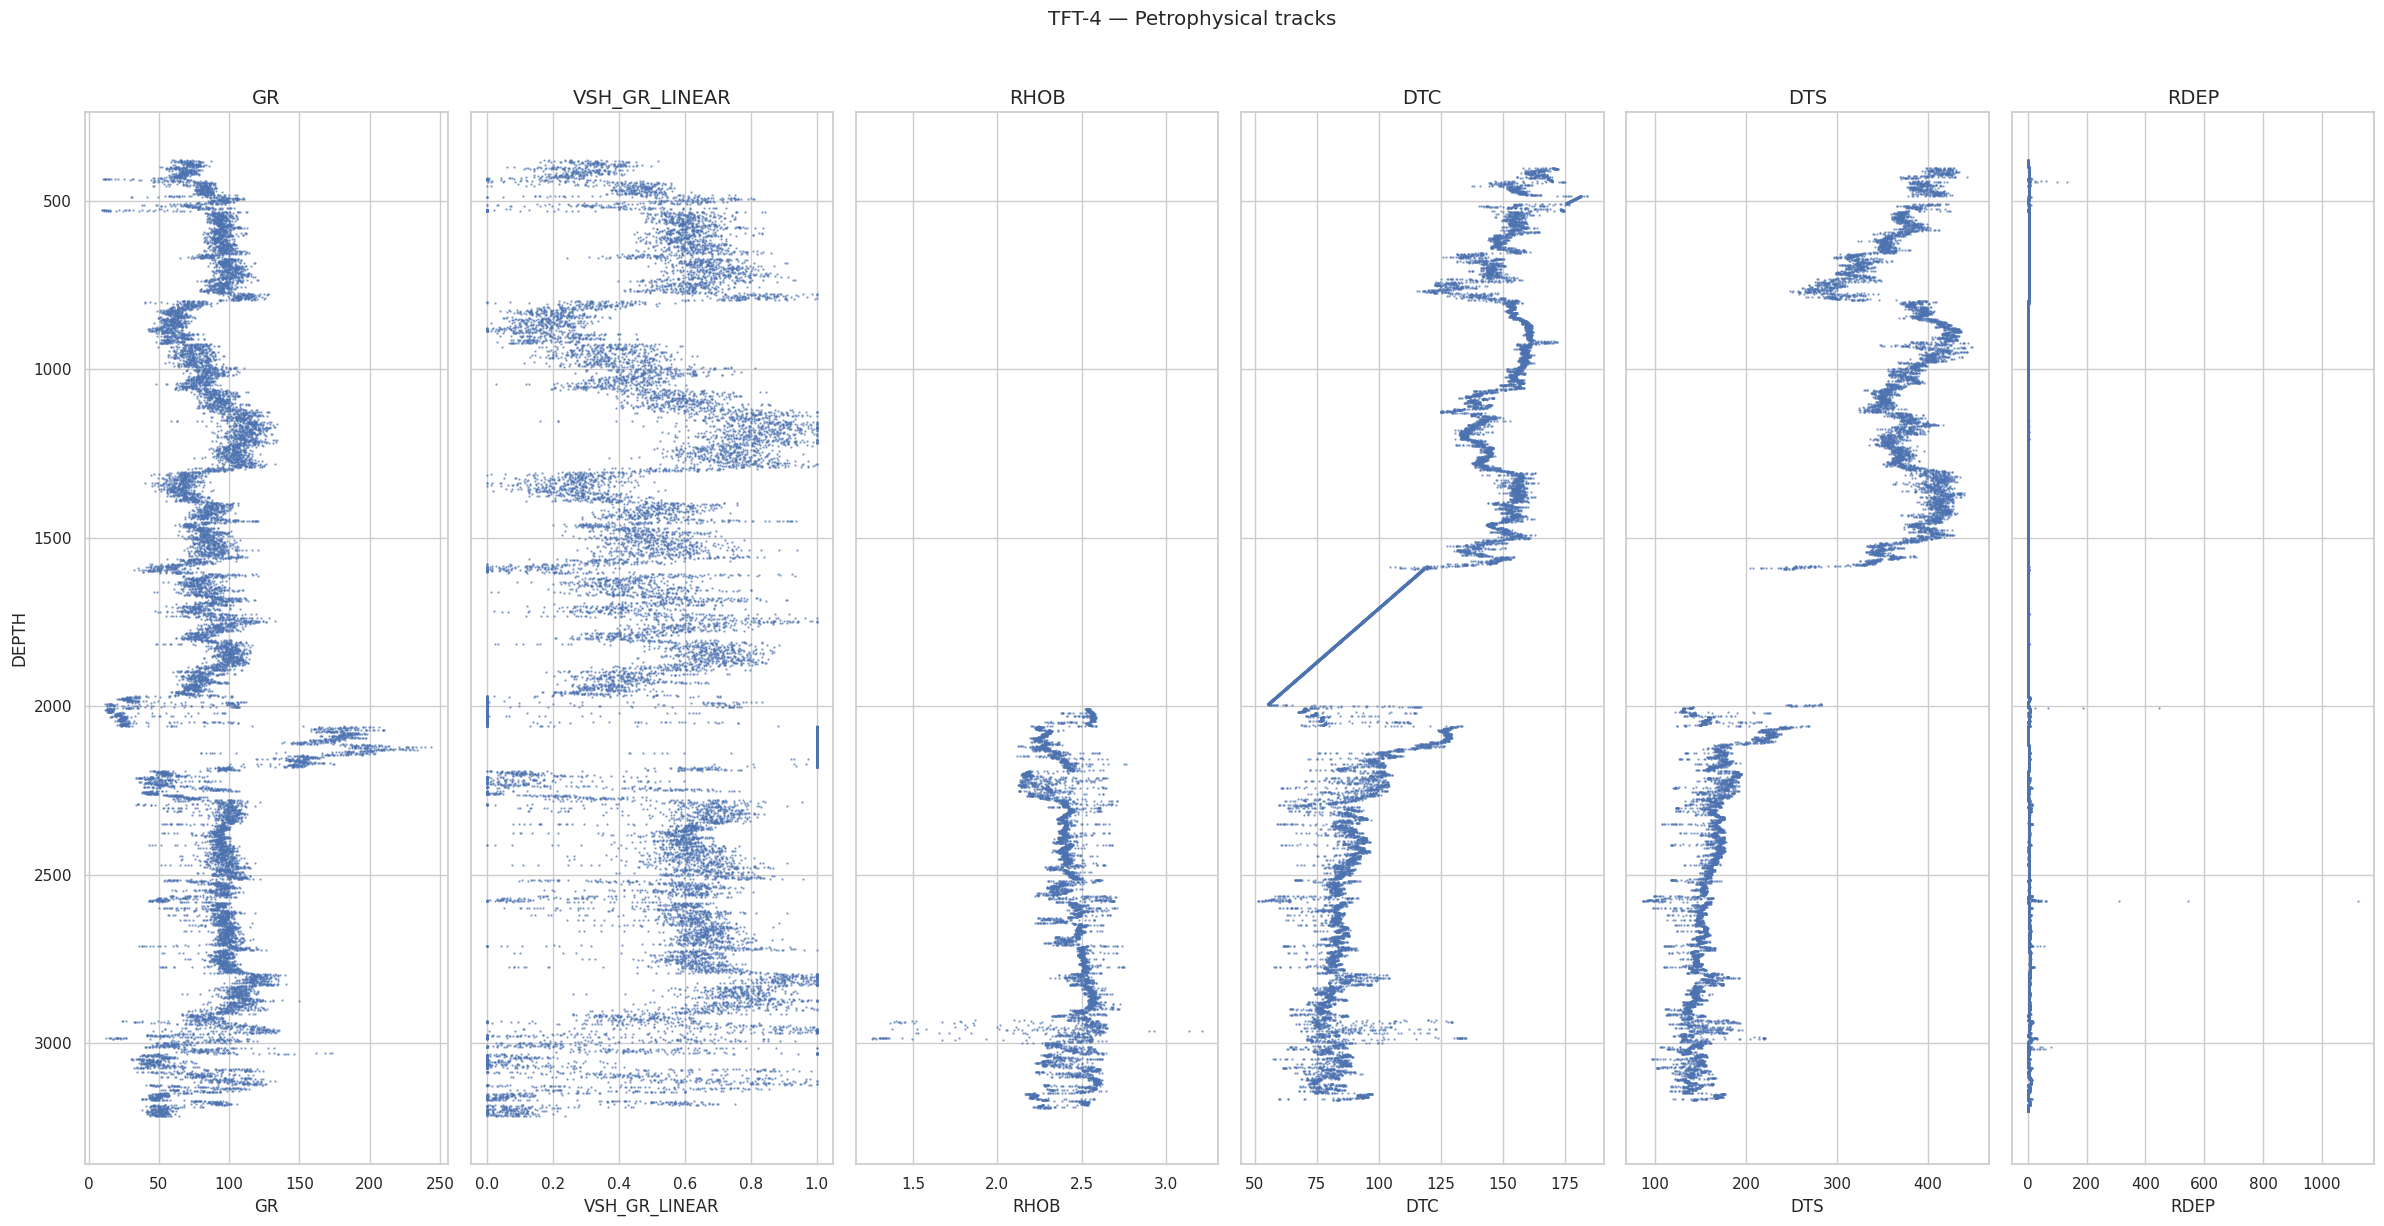

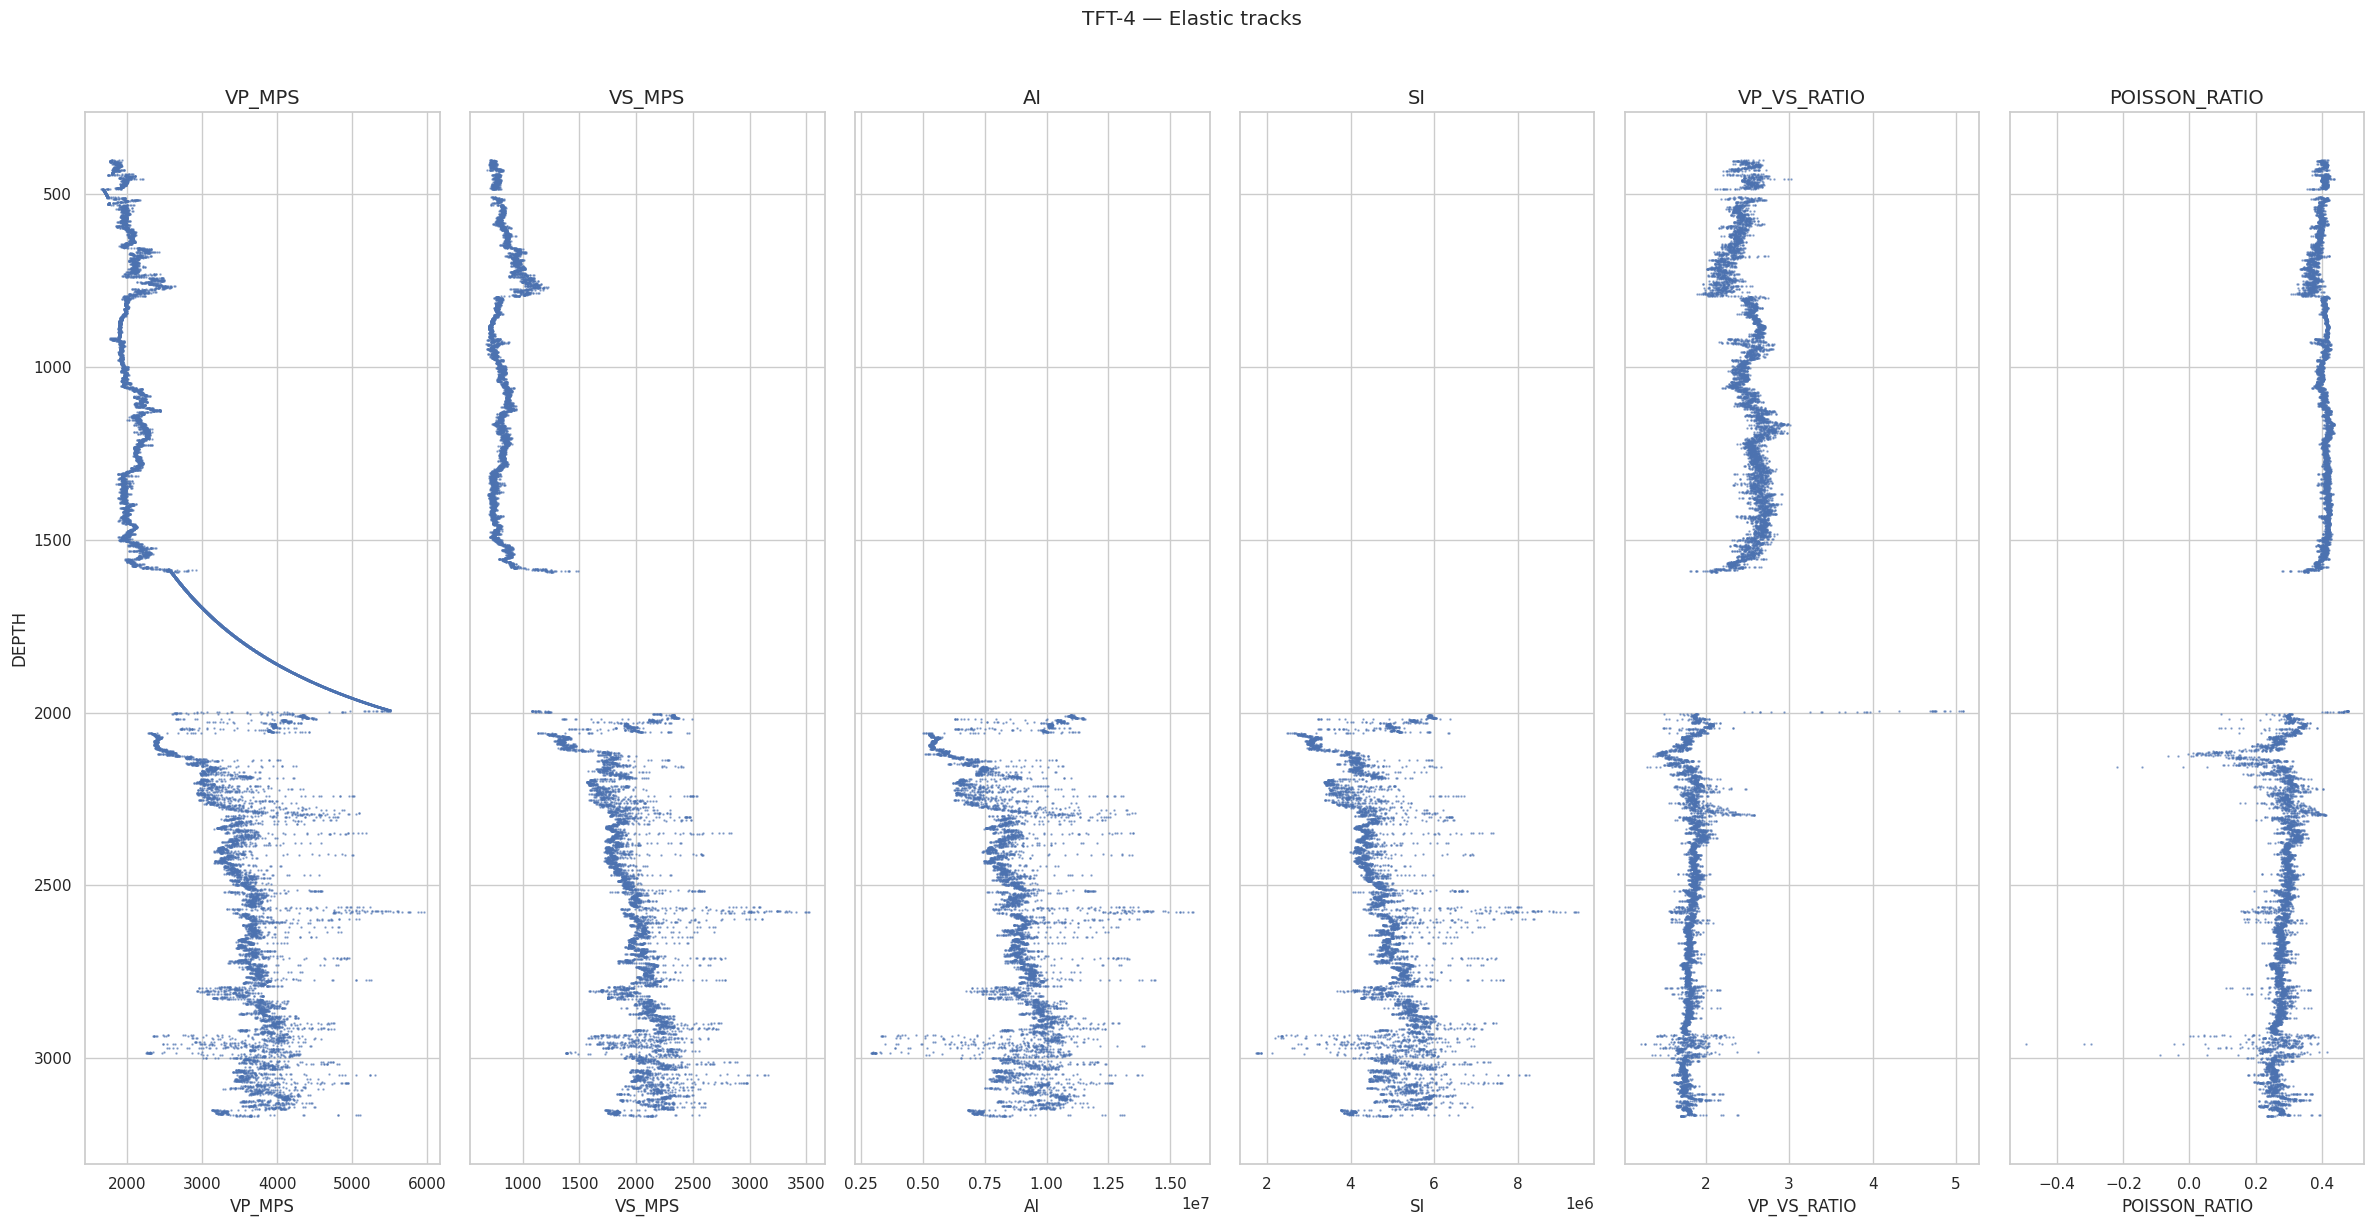

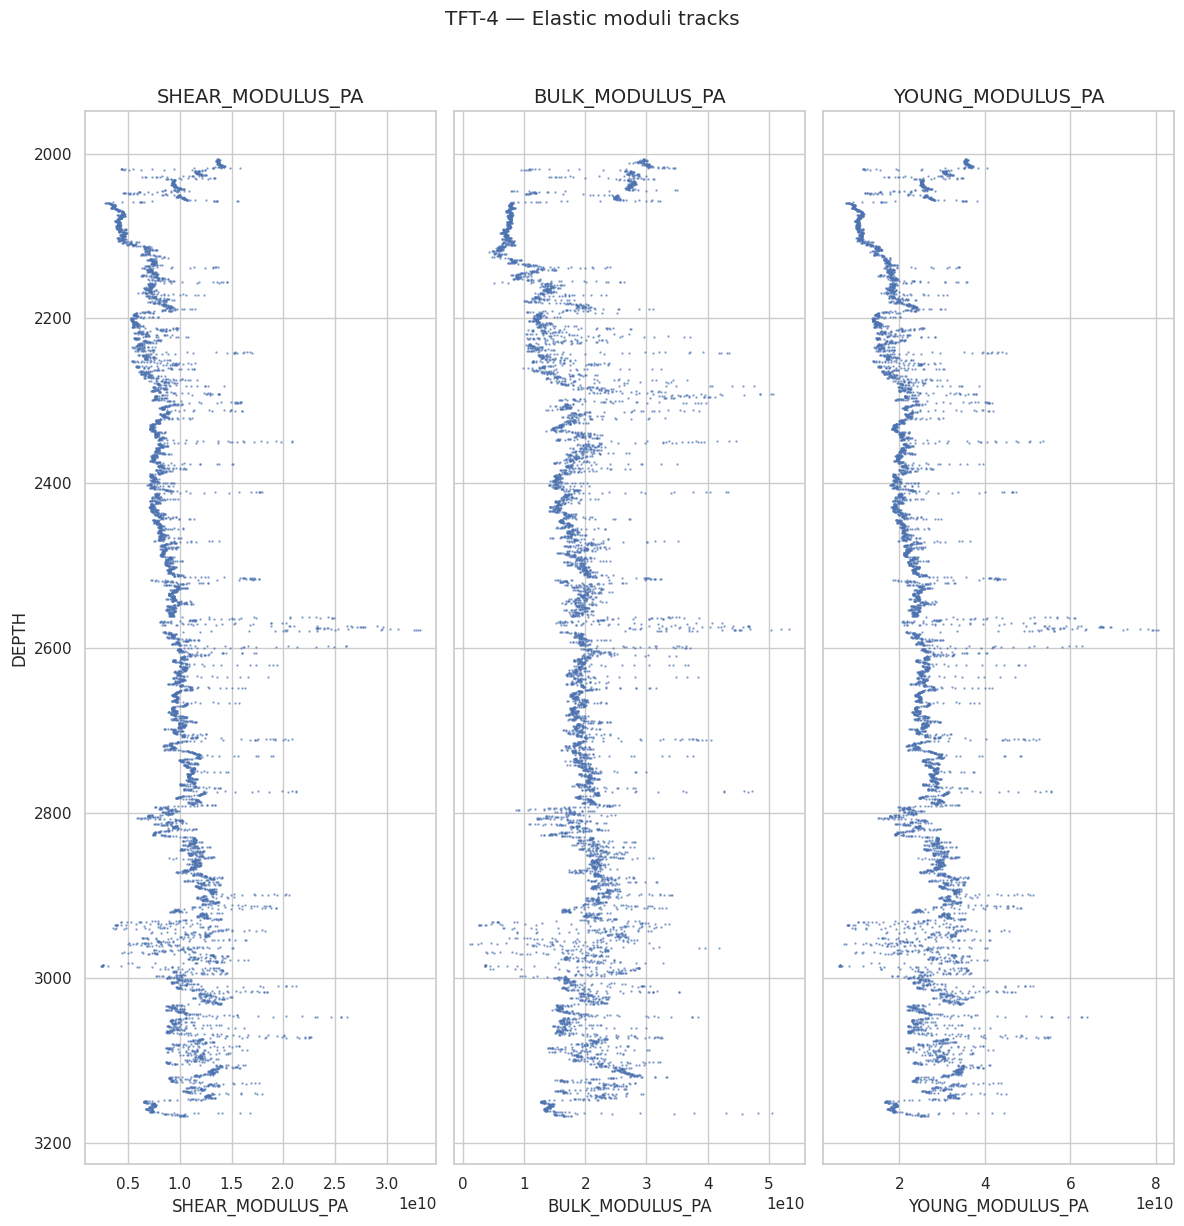

In [19]:
# ============================================================
# STEP 6 — DEPTH LOG PLOTS
# ============================================================

def plot_depth_tracks(df: pd.DataFrame, curves: List[str], depth_col: str = "DEPTH", title: str = "Depth tracks", max_points: int = 40_000) -> None:
    curves = [c for c in curves if c in df.columns and df[c].notna().any()]

    if not curves:
        print("Nenhuma curva disponível.")
        return

    plot_df = df[[depth_col] + curves].dropna(subset=[depth_col]).copy()

    if len(plot_df) > max_points:
        step = max(1, len(plot_df) // max_points)
        plot_df = plot_df.iloc[::step].copy()

    n = len(curves)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 12), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, curve in zip(axes, curves):
        ax.plot(plot_df[curve], plot_df[depth_col], ".", markersize=1.5, alpha=0.55)
        ax.set_title(curve)
        ax.set_xlabel(curve)
        ax.grid(True)

    axes[0].invert_yaxis()
    axes[0].set_ylabel(depth_col)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


plot_depth_tracks(
    analytics_df,
    ["GR", "VSH_GR_LINEAR", "RHOB", "DTC", "DTS", "RDEP"],
    title=f"{WELL_NAME} — Petrophysical tracks"
)

plot_depth_tracks(
    analytics_df,
    ["VP_MPS", "VS_MPS", "AI", "SI", "VP_VS_RATIO", "POISSON_RATIO"],
    title=f"{WELL_NAME} — Elastic tracks"
)

plot_depth_tracks(
    analytics_df,
    ["SHEAR_MODULUS_PA", "BULK_MODULUS_PA", "YOUNG_MODULUS_PA"],
    title=f"{WELL_NAME} — Elastic moduli tracks"
)

## Interpretação mental — log plots por profundidade

Este é um dos gráficos mais importantes em dados de poço.

Como interpretar:

- mudanças suaves podem indicar tendência de compactação;
- mudanças abruptas podem indicar transição litológica, contato, falha, mudança de formação ou problema de dado;
- GR alto e VSH alto sugerem regiões mais argilosas;
- RHOB, VP, VS e AI aumentando com profundidade podem indicar compactação;
- Vp/Vs e Poisson podem indicar mudanças de fluido, litologia ou comportamento mecânico;
- módulos elásticos altos indicam rocha mais rígida;
- módulos baixos indicam rocha mais macia ou menos consolidada.

Conclusão prática:

O eixo de profundidade transforma estatística em geologia.  
Sem profundidade, você vê distribuição.  
Com profundidade, você começa a ver história vertical do poço.

# STEP 7 — Rolling Statistics

Agora usamos janelas móveis.

Rolling mean mostra tendência local.  
Rolling std mostra heterogeneidade local.

Perguntas:

- onde a propriedade muda suavemente?
- onde fica ruidosa?
- onde existe transição?
- onde há intervalo homogêneo?

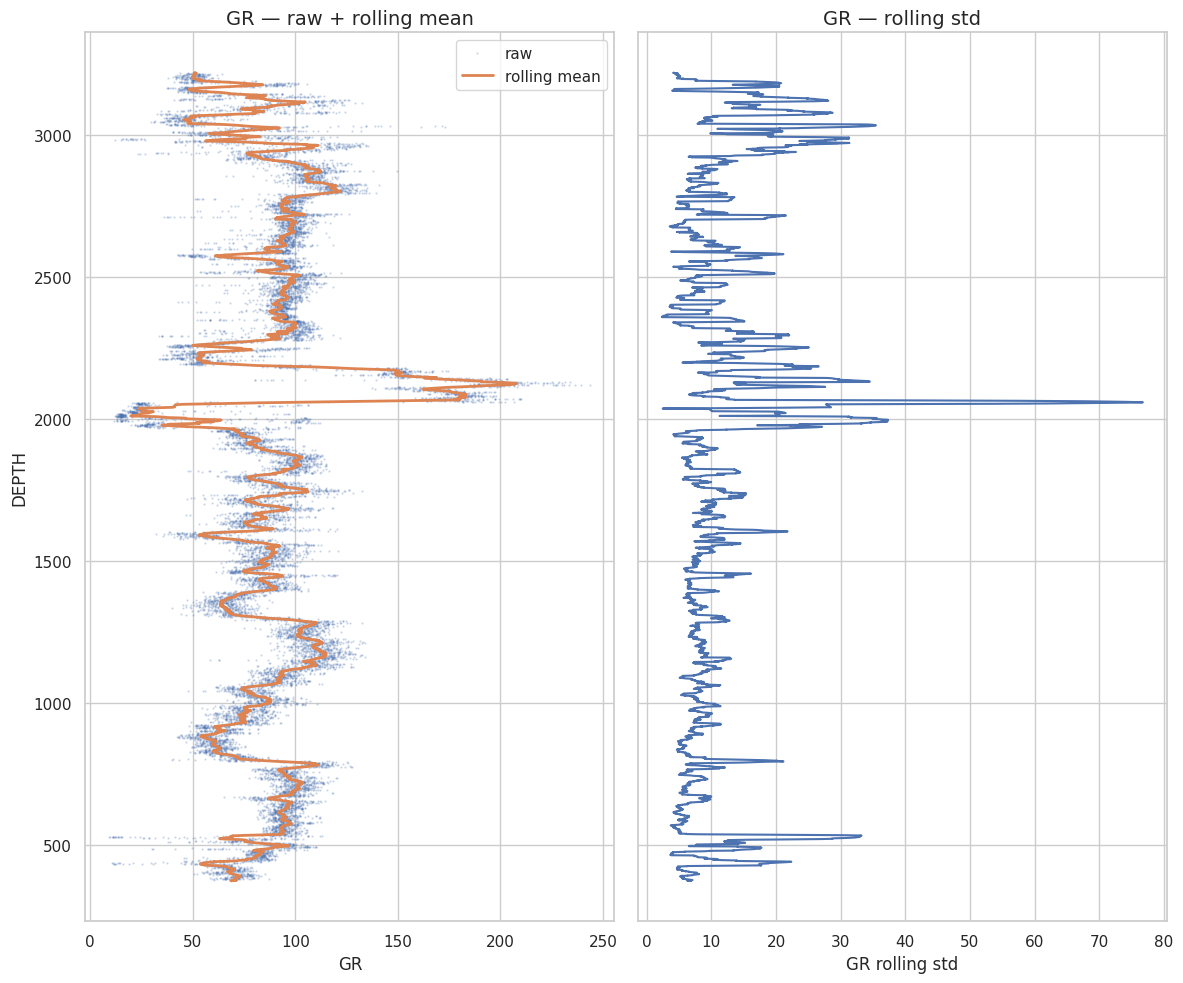

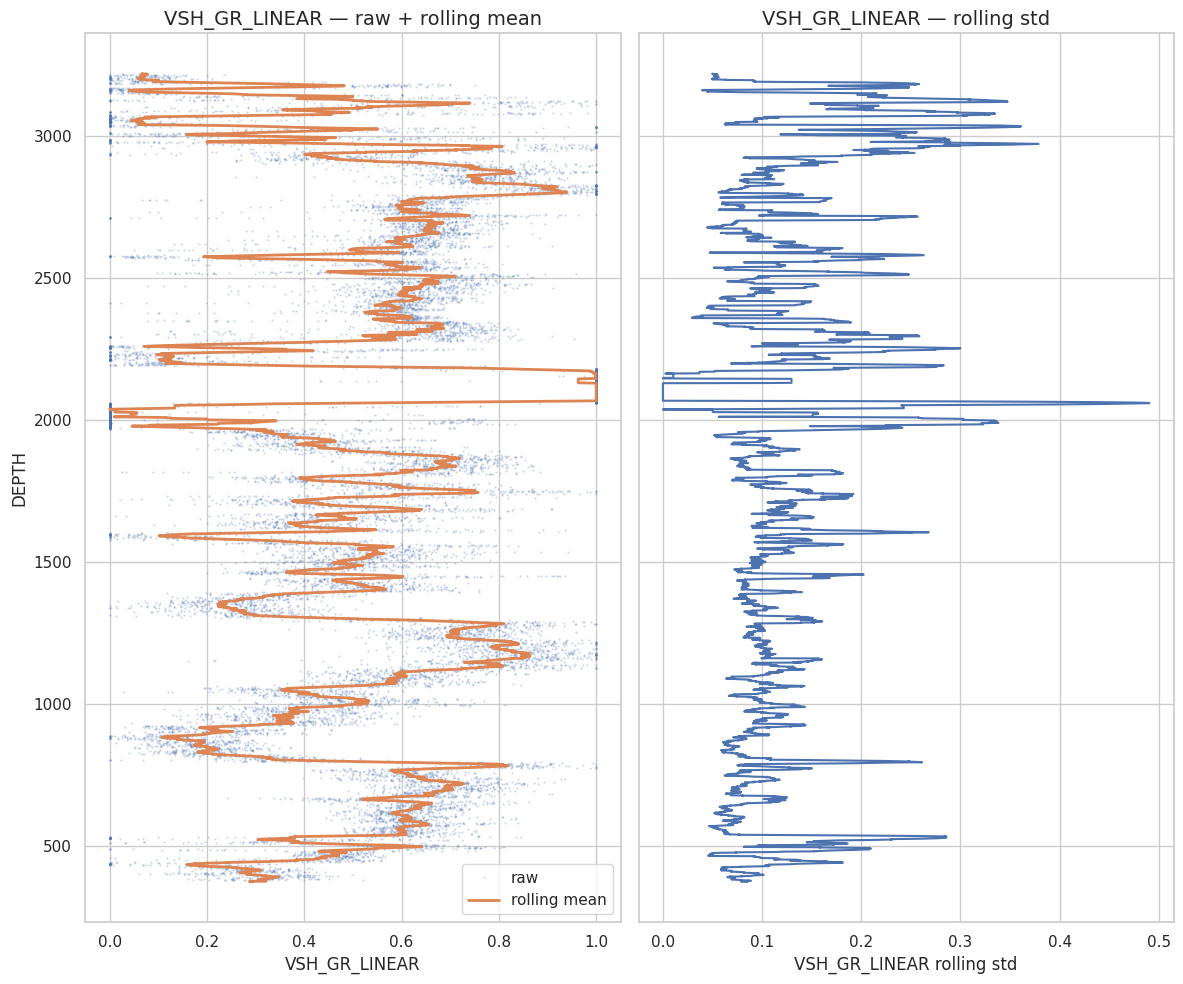

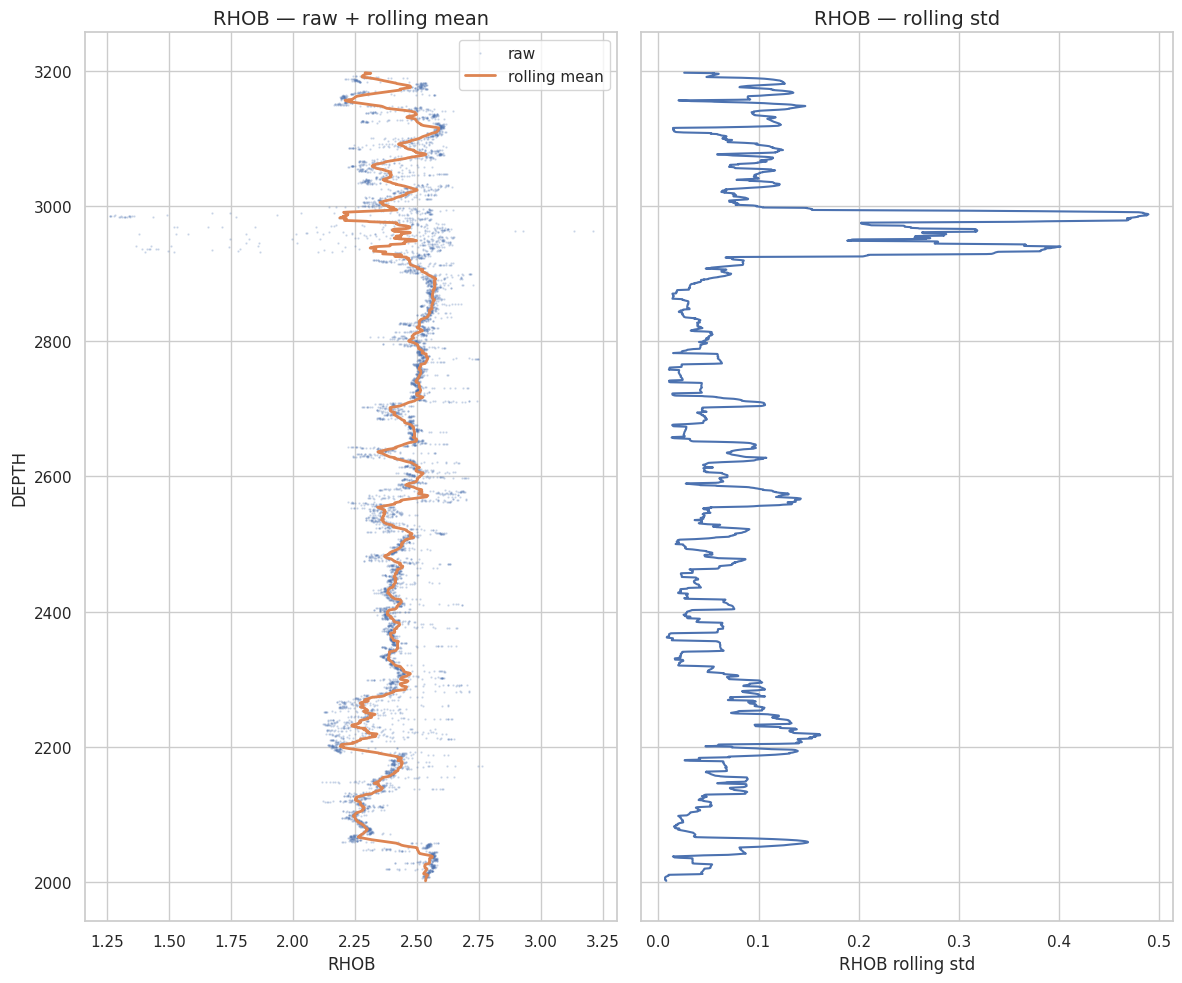

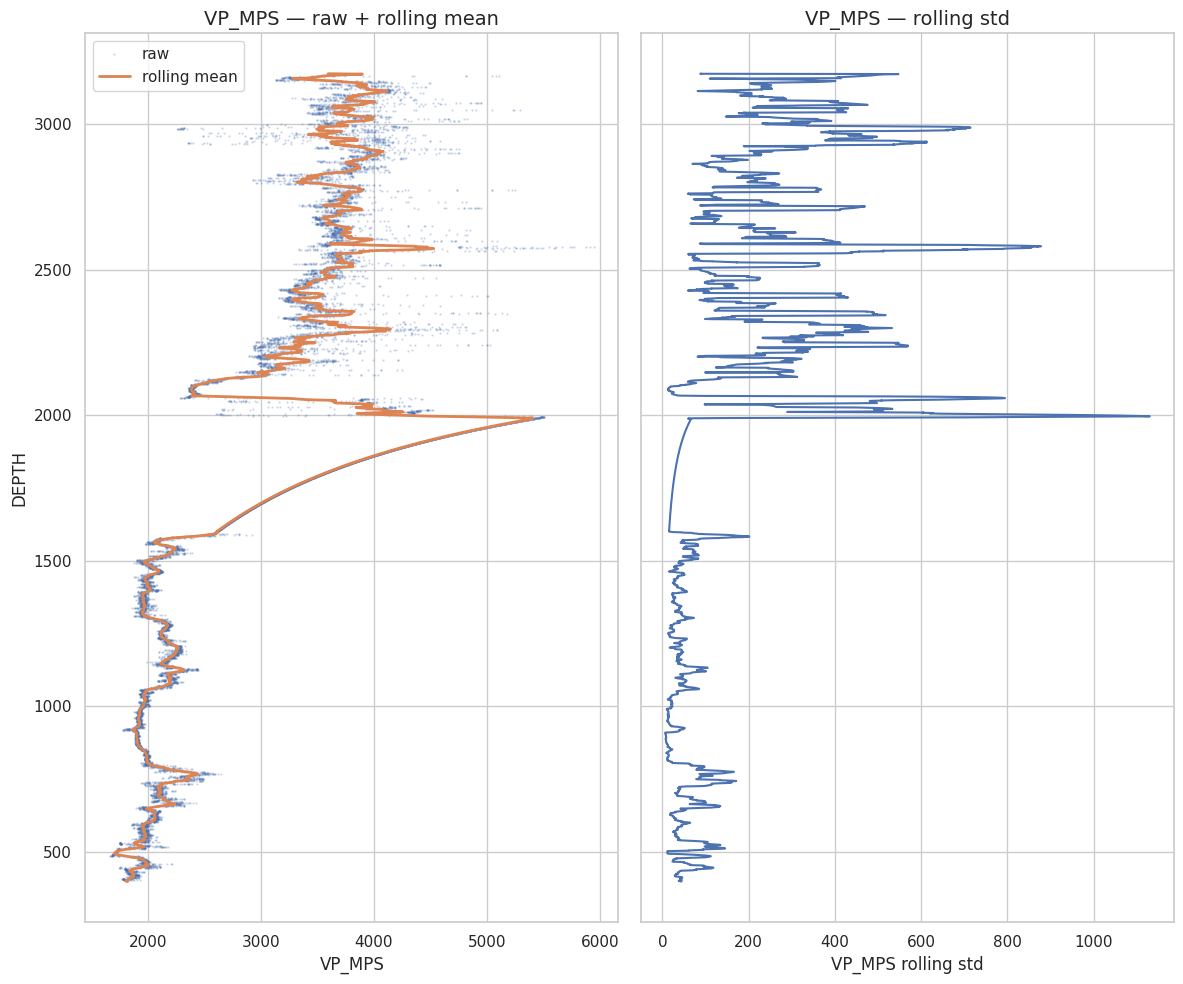

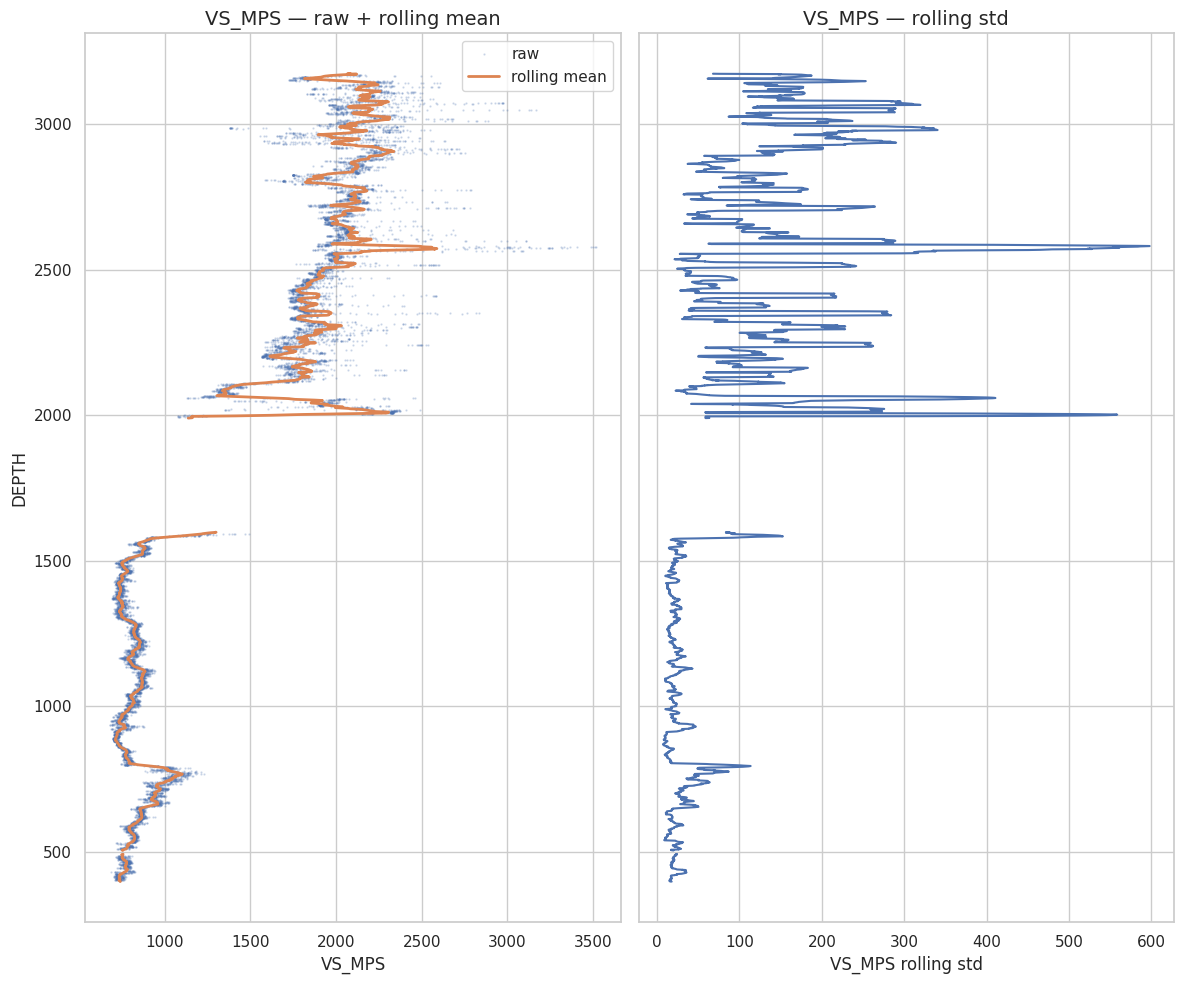

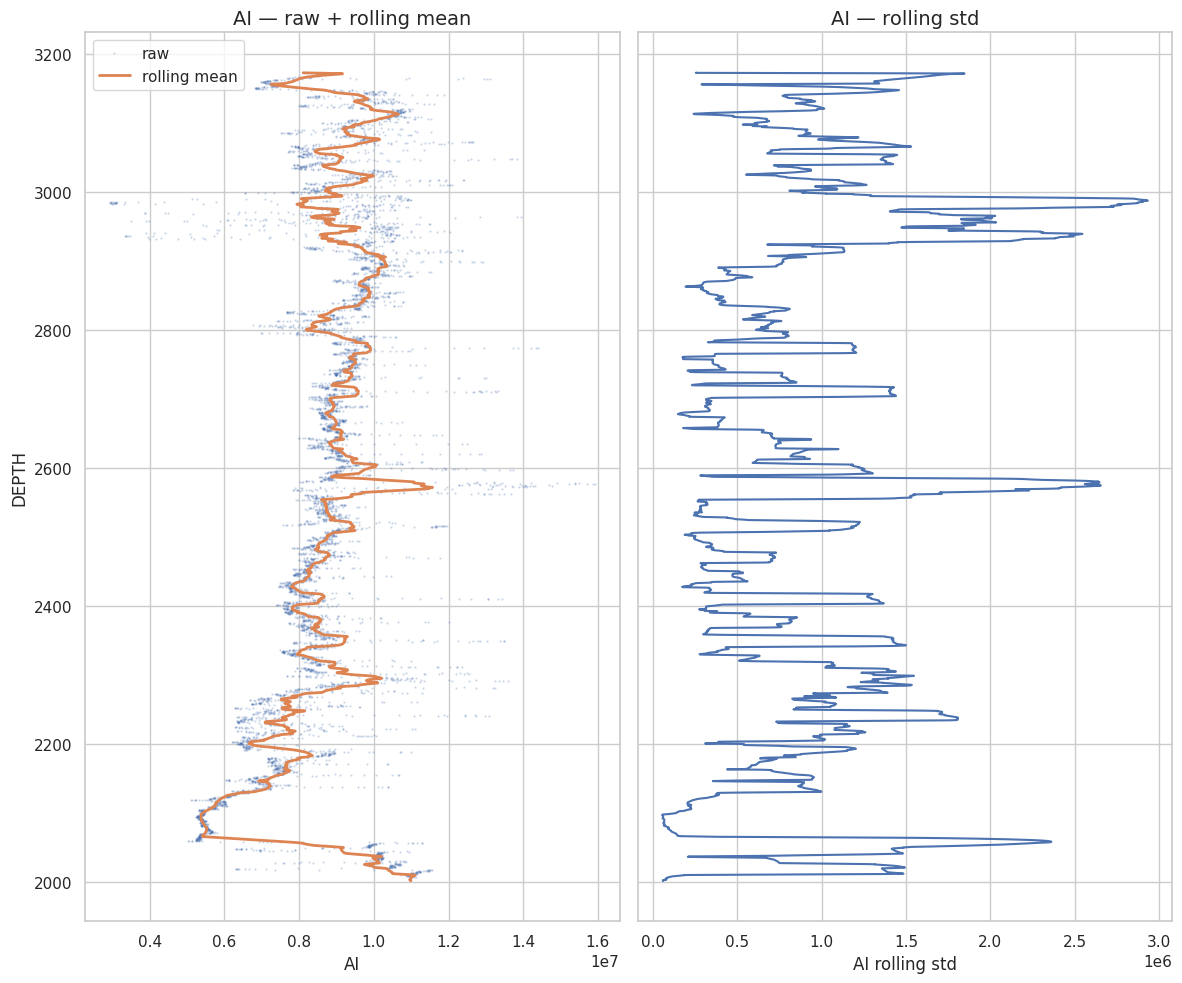

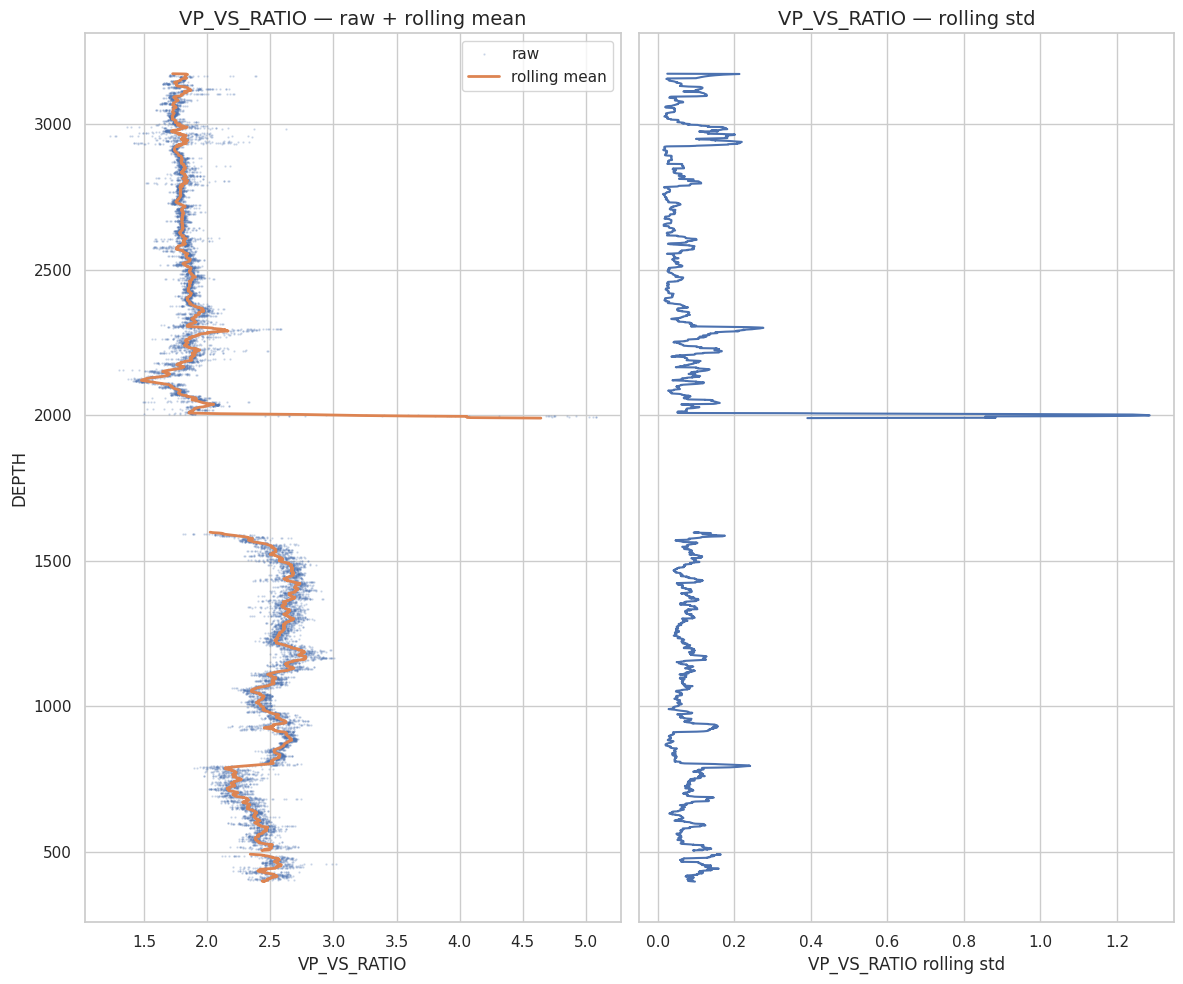

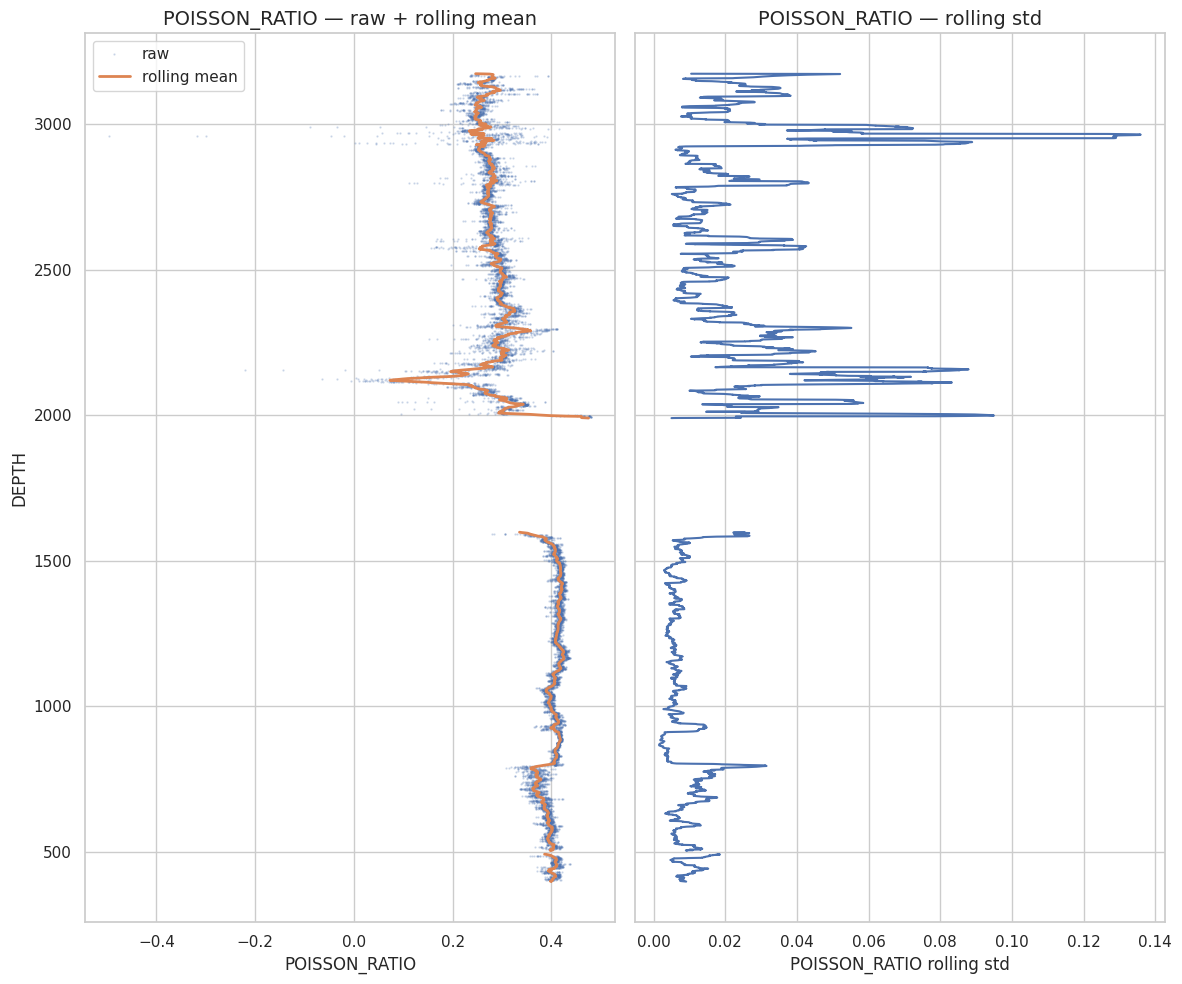

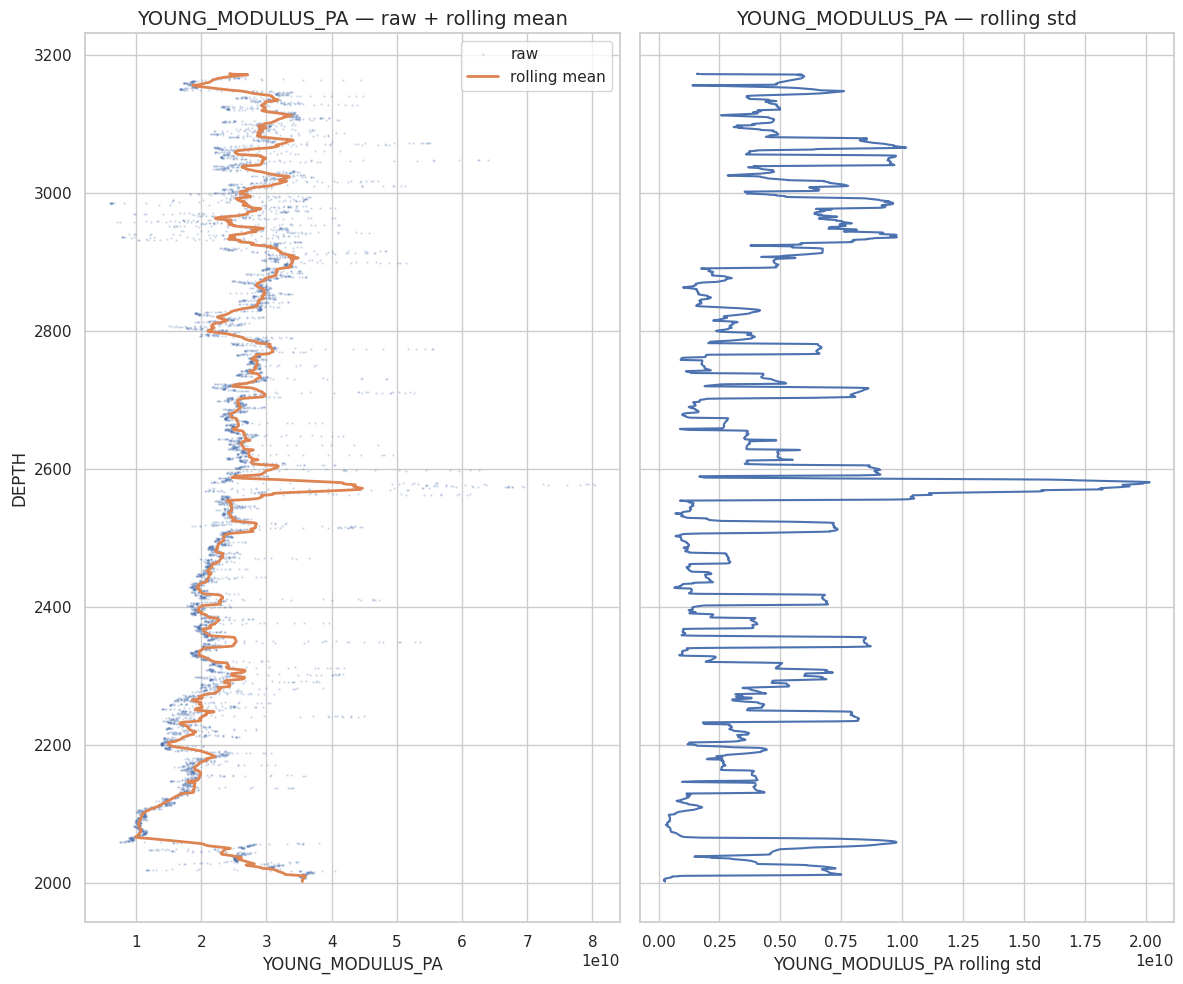

In [20]:
# ============================================================
# STEP 7 — ROLLING STATISTICS
# ============================================================

def add_rolling_features(df: pd.DataFrame, cols: List[str], window: int = 101) -> pd.DataFrame:
    out = df.sort_values("DEPTH").copy()

    for col in cols:
        if col not in out.columns or not out[col].notna().any():
            continue

        out[f"{col}_ROLL_MEAN"] = out[col].rolling(window=window, center=True, min_periods=max(5, window // 5)).mean()
        out[f"{col}_ROLL_STD"] = out[col].rolling(window=window, center=True, min_periods=max(5, window // 5)).std()

    return out


rolling_cols = [c for c in ["GR", "VSH_GR_LINEAR", "RHOB", "VP_MPS", "VS_MPS", "AI", "VP_VS_RATIO", "POISSON_RATIO", "YOUNG_MODULUS_PA"] if c in analytics_df.columns]

analytics_df = add_rolling_features(analytics_df, rolling_cols, window=101)


def plot_rolling(df: pd.DataFrame, col: str) -> None:
    if col not in df.columns:
        return

    mean_col = f"{col}_ROLL_MEAN"
    std_col = f"{col}_ROLL_STD"

    if mean_col not in df.columns or std_col not in df.columns:
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 10), sharey=True)

    axes[0].plot(df[col], df["DEPTH"], ".", markersize=1.2, alpha=0.25, label="raw")
    axes[0].plot(df[mean_col], df["DEPTH"], "-", linewidth=2, label="rolling mean")
    axes[0].invert_yaxis()
    axes[0].set_title(f"{col} — raw + rolling mean")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("DEPTH")
    axes[0].legend()

    axes[1].plot(df[std_col], df["DEPTH"], "-", linewidth=1.5)
    axes[1].invert_yaxis()
    axes[1].set_title(f"{col} — rolling std")
    axes[1].set_xlabel(f"{col} rolling std")

    plt.tight_layout()
    plt.show()


for col in rolling_cols:
    plot_rolling(analytics_df, col)

## Interpretação mental — rolling mean e rolling std

### Rolling mean

Mostra a tendência local da propriedade.  
Ela suaviza o ruído e ajuda a enxergar comportamento vertical.

Exemplos:
- AI aumentando com profundidade pode indicar compactação;
- GR aumentando pode indicar intervalo mais argiloso;
- VSH aumentando pode indicar piora da qualidade reservatório;
- VP e VS aumentando podem indicar rocha mais rígida.

### Rolling std

Mostra a variabilidade local.  
Valores altos indicam heterogeneidade, ruído ou transição.

Exemplos:
- rolling std alto em GR pode indicar alternância areia/folhelho;
- rolling std alto em AI pode indicar variação mecânica;
- rolling std alto em Vp/Vs pode indicar mudança de fluido/litologia ou problema de dado.

Conclusão prática:

Rolling mean ajuda a ver tendência.  
Rolling std ajuda a ver instabilidade.  
Juntas, elas ajudam a separar intervalos homogêneos de intervalos complexos.

# STEP 8 — Correlation Analysis

Agora estudamos relações entre propriedades.

Correlação ajuda a responder:

- quais propriedades caminham juntas?
- quais propriedades se opõem?
- existe relação entre VSH e AI?
- existe relação entre RHOB e VP?
- Vp/Vs se relaciona com Poisson?
- módulos elásticos se relacionam com compactação?

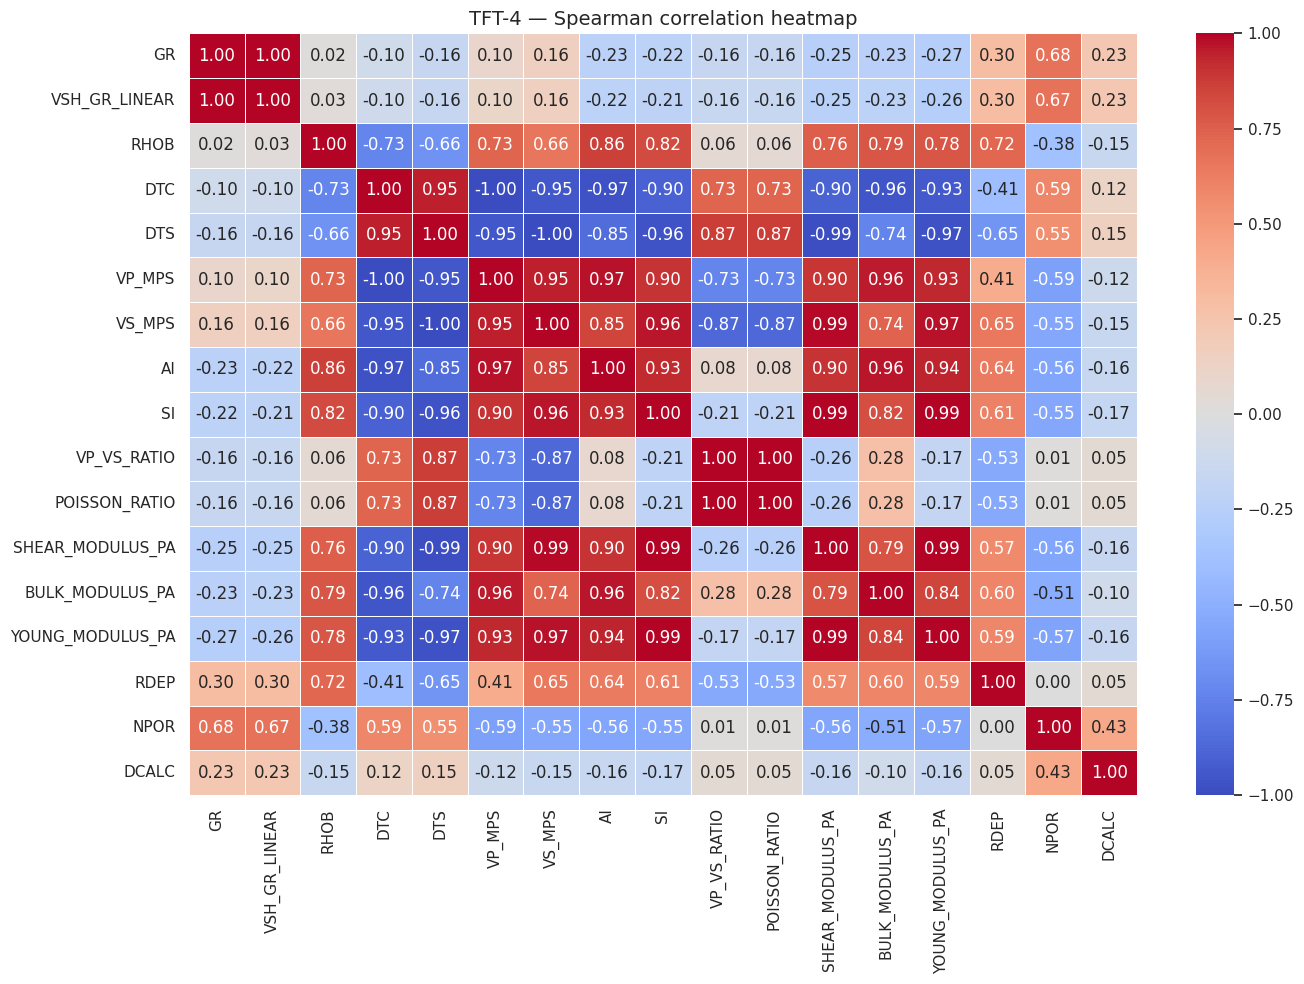

In [21]:
# ============================================================
# STEP 8 — CORRELATION ANALYSIS
# ============================================================

corr_cols = [
    "GR", "VSH_GR_LINEAR", "RHOB", "DTC", "DTS",
    "VP_MPS", "VS_MPS", "AI", "SI", "VP_VS_RATIO",
    "POISSON_RATIO", "SHEAR_MODULUS_PA", "BULK_MODULUS_PA",
    "YOUNG_MODULUS_PA", "RDEP", "NPOR", "DCALC"
]

corr_cols = [c for c in corr_cols if c in analytics_df.columns and analytics_df[c].notna().sum() > 10]

corr_df = analytics_df[corr_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title(f"{WELL_NAME} — Spearman correlation heatmap")
plt.tight_layout()
plt.show()

corr_df.to_csv(REPORT_DIR / f"{WELL_NAME}_spearman_correlation.csv")

## Interpretação mental — mapa de correlação

Use correlação como bússola, não como sentença final.

Como interpretar:

- valores próximos de +1 indicam que duas propriedades tendem a crescer juntas;
- valores próximos de -1 indicam que uma cresce enquanto a outra diminui;
- valores próximos de 0 indicam ausência de relação monotônica simples;
- Spearman é bom porque captura relações monotônicas e é mais robusto que Pearson para caudas e não linearidades.

Exemplos esperados:

- VP, VS, AI e módulos elásticos podem ter correlação positiva;
- DTC tende a se correlacionar negativamente com VP;
- GR e VSH devem ser fortemente correlacionados;
- RHOB e AI podem se correlacionar se compactação for dominante;
- DCALC pode se relacionar com leituras suspeitas se washout estiver afetando curvas.

Conclusão prática:

Correlação ajuda a escolher crossplots e hipóteses.  
Mas não prova causalidade.

# STEP 9 — Crossplots

Crossplots são fundamentais em petrofísica.

Eles mostram relações entre propriedades e podem revelar:
- populações diferentes;
- tendências;
- anomalias;
- clusters;
- relações físicas;
- possíveis litologias;
- mudanças de fluido;
- comportamento mecânico.

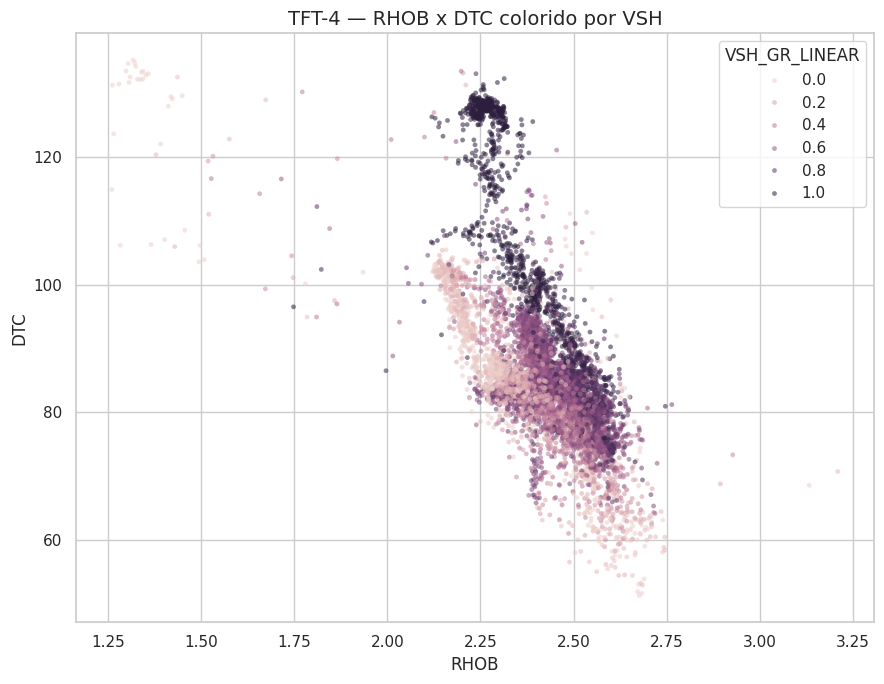

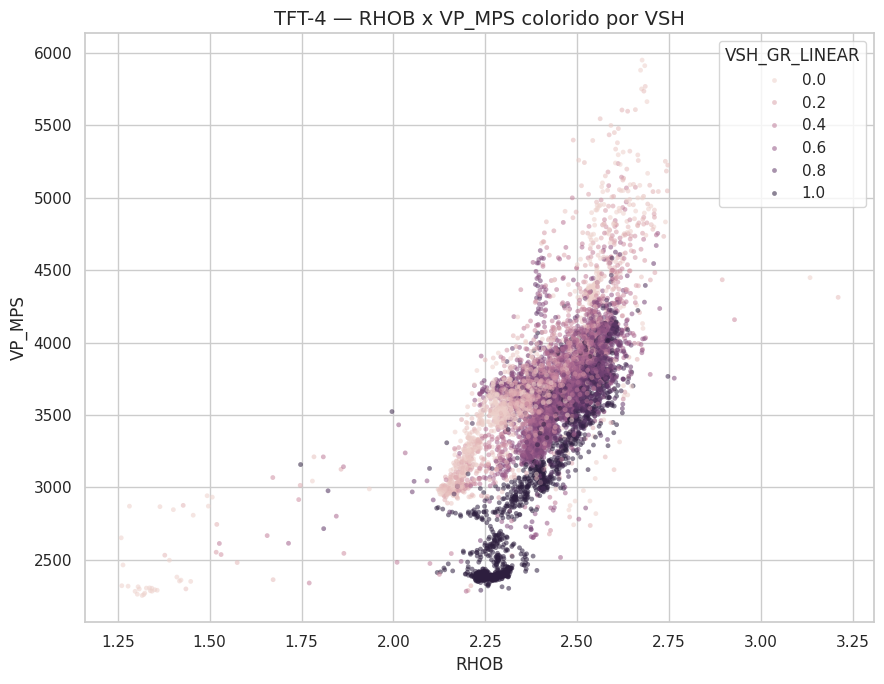

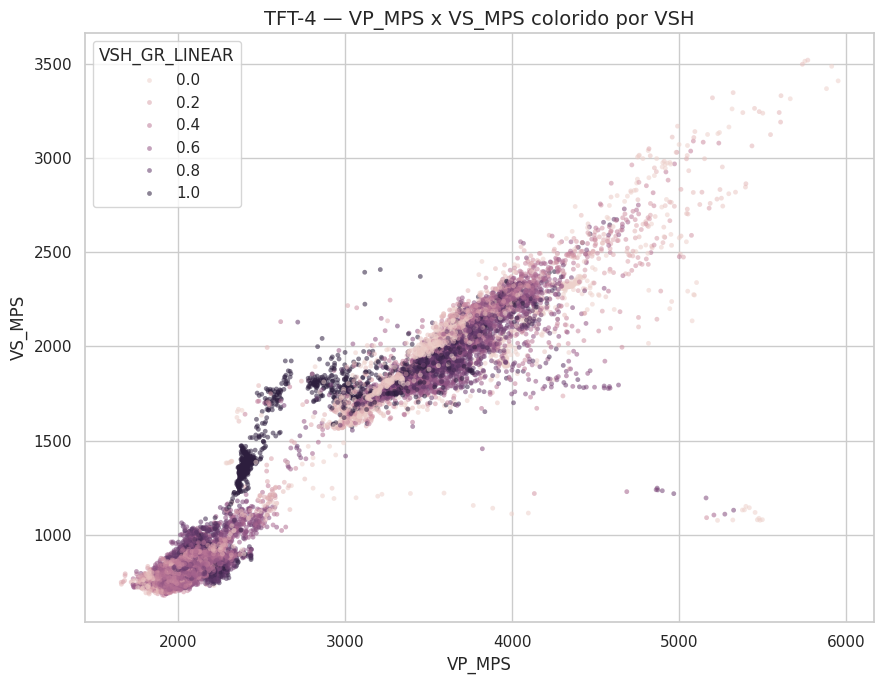

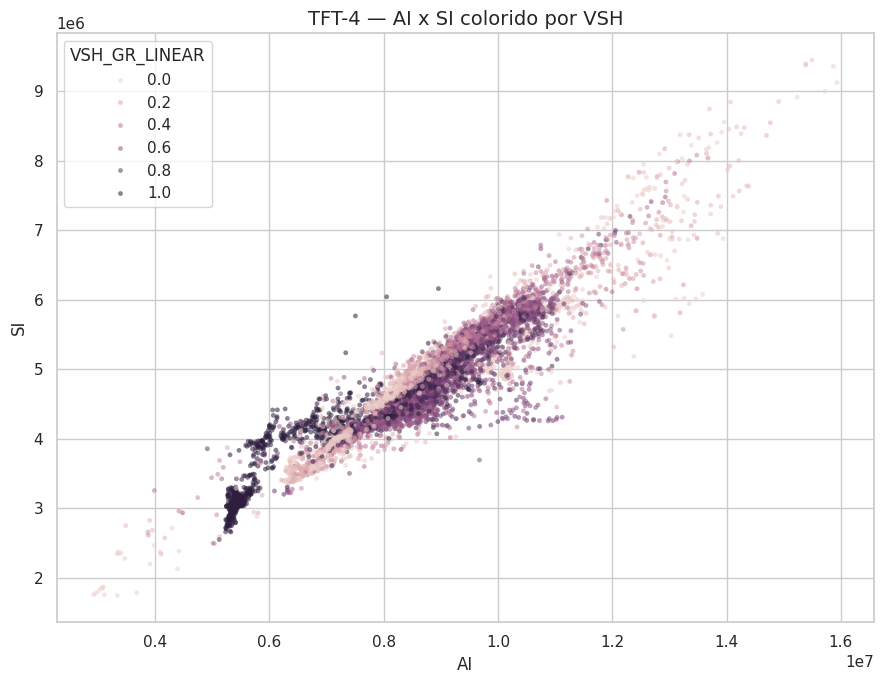

ValueError: Data must be 1-dimensional, got ndarray of shape (7642, 2) instead

<Figure size 900x700 with 0 Axes>

In [22]:
# ============================================================
# STEP 9 — CROSSPLOTS
# ============================================================

def scatter_crossplot(df: pd.DataFrame, x: str, y: str, hue: Optional[str] = None, title: Optional[str] = None, sample: int = 50_000) -> None:
    cols = [x, y] + ([hue] if hue and hue in df.columns else [])
    cols = [c for c in cols if c in df.columns]

    if x not in cols or y not in cols:
        print(f"Ignorando crossplot: {x} x {y}")
        return

    plot_df = df[cols].dropna().copy()

    if plot_df.empty:
        print(f"Sem dados para {x} x {y}")
        return

    if len(plot_df) > sample:
        plot_df = plot_df.sample(sample, random_state=42)

    plt.figure(figsize=(9, 7))
    if hue and hue in plot_df.columns:
        sns.scatterplot(data=plot_df, x=x, y=y, hue=hue, s=12, alpha=0.55, linewidth=0)
    else:
        sns.scatterplot(data=plot_df, x=x, y=y, s=12, alpha=0.55, linewidth=0)

    plt.title(title or f"{x} x {y}")
    plt.tight_layout()
    plt.show()


crossplot_pairs = [
    ("RHOB", "DTC"),
    ("RHOB", "VP_MPS"),
    ("VP_MPS", "VS_MPS"),
    ("AI", "SI"),
    ("VSH_GR_LINEAR", "AI"),
    ("VSH_GR_LINEAR", "VP_VS_RATIO"),
    ("VP_VS_RATIO", "POISSON_RATIO"),
    ("YOUNG_MODULUS_PA", "POISSON_RATIO"),
    ("GR", "RDEP"),
    ("DCALC", "RHOB"),
]

for x, y in crossplot_pairs:
    scatter_crossplot(analytics_df, x, y, hue="VSH_GR_LINEAR", title=f"{WELL_NAME} — {x} x {y} colorido por VSH")

## Interpretação mental — crossplots

Como ler crossplots:

- nuvem compacta indica relação mais estável;
- nuvem espalhada indica heterogeneidade, ruído ou múltiplos controles físicos;
- grupos separados podem indicar diferentes litologias ou zonas;
- pontos isolados podem ser anomalias ou fenômenos importantes;
- cor por VSH ajuda a separar regiões limpas e argilosas.

Ideias específicas:

- `RHOB x DTC`: ajuda a ver compactação, porosidade e possíveis leituras anômalas;
- `VP x VS`: relação fundamental para elasticidade;
- `AI x SI`: assinatura elástica da rocha;
- `VSH x AI`: mostra se argilosidade acompanha rigidez;
- `Vp/Vs x Poisson`: valida coerência física;
- `DCALC x RHOB`: pode revelar se washout afeta densidade.

Conclusão prática:

Crossplot é onde você começa a ver famílias físicas dentro dos dados.

# STEP 10 — Depth Interval Summary

Agora dividimos o poço em intervalos de profundidade.

Isso ajuda a responder:

- quais intervalos são mais limpos?
- quais são mais argilosos?
- onde AI é maior?
- onde Vp/Vs é maior?
- onde o módulo de Young é maior?
- onde há maior heterogeneidade?

In [ ]:
# ============================================================
# STEP 10 — DEPTH INTERVAL SUMMARY
# ============================================================

def build_depth_intervals(df: pd.DataFrame, interval_size: float = 50.0) -> pd.DataFrame:
    out = df.copy()

    depth_min = np.floor(out["DEPTH"].min() / interval_size) * interval_size
    depth_max = np.ceil(out["DEPTH"].max() / interval_size) * interval_size

    bins = np.arange(depth_min, depth_max + interval_size, interval_size)

    out["DEPTH_INTERVAL"] = pd.cut(out["DEPTH"], bins=bins, include_lowest=True)

    return out


analytics_df = build_depth_intervals(analytics_df, interval_size=50.0)

summary_metrics = [c for c in [
    "GR", "VSH_GR_LINEAR", "RHOB", "VP_MPS", "VS_MPS", "AI", "SI",
    "VP_VS_RATIO", "POISSON_RATIO", "YOUNG_MODULUS_PA", "RDEP",
    "QC_FLAG_COUNT", "FEATURE_QC_FLAG_COUNT"
] if c in analytics_df.columns]

interval_summary = (
    analytics_df
    .groupby("DEPTH_INTERVAL", observed=True)[summary_metrics]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

# Achata colunas multi-index.
interval_summary.columns = [f"{col}_{stat}" for col, stat in interval_summary.columns]
interval_summary = interval_summary.reset_index()

display(interval_summary.head(30))

interval_summary.to_csv(REPORT_DIR / f"{WELL_NAME}_depth_interval_summary_50m.csv", index=False)

In [ ]:
# ============================================================
# STEP 10.1 — HEATMAP DE INTERVALOS
# ============================================================

heatmap_cols = [c for c in [
    "VSH_GR_LINEAR_median", "RHOB_median", "VP_MPS_median",
    "VS_MPS_median", "AI_median", "VP_VS_RATIO_median",
    "POISSON_RATIO_median", "YOUNG_MODULUS_PA_median"
] if c in interval_summary.columns]

heatmap_df = interval_summary[["DEPTH_INTERVAL"] + heatmap_cols].copy()
heatmap_df["DEPTH_INTERVAL"] = heatmap_df["DEPTH_INTERVAL"].astype(str)

# Normalização z-score por coluna para comparar escalas diferentes.
heatmap_values = heatmap_df[heatmap_cols].copy()
heatmap_z = (heatmap_values - heatmap_values.mean()) / heatmap_values.std(ddof=0)

plt.figure(figsize=(12, max(8, len(heatmap_z) * 0.25)))
sns.heatmap(
    heatmap_z,
    yticklabels=heatmap_df["DEPTH_INTERVAL"],
    xticklabels=heatmap_cols,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title(f"{WELL_NAME} — Heatmap de propriedades medianas por intervalo de 50m")
plt.xlabel("Propriedades normalizadas")
plt.ylabel("Intervalo de profundidade")
plt.tight_layout()
plt.show()

## Interpretação mental — resumo por intervalo

Este heatmap transforma o poço em blocos verticais.

Como interpretar:

- cada linha é um intervalo de profundidade;
- cada coluna é uma propriedade;
- cores fortes indicam valores acima ou abaixo da média daquela propriedade;
- padrões horizontais mostram zonas;
- mudanças bruscas de cor entre linhas podem indicar transições;
- intervalos com VSH alto podem ser mais argilosos;
- intervalos com AI e Young altos podem ser mais rígidos/compactos;
- intervalos com Vp/Vs e Poisson altos podem merecer atenção por possível mudança de fluido/litologia ou comportamento mecânico.

Conclusão prática:

Este gráfico ajuda a escolher zonas para estudo detalhado e, futuramente, intervalos candidatos para FEniCS.

# STEP 11 — Reservoir Quality Indicators

Agora criamos indicadores analíticos simples.

Eles não substituem petrofísica calibrada, mas ajudam a organizar a interpretação:

- `CLEANNESS_SCORE`: baseado em baixo VSH;
- `STIFFNESS_SCORE`: baseado em AI e Young;
- `RESERVOIR_QUALITY_CLASS`: classificação simplificada;
- `MECHANICAL_CLASS`: classe mecânica simplificada.

A ideia é gerar labels interpretativos iniciais.

In [ ]:
# ============================================================
# STEP 11 — RESERVOIR QUALITY INDICATORS
# ============================================================

def robust_minmax(s: pd.Series, q_low: float = 0.05, q_high: float = 0.95) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    lo = x.quantile(q_low)
    hi = x.quantile(q_high)

    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(np.nan, index=s.index)

    return ((x - lo) / (hi - lo)).clip(0, 1)


# Limpeza: quanto menor VSH, maior score.
if "VSH_GR_LINEAR" in analytics_df.columns:
    analytics_df["CLEANNESS_SCORE"] = 1 - robust_minmax(analytics_df["VSH_GR_LINEAR"])
else:
    analytics_df["CLEANNESS_SCORE"] = np.nan


# Rigidez: combinação inicial de AI e Young.
stiff_components = []

if "AI" in analytics_df.columns:
    stiff_components.append(robust_minmax(analytics_df["AI"]))

if "YOUNG_MODULUS_PA" in analytics_df.columns:
    stiff_components.append(robust_minmax(analytics_df["YOUNG_MODULUS_PA"]))

if stiff_components:
    analytics_df["STIFFNESS_SCORE"] = pd.concat(stiff_components, axis=1).mean(axis=1)
else:
    analytics_df["STIFFNESS_SCORE"] = np.nan


# Qualidade reservatório simplificada:
# alta limpeza + rigidez moderada/baixa pode indicar rocha mais limpa e menos compacta.
analytics_df["RESERVOIR_QUALITY_SCORE"] = (
    0.70 * analytics_df["CLEANNESS_SCORE"]
    + 0.30 * (1 - analytics_df["STIFFNESS_SCORE"])
)

analytics_df["RESERVOIR_QUALITY_CLASS"] = pd.cut(
    analytics_df["RESERVOIR_QUALITY_SCORE"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["LOW", "MEDIUM", "HIGH"]
)


# Classe mecânica simplificada por rigidez.
analytics_df["MECHANICAL_CLASS"] = pd.cut(
    analytics_df["STIFFNESS_SCORE"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["SOFT", "INTERMEDIATE", "STIFF"]
)

display(
    analytics_df[
        ["DEPTH", "VSH_GR_LINEAR", "AI", "YOUNG_MODULUS_PA",
         "CLEANNESS_SCORE", "STIFFNESS_SCORE",
         "RESERVOIR_QUALITY_SCORE", "RESERVOIR_QUALITY_CLASS", "MECHANICAL_CLASS"]
    ].head(30)
)

In [ ]:
# ============================================================
# STEP 11.1 — VISUALIZAÇÃO DOS INDICADORES
# ============================================================

plot_depth_tracks(
    analytics_df,
    ["CLEANNESS_SCORE", "STIFFNESS_SCORE", "RESERVOIR_QUALITY_SCORE"],
    title=f"{WELL_NAME} — Indicadores analíticos por profundidade"
)

plt.figure(figsize=(10, 5))
sns.countplot(data=analytics_df, x="RESERVOIR_QUALITY_CLASS", order=["LOW", "MEDIUM", "HIGH"])
plt.title(f"{WELL_NAME} — Contagem por classe de qualidade reservatório")
plt.xlabel("Reservoir quality class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=analytics_df, x="MECHANICAL_CLASS", order=["SOFT", "INTERMEDIATE", "STIFF"])
plt.title(f"{WELL_NAME} — Contagem por classe mecânica")
plt.xlabel("Mechanical class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Interpretação mental — indicadores de qualidade e rigidez

Estes indicadores são aproximações analíticas, não diagnósticos finais.

Como interpretar:

- `CLEANNESS_SCORE` alto sugere rocha mais limpa segundo GR/VSH;
- `STIFFNESS_SCORE` alto sugere rocha mais rígida/compacta;
- `RESERVOIR_QUALITY_SCORE` tenta favorecer intervalos limpos e não excessivamente rígidos;
- `MECHANICAL_CLASS` separa regiões mais macias, intermediárias e rígidas.

Cuidado:

- uma rocha limpa não é automaticamente bom reservatório;
- uma rocha rígida pode ser boa ou ruim dependendo do contexto;
- sem porosidade efetiva, permeabilidade e saturação, esta classificação é apenas inicial;
- ainda assim, ela ajuda a organizar o raciocínio.

Conclusão prática:

Essas classes ajudam a marcar zonas candidatas para investigação mais detalhada.

# STEP 12 — Homogeneity Analysis

Agora tentamos identificar intervalos mais homogêneos.

Homogeneidade é importante porque:

- intervalos homogêneos são melhores candidatos para simulação 1D inicial;
- intervalos muito heterogêneos podem exigir modelagem mais cuidadosa;
- alta variabilidade pode indicar transição, ruído ou alternância litológica.

Vamos usar rolling std de propriedades selecionadas.

In [ ]:
# ============================================================
# STEP 12 — HOMOGENEITY ANALYSIS
# ============================================================

homogeneity_components = []

for col in ["VSH_GR_LINEAR", "AI", "VP_VS_RATIO", "YOUNG_MODULUS_PA"]:
    roll_std_col = f"{col}_ROLL_STD"
    if roll_std_col in analytics_df.columns and analytics_df[roll_std_col].notna().any():
        # Menor std = mais homogêneo.
        homogeneity_components.append(1 - robust_minmax(analytics_df[roll_std_col]))

if homogeneity_components:
    analytics_df["HOMOGENEITY_SCORE"] = pd.concat(homogeneity_components, axis=1).mean(axis=1)
else:
    analytics_df["HOMOGENEITY_SCORE"] = np.nan

analytics_df["HOMOGENEITY_CLASS"] = pd.cut(
    analytics_df["HOMOGENEITY_SCORE"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["HETEROGENEOUS", "MODERATE", "HOMOGENEOUS"]
)

plot_depth_tracks(
    analytics_df,
    ["HOMOGENEITY_SCORE"],
    title=f"{WELL_NAME} — Homogeneity score por profundidade"
)

plt.figure(figsize=(10, 5))
sns.countplot(data=analytics_df, x="HOMOGENEITY_CLASS", order=["HETEROGENEOUS", "MODERATE", "HOMOGENEOUS"])
plt.title(f"{WELL_NAME} — Classes de homogeneidade")
plt.xlabel("Homogeneity class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Interpretação mental — homogeneidade

Homogeneidade aqui significa baixa variação local das propriedades.

Como interpretar:

- `HOMOGENEOUS`: intervalo mais estável, bom candidato para simulação inicial;
- `MODERATE`: comportamento intermediário;
- `HETEROGENEOUS`: intervalo instável, com alternância ou transição.

Conclusão prática:

Para FEniCS, principalmente no início, intervalos mais homogêneos podem ser melhores candidatos porque reduzem complexidade.

# STEP 13 — Simple Physical Clustering

Agora criamos clusters físicos simples.

Não é ainda Machine Learning avançado.

É apenas uma classificação exploratória para ver se as amostras se agrupam naturalmente por propriedades como:

- VSH;
- AI;
- Vp/Vs;
- Poisson;
- Young modulus.

Usaremos quantis e uma regra simples para evitar dependência de bibliotecas extras.

In [ ]:
# ============================================================
# STEP 13 — SIMPLE PHYSICAL CLUSTERING
# ============================================================

cluster_features = [c for c in [
    "VSH_GR_LINEAR", "AI", "VP_VS_RATIO", "POISSON_RATIO", "YOUNG_MODULUS_PA"
] if c in analytics_df.columns and analytics_df[c].notna().any()]

cluster_work = analytics_df[cluster_features].copy()

# Normaliza por robust minmax.
cluster_norm = pd.DataFrame(index=analytics_df.index)

for col in cluster_features:
    cluster_norm[f"{col}_NORM"] = robust_minmax(analytics_df[col])

# Criamos um cluster rule-based simples:
# - shale/argiloso se VSH alto;
# - stiff/compacto se rigidez alta;
# - clean/interessante se VSH baixo e rigidez não extrema.
vsh_n = cluster_norm.get("VSH_GR_LINEAR_NORM", pd.Series(np.nan, index=analytics_df.index))
ai_n = cluster_norm.get("AI_NORM", pd.Series(np.nan, index=analytics_df.index))
young_n = cluster_norm.get("YOUNG_MODULUS_PA_NORM", pd.Series(np.nan, index=analytics_df.index))

rigidity_n = pd.concat([ai_n, young_n], axis=1).mean(axis=1)

conditions = [
    vsh_n > 0.66,
    (vsh_n <= 0.33) & (rigidity_n <= 0.50),
    (vsh_n <= 0.33) & (rigidity_n > 0.50),
    (vsh_n > 0.33) & (vsh_n <= 0.66),
]

choices = [
    "SHALEY / HIGH VSH",
    "CLEANER / SOFTER",
    "CLEANER / STIFFER",
    "MIXED / TRANSITIONAL",
]

analytics_df["PHYSICAL_FACIES_RULE"] = np.select(conditions, choices, default="UNCLASSIFIED")

display(analytics_df["PHYSICAL_FACIES_RULE"].value_counts(dropna=False).to_frame("COUNT"))

plt.figure(figsize=(12, 5))
sns.countplot(
    data=analytics_df,
    y="PHYSICAL_FACIES_RULE",
    order=analytics_df["PHYSICAL_FACIES_RULE"].value_counts().index
)
plt.title(f"{WELL_NAME} — Facies físicas exploratórias")
plt.xlabel("Count")
plt.ylabel("Physical facies rule")
plt.tight_layout()
plt.show()

plot_depth_tracks(
    analytics_df,
    ["CLEANNESS_SCORE", "STIFFNESS_SCORE", "HOMOGENEITY_SCORE"],
    title=f"{WELL_NAME} — Scores usados para interpretação física"
)

In [ ]:
# ============================================================
# STEP 13.1 — FACIES POR PROFUNDIDADE
# ============================================================

facies_map = analytics_df[["DEPTH", "PHYSICAL_FACIES_RULE"]].dropna().copy()

facies_codes = {
    name: idx for idx, name in enumerate(facies_map["PHYSICAL_FACIES_RULE"].unique())
}

facies_map["FACIES_CODE"] = facies_map["PHYSICAL_FACIES_RULE"].map(facies_codes)

plt.figure(figsize=(5, 12))
plt.scatter(facies_map["FACIES_CODE"], facies_map["DEPTH"], s=6, alpha=0.7)
plt.gca().invert_yaxis()
plt.yticks(fontsize=8)
plt.xticks(list(facies_codes.values()), list(facies_codes.keys()), rotation=45, ha="right")
plt.title(f"{WELL_NAME} — Facies físicas exploratórias por profundidade")
plt.xlabel("Facies rule-based")
plt.ylabel("Depth")
plt.tight_layout()
plt.show()

## Interpretação mental — clusters/facies físicos simples

Esta classificação não é uma verdade geológica final.

Ela é uma forma de organizar padrões:

- `SHALEY / HIGH VSH`: regiões mais argilosas;
- `CLEANER / SOFTER`: regiões limpas e menos rígidas;
- `CLEANER / STIFFER`: regiões limpas e mais compactadas;
- `MIXED / TRANSITIONAL`: zonas de transição ou mistura;
- `UNCLASSIFIED`: dados insuficientes.

Conclusão prática:

Essas facies exploratórias ajudam a selecionar intervalos para olhar com mais cuidado.  
Mais tarde, podemos substituir ou complementar isso com clustering real, como KMeans, Gaussian Mixture, HDBSCAN ou modelos supervisionados.

# STEP 14 — Anomaly Investigation

Agora criamos um score simples de anomalia.

Ele combina:
- flags de QC;
- flags de feature engineering;
- valores extremos robustos;
- baixa homogeneidade.

O objetivo é localizar intervalos suspeitos ou especiais.

In [ ]:
# ============================================================
# STEP 14 — ANOMALY INVESTIGATION
# ============================================================

flag_cols = [c for c in analytics_df.columns if c.startswith("FLAG_")]

analytics_df["TOTAL_FLAG_COUNT_ANALYTICS"] = analytics_df[flag_cols].sum(axis=1) if flag_cols else 0

# Componentes de anomalia:
# 1) flags existentes;
# 2) baixa homogeneidade;
# 3) extremos em propriedades críticas.

anomaly_components = []

if "TOTAL_FLAG_COUNT_ANALYTICS" in analytics_df.columns:
    anomaly_components.append(robust_minmax(analytics_df["TOTAL_FLAG_COUNT_ANALYTICS"]))

if "HOMOGENEITY_SCORE" in analytics_df.columns:
    anomaly_components.append(1 - analytics_df["HOMOGENEITY_SCORE"])

for col in ["VP_VS_RATIO", "POISSON_RATIO", "AI", "YOUNG_MODULUS_PA"]:
    if col in analytics_df.columns and analytics_df[col].notna().any():
        z = (analytics_df[col] - analytics_df[col].median()) / (analytics_df[col].mad() if hasattr(analytics_df[col], "mad") else analytics_df[col].std())
        anomaly_components.append(robust_minmax(z.abs()))

if anomaly_components:
    analytics_df["ANOMALY_SCORE"] = pd.concat(anomaly_components, axis=1).mean(axis=1)
else:
    analytics_df["ANOMALY_SCORE"] = np.nan

analytics_df["ANOMALY_CLASS"] = pd.cut(
    analytics_df["ANOMALY_SCORE"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["LOW", "MEDIUM", "HIGH"]
)

plot_depth_tracks(
    analytics_df,
    ["ANOMALY_SCORE"],
    title=f"{WELL_NAME} — Anomaly score por profundidade"
)

plt.figure(figsize=(10, 5))
sns.countplot(data=analytics_df, x="ANOMALY_CLASS", order=["LOW", "MEDIUM", "HIGH"])
plt.title(f"{WELL_NAME} — Classes de anomalia")
plt.xlabel("Anomaly class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(
    analytics_df.loc[
        analytics_df["ANOMALY_CLASS"].astype(str).eq("HIGH"),
        ["DEPTH", "ANOMALY_SCORE", "ANOMALY_CLASS", "TOTAL_FLAG_COUNT_ANALYTICS",
         "HOMOGENEITY_SCORE", "PHYSICAL_FACIES_RULE"]
    ].head(100)
)

## Interpretação mental — anomalias

Anomalia não significa automaticamente erro.

Pode indicar:
- problema de dado;
- washout;
- ruído de ferramenta;
- mudança litológica;
- zona de transição;
- efeito de fluido;
- comportamento mecânico especial;
- intervalo fisicamente interessante.

Como interpretar:

- anomalias isoladas podem ser spikes;
- anomalias em faixas contínuas podem indicar zona real;
- anomalias junto com flags de QC merecem cautela;
- anomalias sem flags mas com padrão coerente podem ser fisicamente interessantes.

Conclusão prática:

O `ANOMALY_SCORE` serve para direcionar investigação.  
Ele não deve ser usado como sentença final.

# STEP 15 — Candidate Intervals for FEniCS

Agora vamos criar uma tabela de intervalos candidatos para futura simulação.

Critérios iniciais:

- alta homogeneidade;
- qualidade reservatório média/alta;
- anomalia baixa/média;
- dados elásticos disponíveis;
- intervalo suficientemente contínuo.

Essa tabela não escolhe automaticamente o intervalo final.  
Ela ajuda a priorizar.

In [ ]:
# ============================================================
# STEP 15 — CANDIDATE INTERVALS FOR FENICS
# ============================================================

# Criamos resumo por intervalo usando as novas classes.
interval_class_summary = (
    analytics_df
    .groupby("DEPTH_INTERVAL", observed=True)
    .agg(
        DEPTH_MIN=("DEPTH", "min"),
        DEPTH_MAX=("DEPTH", "max"),
        N_SAMPLES=("DEPTH", "count"),
        CLEANNESS_SCORE_MEDIAN=("CLEANNESS_SCORE", "median"),
        STIFFNESS_SCORE_MEDIAN=("STIFFNESS_SCORE", "median"),
        RESERVOIR_QUALITY_SCORE_MEDIAN=("RESERVOIR_QUALITY_SCORE", "median"),
        HOMOGENEITY_SCORE_MEDIAN=("HOMOGENEITY_SCORE", "median"),
        ANOMALY_SCORE_MEDIAN=("ANOMALY_SCORE", "median"),
        VSH_MEDIAN=("VSH_GR_LINEAR", "median"),
        AI_MEDIAN=("AI", "median"),
        VP_MEDIAN=("VP_MPS", "median"),
        VS_MEDIAN=("VS_MPS", "median"),
        YOUNG_MEDIAN=("YOUNG_MODULUS_PA", "median"),
    )
    .reset_index()
)

interval_class_summary["FENICS_CANDIDATE_SCORE"] = (
    0.35 * interval_class_summary["HOMOGENEITY_SCORE_MEDIAN"]
    + 0.30 * interval_class_summary["RESERVOIR_QUALITY_SCORE_MEDIAN"]
    + 0.20 * (1 - interval_class_summary["ANOMALY_SCORE_MEDIAN"])
    + 0.15 * interval_class_summary["CLEANNESS_SCORE_MEDIAN"]
)

candidate_intervals = interval_class_summary.sort_values("FENICS_CANDIDATE_SCORE", ascending=False)

display(candidate_intervals.head(20))

candidate_intervals.to_csv(REPORT_DIR / f"{WELL_NAME}_fenics_candidate_intervals.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=candidate_intervals.head(20),
    x="FENICS_CANDIDATE_SCORE",
    y=candidate_intervals.head(20)["DEPTH_INTERVAL"].astype(str),
    orient="h"
)
plt.title(f"{WELL_NAME} — Top 20 intervalos candidatos para FEniCS")
plt.xlabel("FEniCS candidate score")
plt.ylabel("Depth interval")
plt.tight_layout()
plt.show()

## Interpretação mental — candidatos para FEniCS

Este ranking tenta responder:

> Se eu fosse simular um intervalo 1D primeiro, por onde eu começaria?

Bons candidatos tendem a ter:

- boa homogeneidade;
- propriedades elásticas disponíveis;
- baixa anomalia;
- qualidade interpretativa razoável;
- menor complexidade inicial.

Conclusão prática:

O FEniCS não deve começar no intervalo mais caótico.  
O ideal é começar por um intervalo fisicamente coerente e relativamente estável, para validar o pipeline antes de partir para zonas mais complexas.

# STEP 16 — Analytics Summary and Export

Agora salvamos a camada analytics.

Esta camada contém:
- dados enriched;
- estatísticas móveis;
- scores analíticos;
- classes interpretativas;
- facies físicas exploratórias;
- score de anomalia;
- informações para seleção de intervalos futuros.

Saída:

```text
data/analytics/parquet/single_well_analytics/
```

In [ ]:
# ============================================================
# STEP 16 — EXPORT ANALYTICS PARQUET
# ============================================================

safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")

analytics_path = DATA_ANALYTICS_DIR / f"{safe_well_name}_single_well_analytics.parquet"

# Converte categorias para string antes do Parquet, evitando problemas de compatibilidade.
export_df = analytics_df.copy()

for col in export_df.select_dtypes(include=["category"]).columns:
    export_df[col] = export_df[col].astype("string")

if "WELL" in export_df.columns:
    export_df["WELL"] = export_df["WELL"].astype("string")

bool_cols = [c for c in export_df.columns if c.startswith("FLAG_") or export_df[c].dtype == bool]
for col in bool_cols:
    export_df[col] = export_df[col].fillna(False).astype(bool)

export_df.to_parquet(analytics_path, index=False)

column_dictionary_df = pd.DataFrame({
    "COLUMN": export_df.columns,
    "DTYPE": [str(export_df[c].dtype) for c in export_df.columns],
    "NON_NULL_COUNT": [export_df[c].notna().sum() for c in export_df.columns],
    "NULL_COUNT": [export_df[c].isna().sum() for c in export_df.columns],
    "FILL_RATE": [export_df[c].notna().mean() for c in export_df.columns],
})

column_dictionary_path = REPORT_DIR / f"{safe_well_name}_analytics_column_dictionary.csv"
column_dictionary_df.to_csv(column_dictionary_path, index=False)

analytics_summary_df = pd.DataFrame([{
    "WELL": WELL_NAME,
    "SOURCE_ENRICHED_PARQUET": str(selected_enriched_path),
    "ANALYTICS_ROWS": len(export_df),
    "ANALYTICS_COLUMNS": export_df.shape[1],
    "DEPTH_MIN": export_df["DEPTH"].min(),
    "DEPTH_MAX": export_df["DEPTH"].max(),
    "HAS_RESERVOIR_QUALITY_SCORE": "RESERVOIR_QUALITY_SCORE" in export_df.columns,
    "HAS_HOMOGENEITY_SCORE": "HOMOGENEITY_SCORE" in export_df.columns,
    "HAS_ANOMALY_SCORE": "ANOMALY_SCORE" in export_df.columns,
    "HAS_PHYSICAL_FACIES_RULE": "PHYSICAL_FACIES_RULE" in export_df.columns,
    "ANALYTICS_PARQUET": str(analytics_path),
}])

summary_path = REPORT_DIR / f"{safe_well_name}_analytics_summary.csv"
analytics_summary_df.to_csv(summary_path, index=False)

print("ANALYTICS PARQUET EXPORTADO COM SUCESSO!")
print(f"Arquivo: {analytics_path}")
print(f"Dicionário: {column_dictionary_path}")
print(f"Resumo: {summary_path}")

display(analytics_summary_df)
display(column_dictionary_df)

# Encerramento do Notebook 03

Agora você tem a camada:

```text
data/analytics/parquet/single_well_analytics/
```

Este notebook respondeu visualmente perguntas sobre:

- distribuição das propriedades;
- variação com profundidade;
- correlação;
- crossplots;
- intervalos por profundidade;
- qualidade reservatório inicial;
- rigidez;
- homogeneidade;
- facies físicas exploratórias;
- anomalias;
- candidatos para FEniCS.

## Próximo passo futuro

Depois de revisar este analytics, o caminho natural será:

```text
04_single_well_fenics_simulation.ipynb
```

Mas antes disso, o ideal é estudar os gráficos e escolher conscientemente os intervalos que fazem mais sentido físico.